<a href="https://colab.research.google.com/github/Mariano1985-design/Data-Science-II-Foletto-90455/blob/main/Predicci%C3%B3nLluvia_Foletto_90455.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primera entrega proyecto final (clasificación binaria y regresión).

Foletto Mariano


- ## Dependencias.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
!pip install ydata-profiling
from ydata_profiling import ProfileReport
from matplotlib.ticker import FormatStrFormatter
from seaborn import boxplot, distplot
import matplotlib.ticker as mticker
import missingno as msno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00


# Data Acquisition

In [9]:
# Importación de archivo csv que esta guardado en Github
url = 'https://raw.githubusercontent.com/Mariano1985-design/Data-Science-II-Foletto-90455/main/weatherAUS.csv'
df_lluvia = pd.read_csv(url)
print(df_lluvia.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

## Descripción de variables y dominio

- **Date:** Fecha de la observación [1/11/2007 hasta 25/6/2017].

- **Location:** Nombre común de la ubicación de la estación meteorológica [49 location].

- **MinTemp:** Temperatura mínima en grados Celsius [rango de -8,5 a 33,9].

- **MaxTemp:** Temperatura máxima en grados Celsius [rango de -4,8 a 48,1].

- **Rainfall:** Cantidad de lluvia registrada en el día (mm) [rango de 0 a 371].

- **Evaporation:** Evaporación del tipo Clase A (mm) en las 24 horas hasta las 9am [rango de 0 a 145].

- **Sunshine:** Número de horas de sol brillante en el día [rango de 0 a 14,5].

- **WindGustDir:** Dirección de la ráfaga de viento más fuerte en las 24 horas hasta la medianoche [E, ENE, ESE, N, NE, NNE, NNW, NW, S, SE, SSE, SSW, SW, W, WNW, WSW].

- **WindGustSpeed:** Velocidad (km/h) de la ráfaga de viento más fuerte en las 24 horas hasta la medianoche [rango de 6 a 135].

- **WindDir9am:** Dirección del viento a las 9am [E, ENE, ESE, N, NE, NNE, NNW, NW, S, SE, SSE, SSW, SW, W, WNW, WSW].

- **WindDir3pm:** Dirección del viento a las 3pm [E, ENE, ESE, N, NE, NNE, NNW, NW, S, SE, SSE, SSW, SW, W, WNW, WSW].

- **WindSpeed9am:** Velocidad del viento (km/h) promedio en los 10 minutos previos a las 9am [rango de 0 a 130].

- **WindSpeed3pm:** Velocidad del viento (km/h) promedio en los 10 minutos previos a las 3pm [rango de 0 a 87].

- **Humidity9am:** Humedad (porcentaje) a las 9am [rango de 0 a 100].

- **Humidity3pm:** Humedad (porcentaje) a las 3pm [rango de 0 a 100].

- **Pressure9am:** Presión atmosférica (hPa) reducida al nivel del mar a las 9am [rango de 980,5 a 1041].

- **Pressure3pm:** Presión atmosférica (hPa) reducida al nivel del mar a las 3pm [rango de 977,1 a 1039,6].

- **Cloud9am:** Fracción del cielo cubierta por nubes a las 9am (en oktas: octavos) [rango de 0 a 9].

- **Cloud3pm:** Fracción del cielo cubierta por nubes a las 3pm (en oktas: octavos) [rango de 0 a 9].

- **Temp9am:** Temperatura (°C) a las 9am [rango de -7,2 a 40,2].

- **Temp3pm:** Temperatura (°C) a las 3pm [rango de -5,4 a 46,7].

- **RainToday:** Booleano: 1 si la precipitación (mm) en las 24 horas hasta las 9am supera 1mm, de lo contrario 0 [posee "Yes" y "No" según corresponda precipitación mayor a 1mm].

- **RainTomorrow:** Cantidad de lluvia del día siguiente (mm), usada para crear la variable de respuesta RainTomorrow [posee "Yes" y "No" según corresponda precipitación mayor a 1mm].

# Estadística descriptiva

In [10]:
df_lluvia.shape

(145460, 23)

El dataset obtenido de la base de datos posee 145.560 filas y 23 columnas, de las cuales 22 (veintidos) son variables independientes a analizar y 1 (una) corresponde a la variable target o dependiente.

In [11]:
df_lluvia.duplicated().value_counts()

,count
False,145460


El dataset no posee filas repetidas.

In [12]:
df_lluvia.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

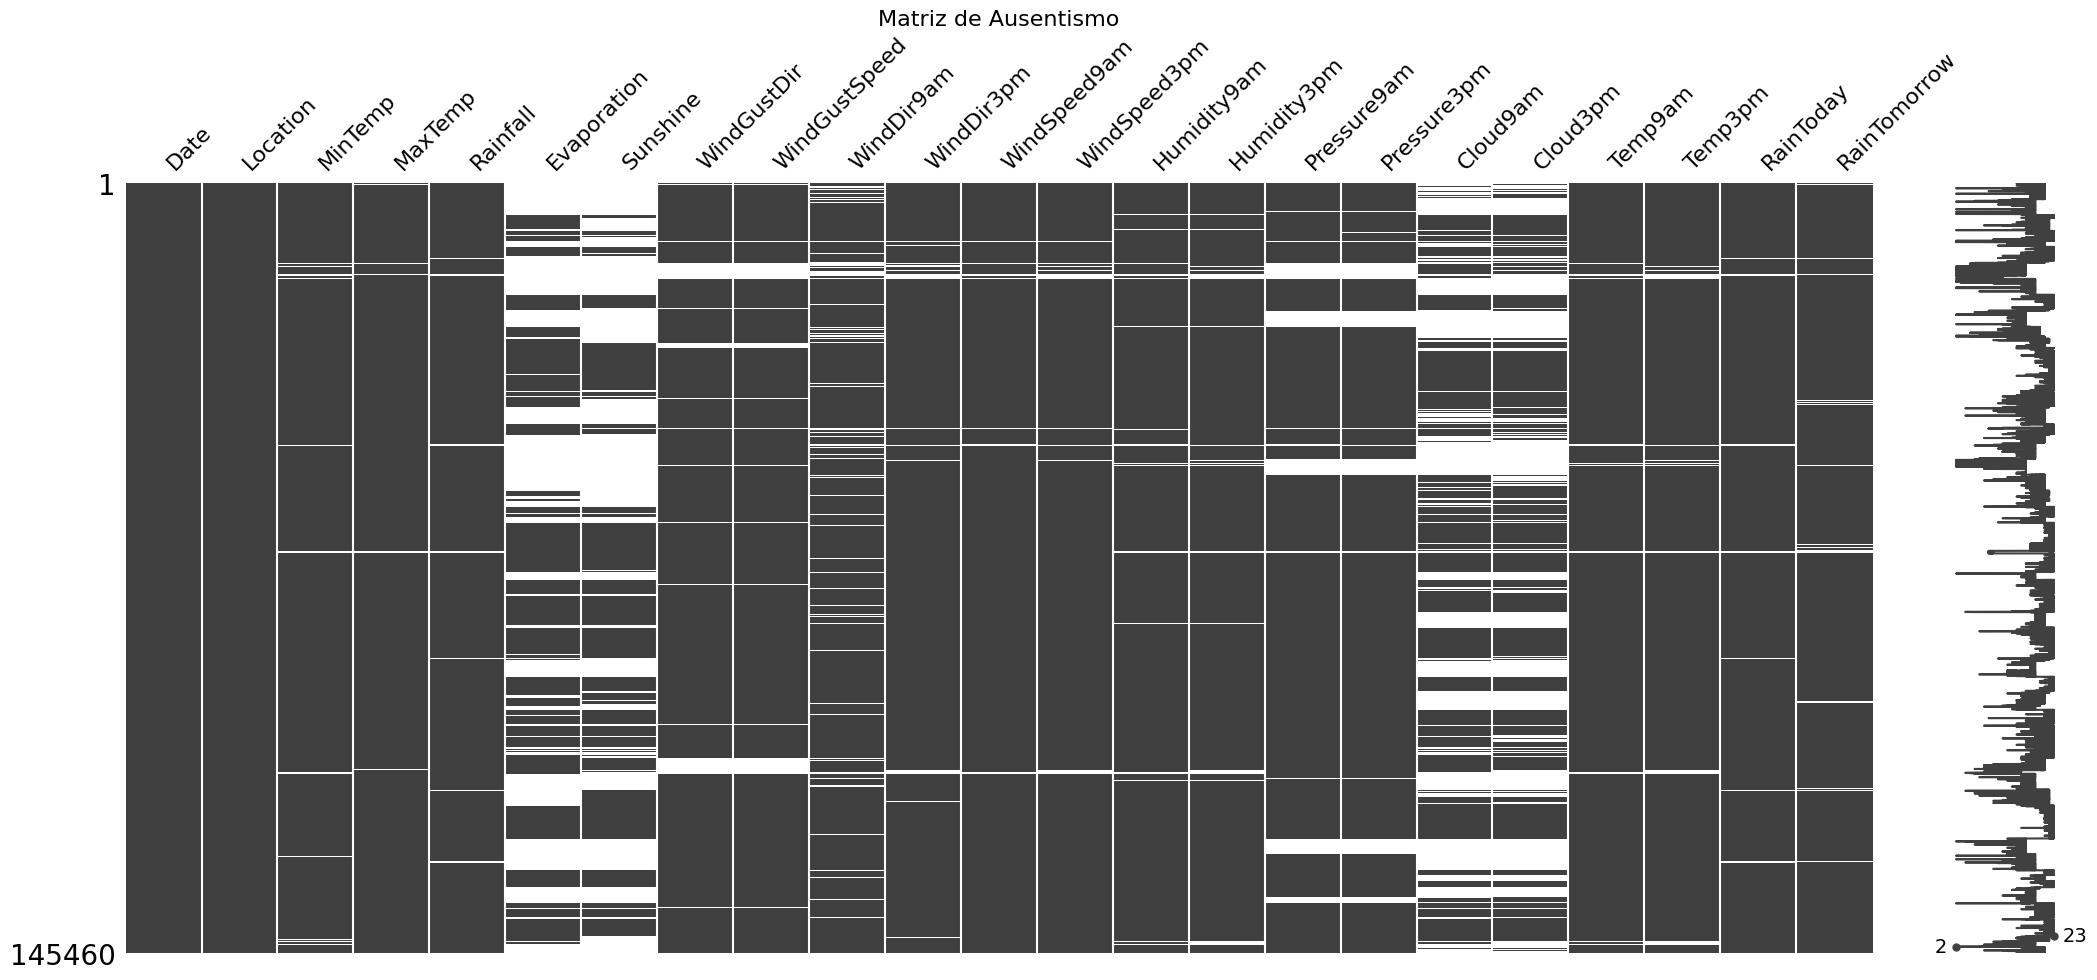

In [13]:
msno.matrix(df_lluvia)
plt.title('Matriz de Ausentismo', fontsize=16)
plt.show()

El dataset posee valores nulos, en el dataset figuran como "NA". Estos se trataran posteriormente.

## Columnas categóricas

In [14]:
df_lluvia.describe(include = 'object').T

,count,unique,top,freq
Date,145460,3436,2017-06-24,49
Location,145460,49,Canberra,3436
WindGustDir,135134,16,W,9915
WindDir9am,134894,16,N,11758
WindDir3pm,141232,16,SE,10838
RainToday,142199,2,No,110319
RainTomorrow,142193,2,No,110316


## Columnas numéricas

In [15]:
df_lluvia.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


# Data Wrangling y EDA

## Tratamiento de valores nulos

In [16]:
# Porcentaje de nulos por columna
null_pct = df_lluvia.isna().mean().sort_values(ascending=False) * 100
print(null_pct.round(2))

Sunshine         48.01
Evaporation      43.17
Cloud3pm         40.81
Cloud9am         38.42
Pressure9am      10.36
Pressure3pm      10.33
WindDir9am        7.26
WindGustDir       7.10
WindGustSpeed     7.06
Humidity3pm       3.10
WindDir3pm        2.91
Temp3pm           2.48
RainTomorrow      2.25
Rainfall          2.24
RainToday         2.24
WindSpeed3pm      2.11
Humidity9am       1.82
WindSpeed9am      1.21
Temp9am           1.21
MinTemp           1.02
MaxTemp           0.87
Date              0.00
Location          0.00
dtype: float64


Análisis del porcentaje de faltante en cada columna, para definir si alguna columna tiene muchos faltantes y descartarla. En esta primera iteración no las descarto y le imputo valores en el código posterior (otra posibilidad a evaluar es descartando estas variables que tienen muchos faltantes: Sunshine, Evaporation, Cloud3pm y Cloud9am .

In [17]:
# Convertir 'Date' a tipo datetime y extraer 'Month' para agrupar
df_lluvia['Date'] = pd.to_datetime(df_lluvia['Date'])
df_lluvia['Month'] = df_lluvia['Date'].dt.month

# Definir columnas numéricas y categóricas
num_cols = df_lluvia.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_lluvia.select_dtypes(include=['object']).columns.tolist()

# Numéricas por mediana de grupo
for c in [col for col in num_cols]: # RainTomorrow es categórica, por lo tanto no estará en num_cols
    grp_med = df_lluvia.groupby(['Location','Month'])[c].transform('median')
    df_lluvia[c] = df_lluvia[c].fillna(grp_med)

# Categóricas por moda de grupo (excepto direcciones)
for c in [col for col in cat_cols if c not in ['WindGustDir','WindDir9am','WindDir3pm']]:
    grp_mode = df_lluvia.groupby(['Location','Month'])[c].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    df_lluvia[c] = df_lluvia[c].fillna(grp_mode)

# Relleno residual (si aún quedó algo, por ejemplo direcciones del viento)
df_lluvia[num_cols] = df_lluvia[num_cols].fillna(df_lluvia[num_cols].median())
for c in cat_cols:
    moda = df_lluvia[c].mode()
    df_lluvia[c] = df_lluvia[c].fillna(moda.iloc[0] if not moda.empty else 'Unknown')

Transformación de la información: primero se paso la columna "date" a formato fecha.
Se agrego la columna mes para agrupar por posible estacionalidad y usarla para la imputación de valores númericos.
Estrategia de imputación: mediana para numéricas y moda para categóricas.
El relleno residual es para las direcciones del viento.

In [18]:
print(df_lluvia.isna().sum())

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
Month            0
dtype: int64


Verificación de nulos después de los cambios.

In [19]:
print(df_lluvia.head())

        Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0 2008-12-01   Albury     13.4     22.9       0.6          4.6       8.6   
1 2008-12-02   Albury      7.4     25.1       0.0          4.6       8.6   
2 2008-12-03   Albury     12.9     25.7       0.0          4.6       8.6   
3 2008-12-04   Albury      9.2     28.0       0.0          4.6       8.6   
4 2008-12-05   Albury     17.5     32.3       1.0          4.6       8.6   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  Pressure9am  \
0           W           44.0          W  ...        22.0       1007.7   
1         WNW           44.0        NNW  ...        25.0       1010.6   
2         WSW           46.0          W  ...        30.0       1007.6   
3          NE           24.0         SE  ...        16.0       1017.6   
4           W           41.0        ENE  ...        33.0       1010.8   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  RainTomorrow  \
0       1007.1       8.

Dataset sin valores nulos

## Analisis de variables numéricas

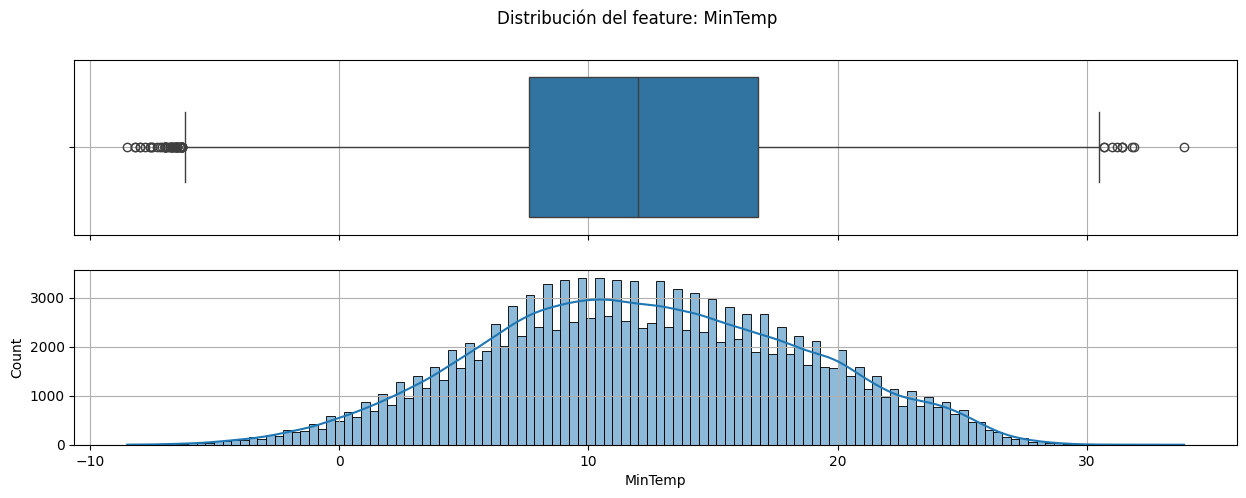

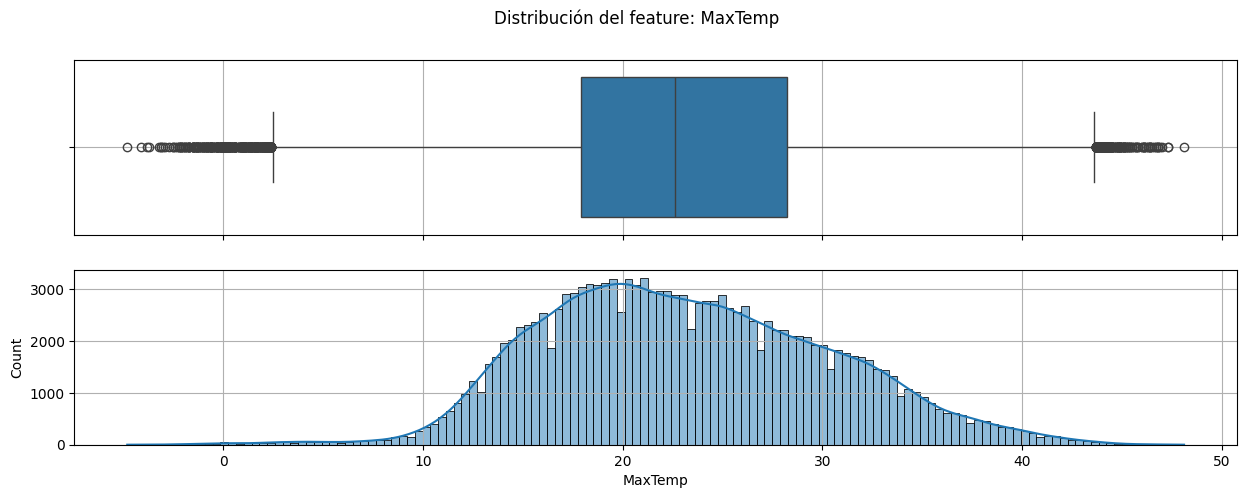

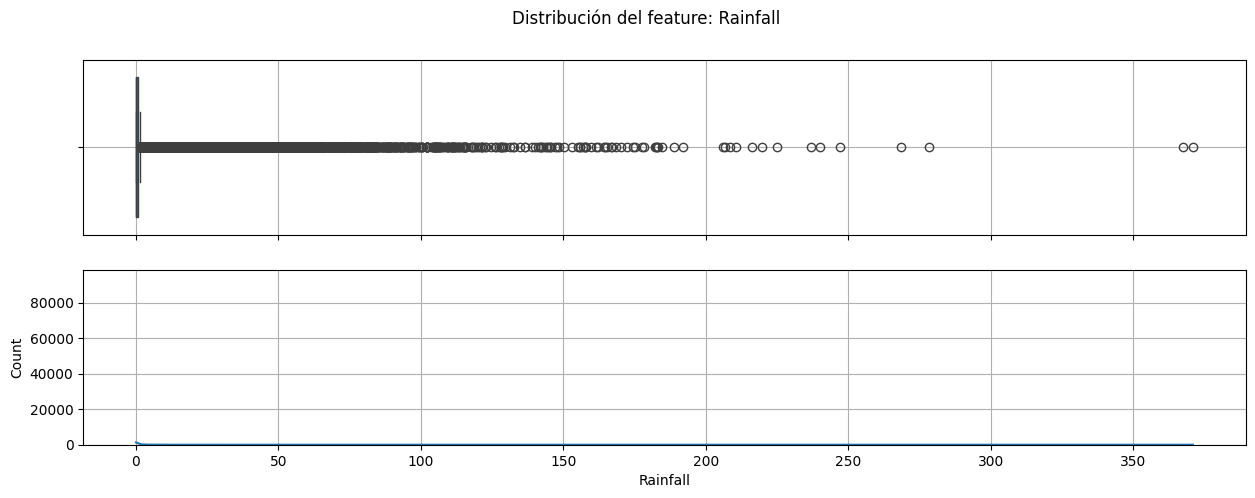

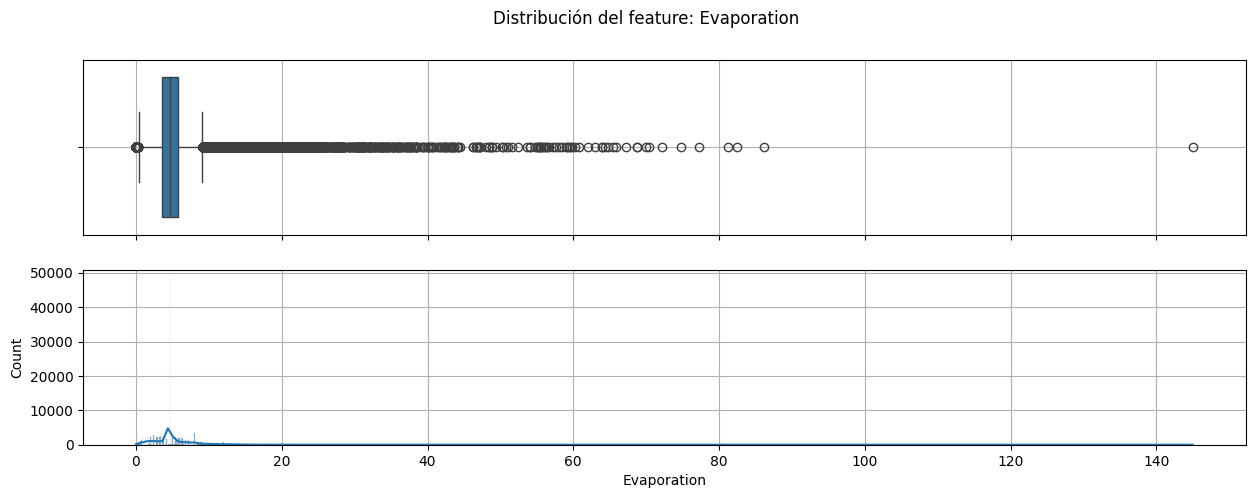

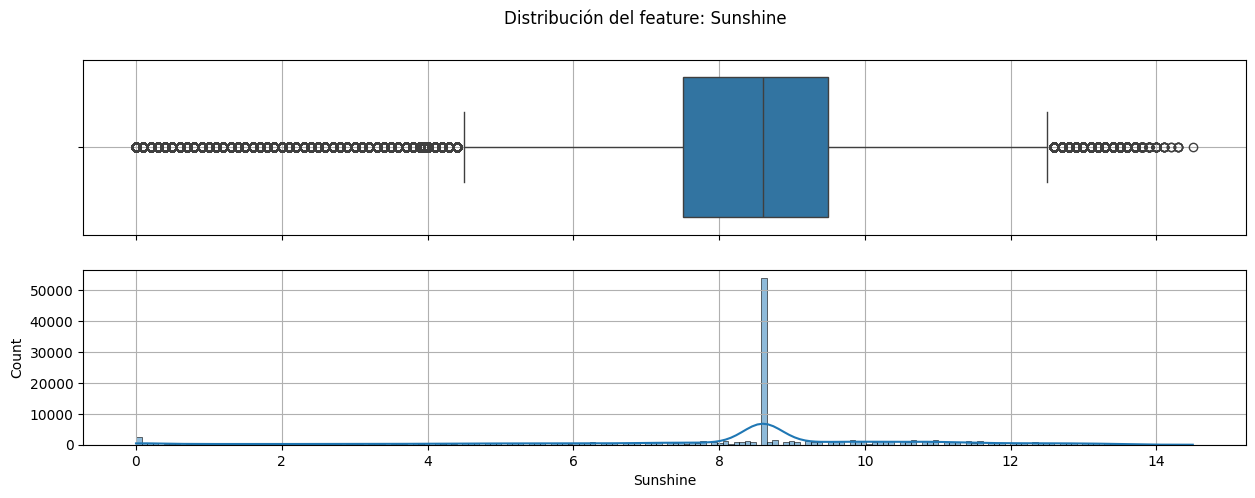

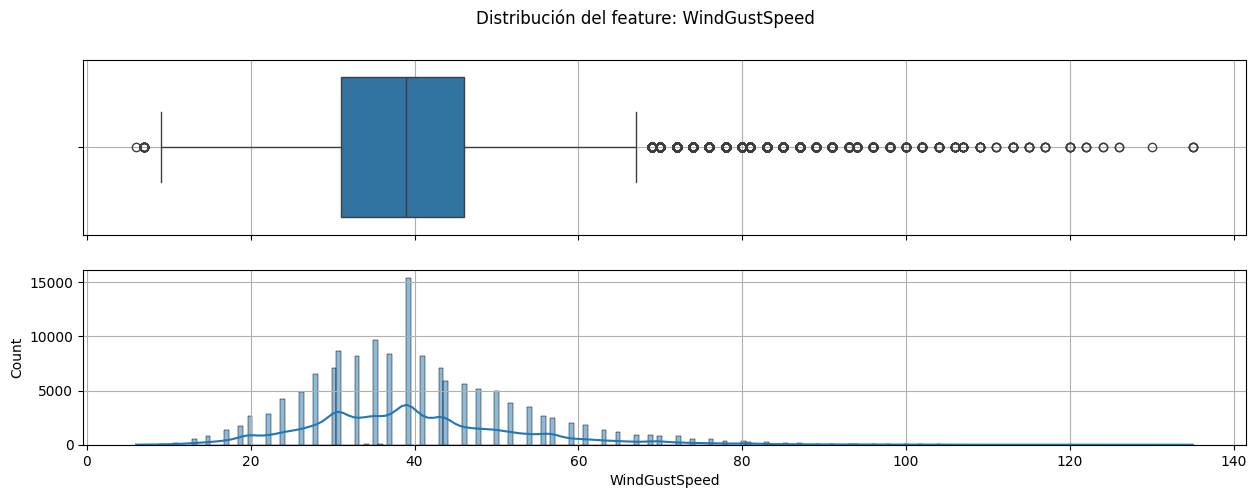

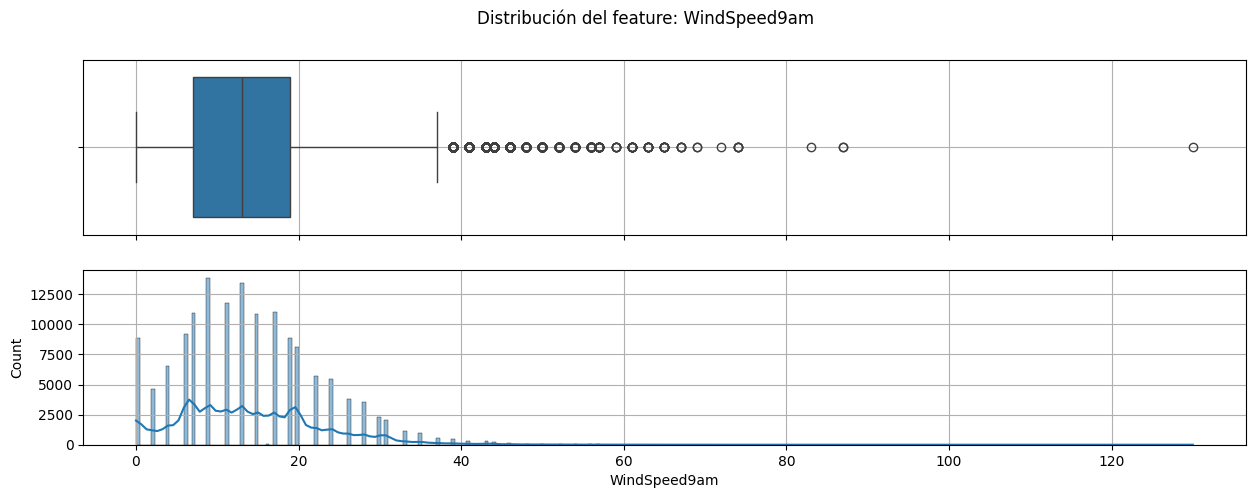

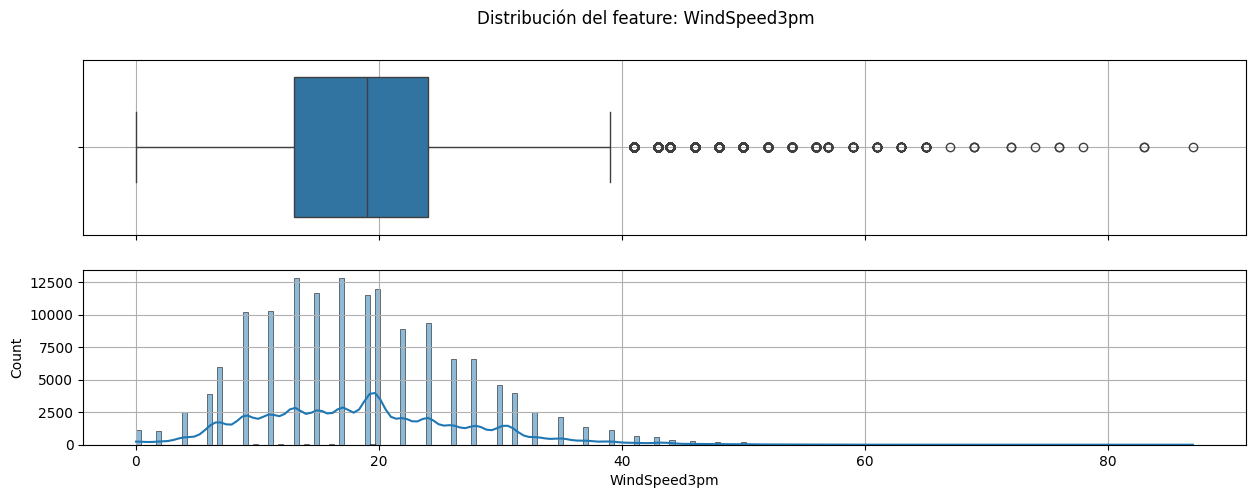

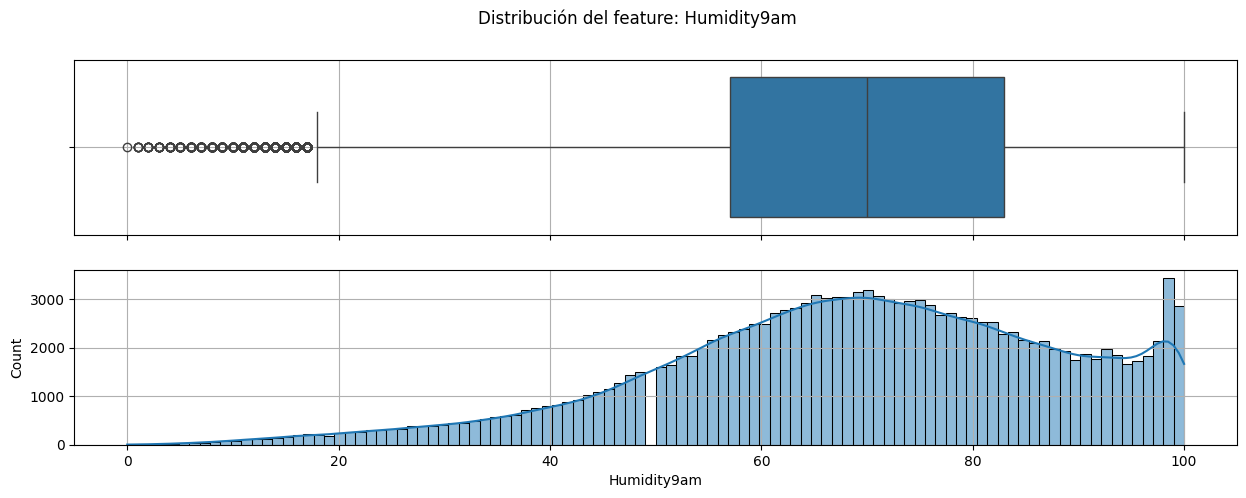

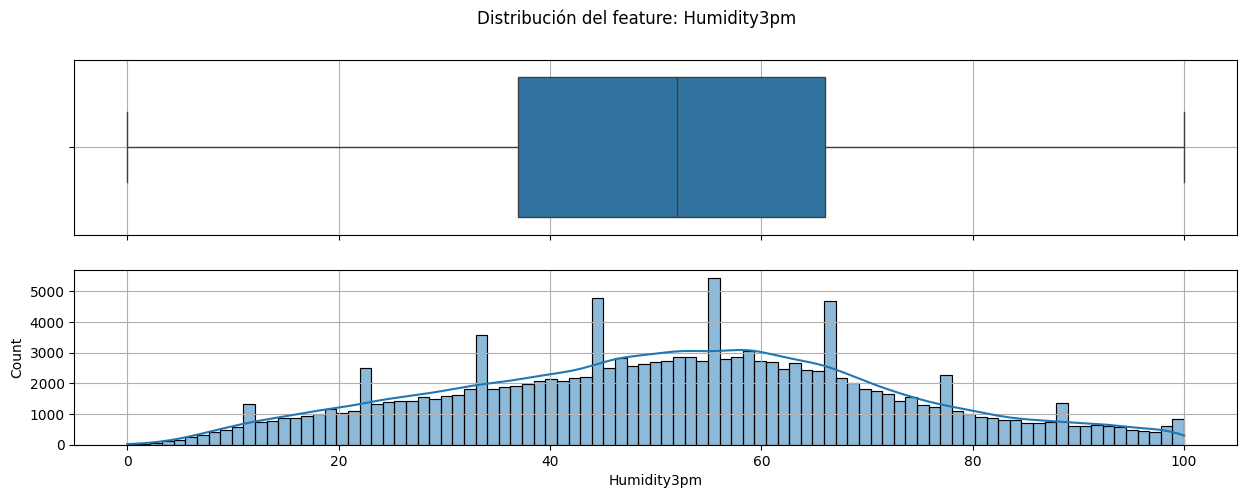

In [20]:

numerical_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                      'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                      'Humidity9am', 'Humidity3pm']

# Recorremos cada variable numérica para graficar su distribución y boxplot
for i, feature in enumerate(numerical_features):
    fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
    fig.suptitle(f'Distribución del feature: {feature}')

    # Boxplot para ver outliers
    sns.boxplot(x=df_lluvia[feature], ax=axes[0])

    # Histograma con curva de densidad (reemplazo de distplot)
    sns.histplot(x=df_lluvia[feature], ax=axes[1], kde=True)

    axes[0].grid()
    axes[1].grid()
    plt.show()


Análisis de las distintas variables:
- Temperatura mínima y máxima (MinTemp y MaxTemp): hay valores outliers, pero los mismos se encuentran dentro de lo esperado, así que se mantendra la información. Lo mismo aplica para las siguientes variables: Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm y Humidity9am.
- Se analizara en mayor profundidad las variables Rainfall y Evaporation, y poder entender mejor el gráfico que cuenta eventos.


### Análisis Rainfall y Evaporation

In [21]:
print(df_lluvia['Rainfall'].describe())

count    145460.000000
mean          2.309813
std           8.389372
min           0.000000
25%           0.000000
50%           0.000000
75%           0.600000
max         371.000000
Name: Rainfall, dtype: float64


(0.0, 50.0)

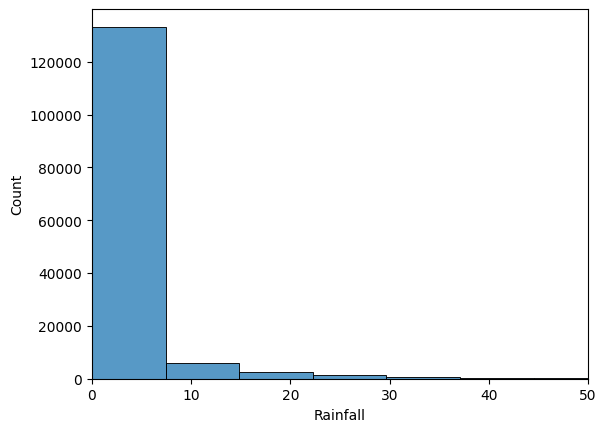

In [22]:
sns.histplot(df_lluvia['Rainfall'], bins=50)
plt.xlim(0, 50)
# Se advierte en el gráfico que más de 120.000 registros son valores entre 0 y 10 mm diarios.


In [23]:
llueve = (df_lluvia['Rainfall'] > 0).sum()
no_llueve = (df_lluvia['Rainfall'] == 0).sum()
print(f"Días con lluvia: {llueve}, sin lluvia: {no_llueve}")

Días con lluvia: 51612, sin lluvia: 93848


In [24]:
(df_lluvia['Rainfall'] > 0).mean() * 100

np.float64(35.48191942802145)

(0.0, 10.0)

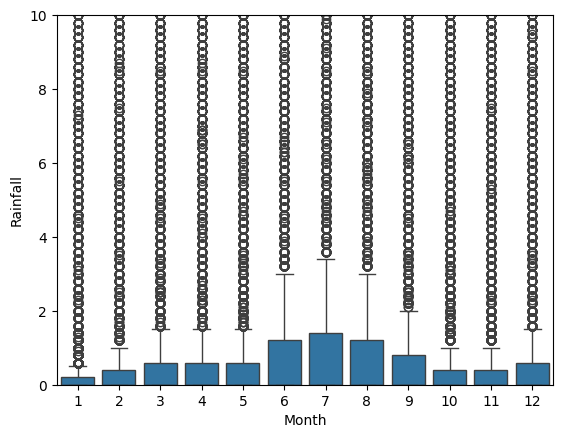

In [25]:

sns.boxplot(x='Month', y='Rainfall', data=df_lluvia)
plt.ylim(0, 10)
# Gráfico para entender la posible estacionalidad de la lluvia.

In [26]:
print(df_lluvia['Evaporation'].describe())

count    145460.000000
mean          5.086374
std           3.310808
min           0.000000
25%           3.600000
50%           4.600000
75%           5.800000
max         145.000000
Name: Evaporation, dtype: float64


(0.0, 50.0)

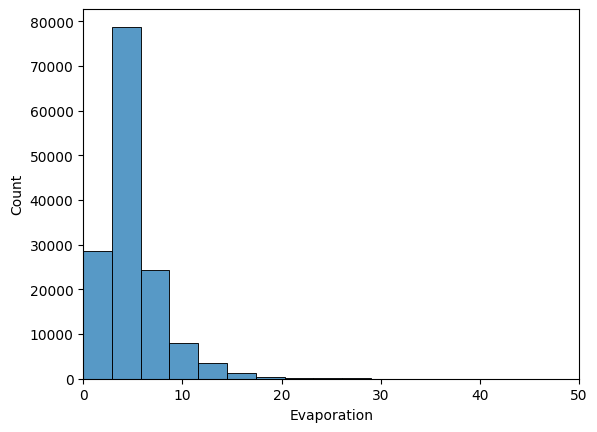

In [27]:
sns.histplot(df_lluvia['Evaporation'], bins=50)
plt.xlim(0, 50)
# Se advierte en el gráfico que más de 120.000 registros son valores entre 0 y 10.

(0.0, 50.0)

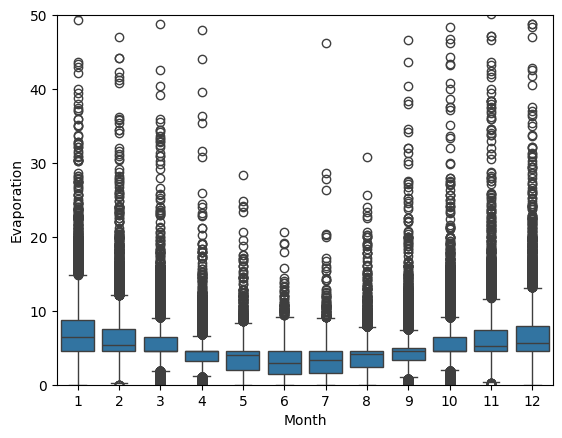

In [28]:
sns.boxplot(x='Month', y='Evaporation', data=df_lluvia)
plt.ylim(0, 50)
# Gráfico para entender la posible estacionalidad de la evaporación.

# Correlaciones (variables numéricas)

## Pandas profiling

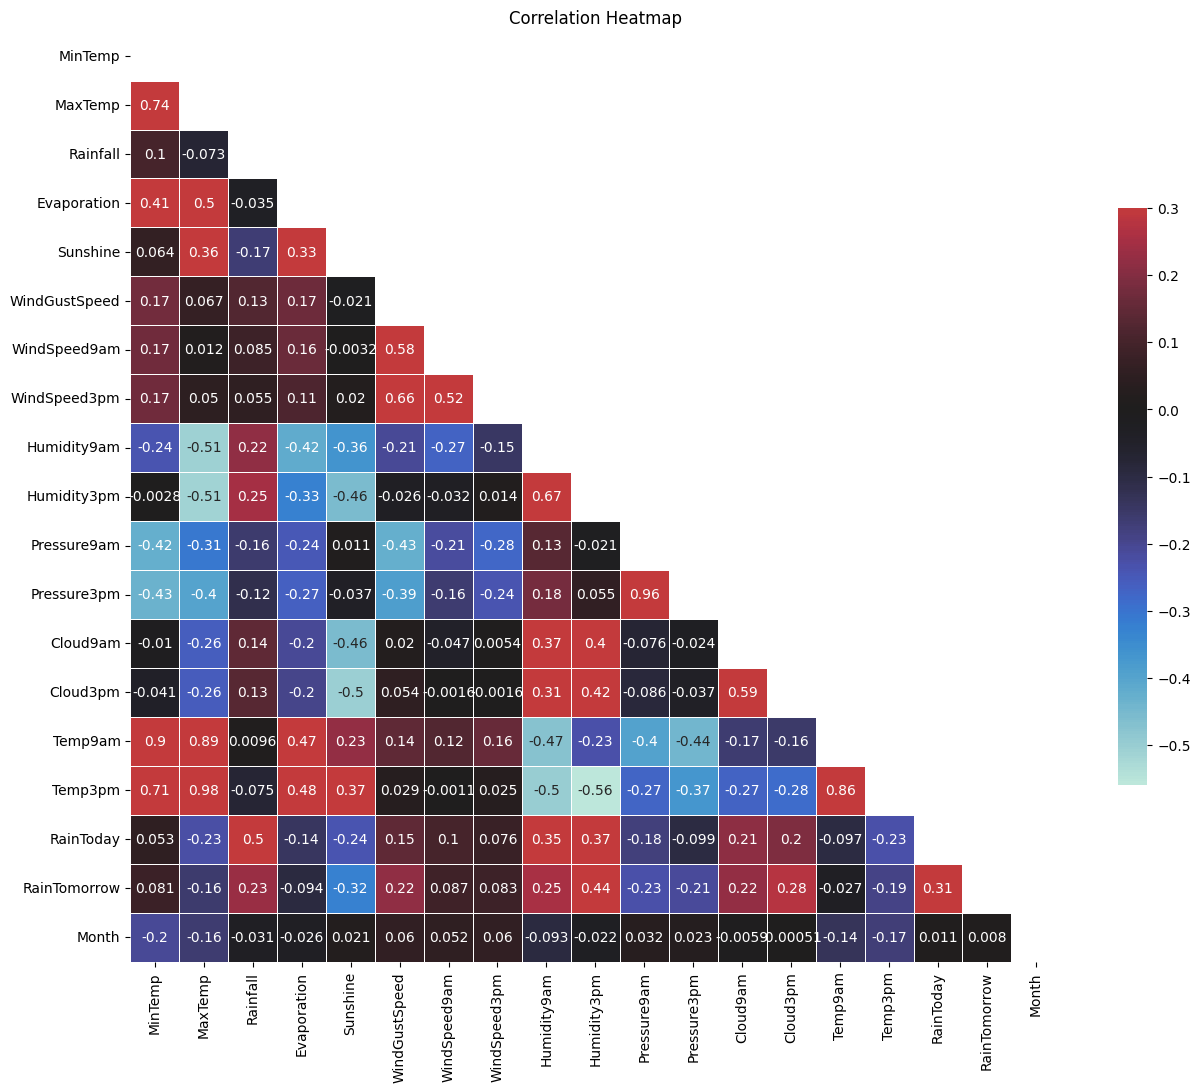

In [29]:
# Convertir 'Yes'/'No' a 1/0 para el cálculo de correlación
df_lluvia['RainToday'] = df_lluvia['RainToday'].map({'Yes': 1, 'No': 0})
df_lluvia['RainTomorrow'] = df_lluvia['RainTomorrow'].map({'Yes': 1, 'No': 0})

corr = df_lluvia.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(15, 15))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot = True, mask=mask, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap')
plt.show()

Puede observarse que -en módulo- las correlaciones de mayor valor se dan entre la variable target y Rainfall, WindGustSpeed, Humidity9am, Humidity3pm,  Cloud9am, Cloud3pm y RainToday.

### Análisis  Rainfall vs RainTomorrow

In [30]:
df_lluvia['Rainfall'].corr(df_lluvia['RainTomorrow'])

np.float64(0.2336461926522606)

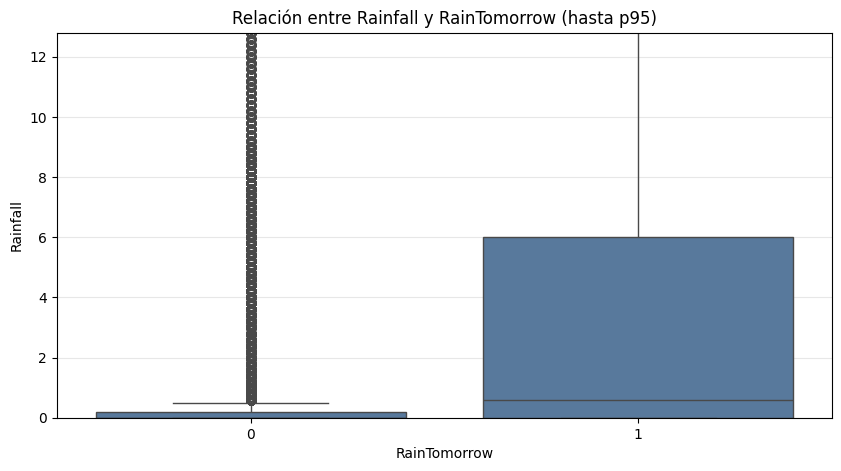

In [31]:
p95 = df_lluvia['Rainfall'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='RainTomorrow', y='Rainfall', data=df_lluvia, ax=ax, color="#4C78A8")
ax.set_ylim(0, p95)  # zoom en rango útil
ax.set_title('Relación entre Rainfall y RainTomorrow (hasta p95)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.grid(True, axis='y', alpha=0.3)
plt.show()


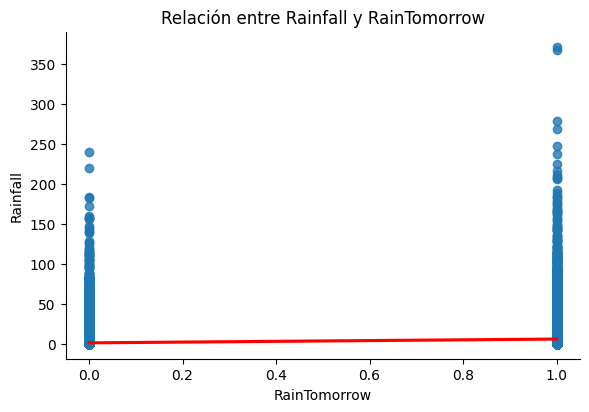

In [32]:
sns.lmplot(data=df_lluvia, x='RainTomorrow', y='Rainfall', line_kws={'color': 'r'}, height=4, aspect=1.5)
plt.title('Relación entre Rainfall y RainTomorrow')
plt.show()

### Análisis WindGustSpeed vs RainTomorrow

In [33]:
df_lluvia['WindGustSpeed'].corr(df_lluvia['RainTomorrow'])

np.float64(0.22009837586699077)

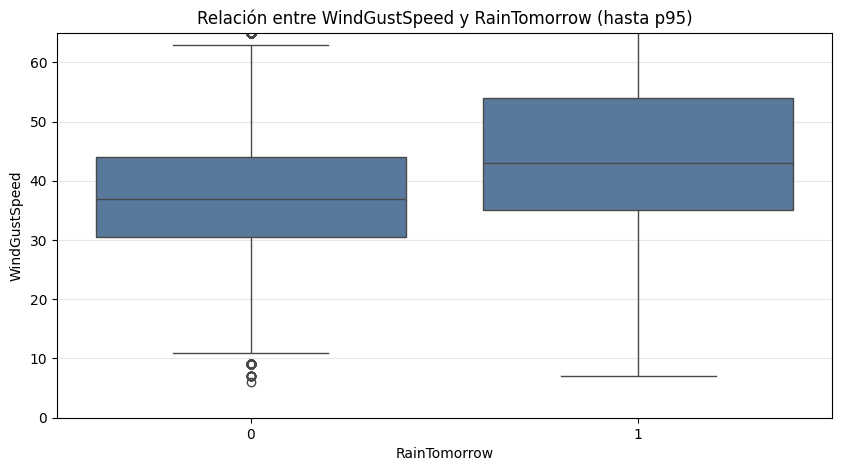

In [34]:
p95 = df_lluvia['WindGustSpeed'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='RainTomorrow', y='WindGustSpeed', data=df_lluvia, ax=ax, color="#4C78A8")
ax.set_ylim(0, p95)  # zoom en rango útil
ax.set_title('Relación entre WindGustSpeed y RainTomorrow (hasta p95)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.grid(True, axis='y', alpha=0.3)
plt.show()

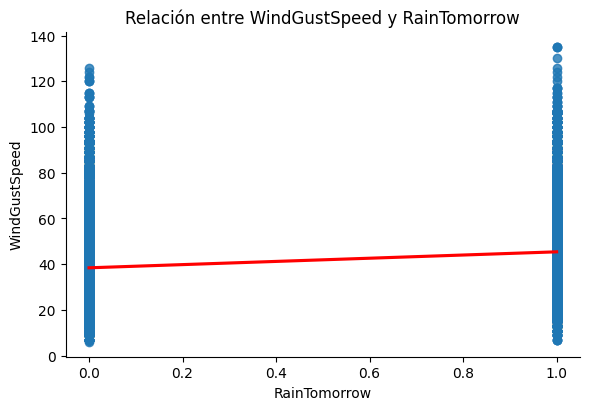

In [35]:
sns.lmplot(data=df_lluvia, x='RainTomorrow', y='WindGustSpeed', line_kws={'color': 'r'}, height=4, aspect=1.5)
plt.title('Relación entre WindGustSpeed y RainTomorrow')
plt.show()

### Análisis Humidity9am vs RainTomorrow

In [36]:
df_lluvia['Humidity9am'].corr(df_lluvia['RainTomorrow'])

np.float64(0.2533565711315767)

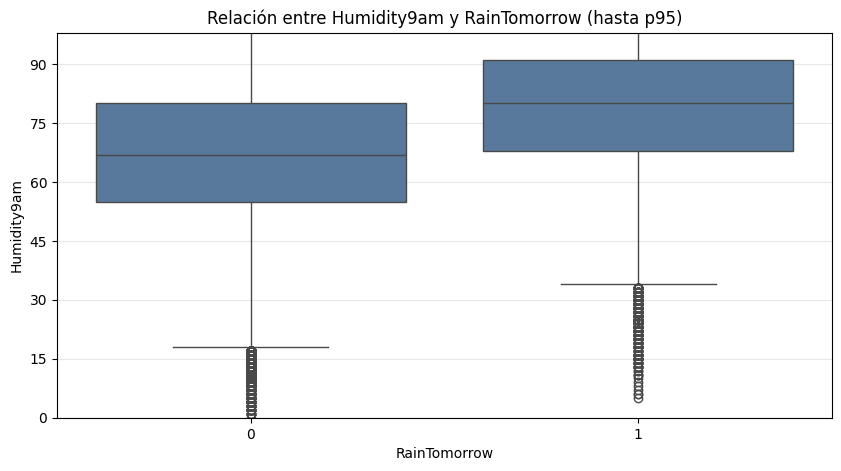

In [37]:
p95 = df_lluvia['Humidity9am'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='RainTomorrow', y='Humidity9am', data=df_lluvia, ax=ax, color="#4C78A8")
ax.set_ylim(0, p95)  # zoom en rango útil
ax.set_title('Relación entre Humidity9am y RainTomorrow (hasta p95)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.grid(True, axis='y', alpha=0.3)
plt.show()

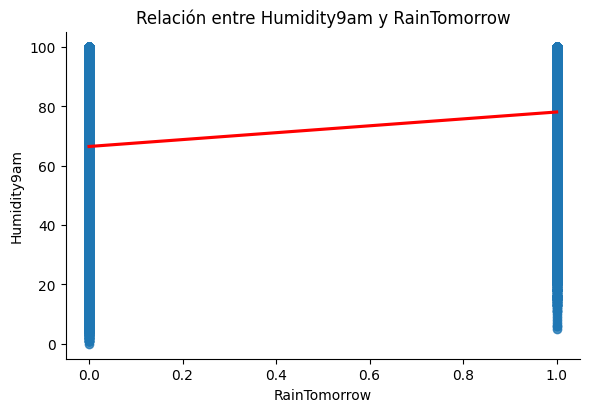

In [38]:
sns.lmplot(data=df_lluvia, x='RainTomorrow', y='Humidity9am', line_kws={'color': 'r'}, height=4, aspect=1.5)
plt.title('Relación entre Humidity9am y RainTomorrow')
plt.show()

### Análisis Humidity3pm vs RainTomorrow

In [39]:
df_lluvia['Humidity3pm'].corr(df_lluvia['RainTomorrow'])

np.float64(0.4352519418193582)

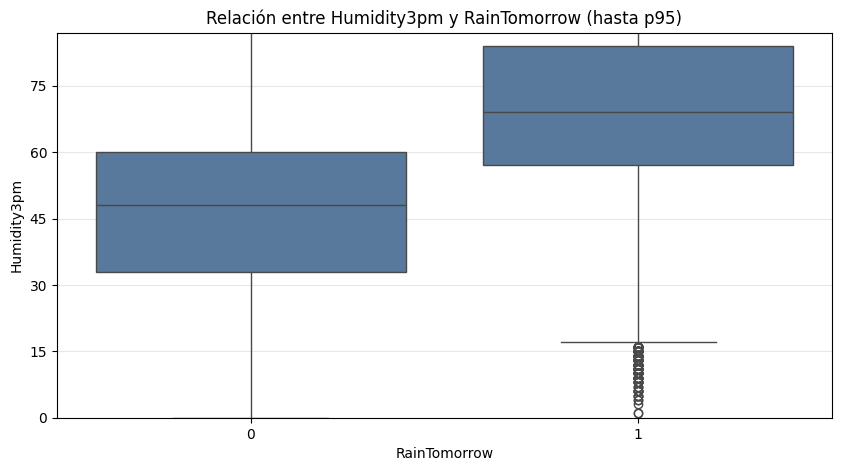

In [40]:
p95 = df_lluvia['Humidity3pm'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df_lluvia, ax=ax, color="#4C78A8")
ax.set_ylim(0, p95)  # zoom en rango útil
ax.set_title('Relación entre Humidity3pm y RainTomorrow (hasta p95)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.grid(True, axis='y', alpha=0.3)
plt.show()

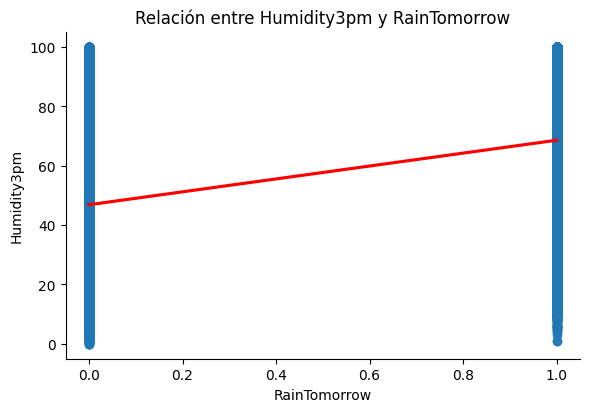

In [41]:
sns.lmplot(data=df_lluvia, x='RainTomorrow', y='Humidity3pm', line_kws={'color': 'r'}, height=4, aspect=1.5)
plt.title('Relación entre Humidity3pm y RainTomorrow')
plt.show()

### Análisis Cloud9am vs RainTomorrow

In [42]:
df_lluvia['Cloud9am'].corr(df_lluvia['RainTomorrow'])

np.float64(0.2236893878802607)

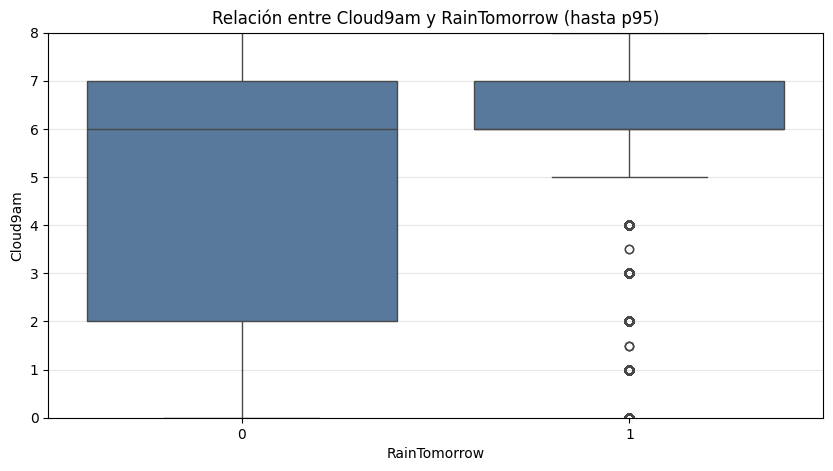

In [43]:
p95 = df_lluvia['Cloud9am'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='RainTomorrow', y='Cloud9am', data=df_lluvia, ax=ax, color="#4C78A8")
ax.set_ylim(0, p95)  # zoom en rango útil
ax.set_title('Relación entre Cloud9am y RainTomorrow (hasta p95)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.grid(True, axis='y', alpha=0.3)
plt.show()

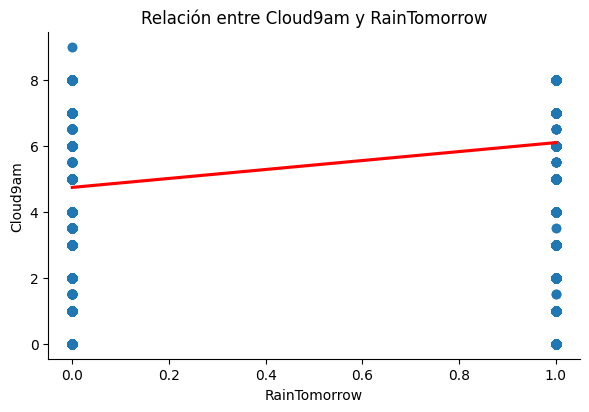

In [44]:
sns.lmplot(data=df_lluvia, x='RainTomorrow', y='Cloud9am', line_kws={'color': 'r'}, height=4, aspect=1.5)
plt.title('Relación entre Cloud9am y RainTomorrow')
plt.show()

### Análisis Cloud3pm vs RainTomorrow

In [45]:
df_lluvia['Cloud3pm'].corr(df_lluvia['RainTomorrow'])

np.float64(0.2757150190083269)

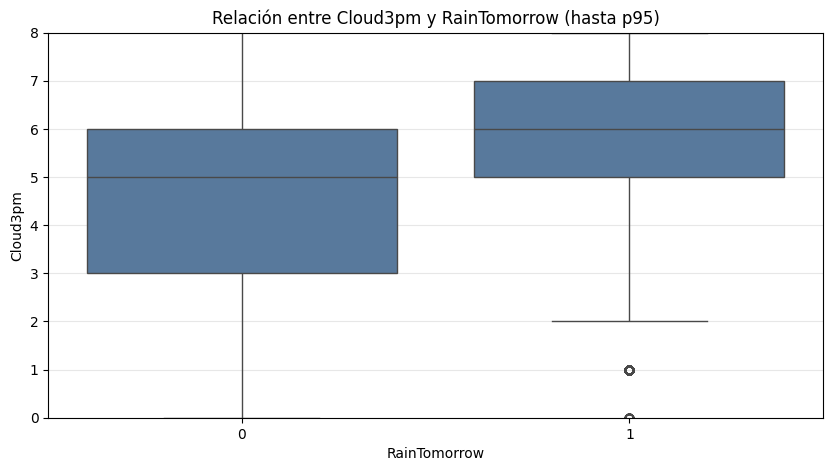

In [46]:
p95 = df_lluvia['Cloud3pm'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='RainTomorrow', y='Cloud3pm', data=df_lluvia, ax=ax, color="#4C78A8")
ax.set_ylim(0, p95)  # zoom en rango útil
ax.set_title('Relación entre Cloud3pm y RainTomorrow (hasta p95)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.grid(True, axis='y', alpha=0.3)
plt.show()

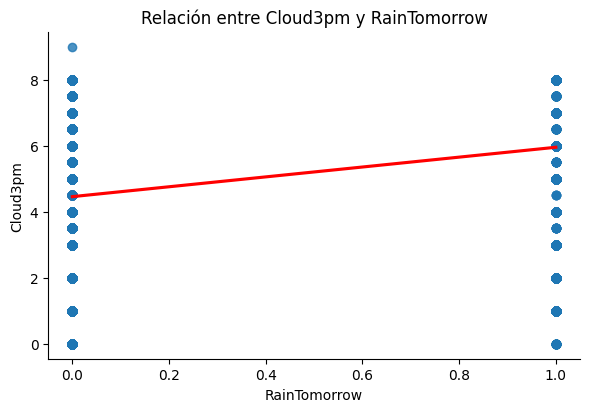

In [47]:
sns.lmplot(data=df_lluvia, x='RainTomorrow', y='Cloud3pm', line_kws={'color': 'r'}, height=4, aspect=1.5)
plt.title('Relación entre Cloud3pm y RainTomorrow')
plt.show()

### Análisis RainToday vs RainTomorrow

In [48]:
df_lluvia['RainToday'].corr(df_lluvia['RainTomorrow'])

np.float64(0.3068158461300846)

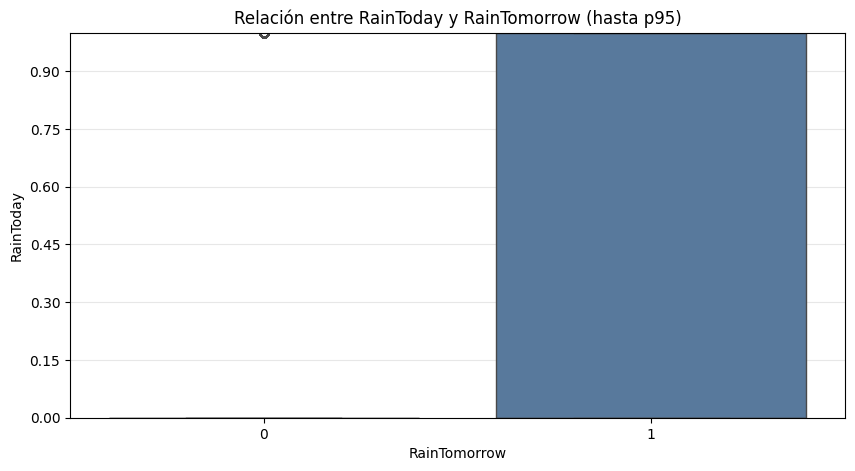

In [49]:
p95 = df_lluvia['RainToday'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='RainTomorrow', y='RainToday', data=df_lluvia, ax=ax, color="#4C78A8")
ax.set_ylim(0, p95)  # zoom en rango útil
ax.set_title('Relación entre RainToday y RainTomorrow (hasta p95)')
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
ax.grid(True, axis='y', alpha=0.3)
plt.show()

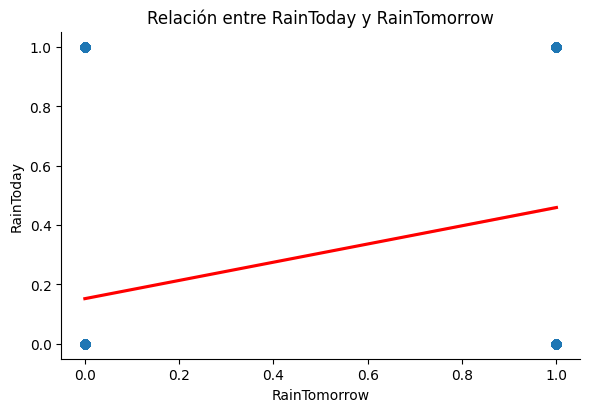

In [50]:
sns.lmplot(data=df_lluvia, x='RainTomorrow', y='RainToday', line_kws={'color': 'r'}, height=4, aspect=1.5)
plt.title('Relación entre RainToday y RainTomorrow')
plt.show()

# Encoding data and feature engineering

En una primera iteración, se dispuso a encodear las variables categóricas ordinales en enteros representativos y las nominales se binarizaron en 0 y 1

In [51]:
df_lluvia

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,2008-12-01,Albury,13.4,22.90,0.6,4.6,8.6,W,44.0,W,...,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0,0,12
1,2008-12-02,Albury,7.4,25.10,0.0,4.6,8.6,WNW,44.0,NNW,...,25.0,1010.6,1007.8,7.0,5.0,17.2,24.3,0,0,12
2,2008-12-03,Albury,12.9,25.70,0.0,4.6,8.6,WSW,46.0,W,...,30.0,1007.6,1008.7,7.0,2.0,21.0,23.2,0,0,12
3,2008-12-04,Albury,9.2,28.00,0.0,4.6,8.6,NE,24.0,SE,...,16.0,1017.6,1012.8,7.0,5.0,18.1,26.5,0,0,12
4,2008-12-05,Albury,17.5,32.30,1.0,4.6,8.6,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.40,0.0,4.6,8.6,E,31.0,SE,...,24.0,1024.6,1020.3,6.0,3.5,10.1,22.4,0,0,6
145456,2017-06-22,Uluru,3.6,25.30,0.0,4.6,8.6,NNW,22.0,SE,...,21.0,1023.5,1019.1,6.0,3.5,10.9,24.5,0,0,6
145457,2017-06-23,Uluru,5.4,26.90,0.0,4.6,8.6,N,37.0,SE,...,24.0,1021.0,1016.8,6.0,3.5,12.5,26.1,0,0,6
145458,2017-06-24,Uluru,7.8,27.00,0.0,4.6,8.6,SE,28.0,SSE,...,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,0,0,6


In [52]:
#Crear la columna estación
for val in df_lluvia["Month"]:
    def get_season(month):
        if 3 <= month <= 6:
            return "Spring"
        elif 7 <= month <= 9:
            return "Summer"
        elif 10 <= month <= 11:
            return "Autumn"
        else:
            return "Winter"
df_lluvia['Season'] = df_lluvia['Month'].apply(get_season)

In [53]:
# Reemplaza el nombre del país con la mediana de días de lluvia en el año
df_lluvia["Year"]=df_lluvia["Date"].dt.year.astype("int64")
rain_days = df_lluvia[df_lluvia["RainToday"] == 1]
unique_rain_days = rain_days[["Location", "Year", "Date"]].drop_duplicates()
rain_counts = unique_rain_days.groupby(["Location", "Year"]).size().reset_index(name="RainyDays")
avg_rain_per_location = rain_counts.groupby("Location")["RainyDays"].mean().round().astype(int)
df_lluvia["Location"] = df_lluvia["Location"].map(avg_rain_per_location)


In [54]:
if "WindSpeed9am" in df_lluvia.columns and "WindSpeed3pm" in df_lluvia.columns:
    df_lluvia["WindSpeed_mean"] = df_lluvia[["WindSpeed9am", "WindSpeed3pm"]].mean(axis=1)
    df_lluvia.drop(["WindSpeed9am", "WindSpeed3pm"], axis=1, inplace=True)


In [55]:
dir_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
for col in ["WindGustDir", "WindDir9am", "WindDir3pm"]:
    df_lluvia[col] = df_lluvia[col].map(dir_map)

In [56]:
#Eliminando columnas correlacionadas entre sí
df_lluvia.drop( [
    "MinTemp",
    "MaxTemp",
    "Pressure9am",
    "Temp9am",
    "Date",
    "Year"
],axis=1,inplace=True)

In [57]:
obj_cols=df_lluvia.select_dtypes(include="object").columns
obj_cols

Index(['Season'], dtype='object')

In [58]:
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)

# Check if 'Season' column exists before processing
if 'Season' in df_lluvia.columns:
    season_encoded = onehot_encoder.fit_transform(df_lluvia[['Season']])
    season_encoded_df = pd.DataFrame(season_encoded,
                                     columns=onehot_encoder.get_feature_names_out(['Season']),
                                     index=df_lluvia.index)

    df_lluvia.drop(columns=['Season'], inplace=True)
    df_lluvia = pd.concat([df_lluvia, season_encoded_df], axis=1)
else:
    print("Column 'Season' not found in df_lluvia. Assuming it was already processed or is absent.")

In [59]:
from sklearn.preprocessing import LabelEncoder
label_cols = ['RainToday', 'RainTomorrow']
le = LabelEncoder()

for col in label_cols:
    df_lluvia[col] = le.fit_transform(df_lluvia[col])

## Dividir datos

In [60]:
X=df_lluvia.drop("RainTomorrow",axis=1,inplace=False)
y=df_lluvia["RainTomorrow"]

## Balanceo del dataset

In [61]:
df_lluvia

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
0,62,0.6,4.6,8.6,270.0,44.0,270.0,292.5,71.0,22.0,...,8.0,5.0,21.8,0,0,12,22.0,0.0,0.0,1.0
1,62,0.0,4.6,8.6,292.5,44.0,337.5,247.5,44.0,25.0,...,7.0,5.0,24.3,0,0,12,13.0,0.0,0.0,1.0
2,62,0.0,4.6,8.6,247.5,46.0,270.0,247.5,38.0,30.0,...,7.0,2.0,23.2,0,0,12,22.5,0.0,0.0,1.0
3,62,0.0,4.6,8.6,45.0,24.0,135.0,90.0,45.0,16.0,...,7.0,5.0,26.5,0,0,12,10.0,0.0,0.0,1.0
4,62,1.0,4.6,8.6,270.0,41.0,67.5,315.0,82.0,33.0,...,7.0,8.0,29.7,0,0,12,13.5,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,23,0.0,4.6,8.6,90.0,31.0,135.0,67.5,51.0,24.0,...,6.0,3.5,22.4,0,0,6,12.0,1.0,0.0,0.0
145456,23,0.0,4.6,8.6,337.5,22.0,135.0,0.0,56.0,21.0,...,6.0,3.5,24.5,0,0,6,11.0,1.0,0.0,0.0
145457,23,0.0,4.6,8.6,0.0,37.0,135.0,292.5,53.0,24.0,...,6.0,3.5,26.1,0,0,6,9.0,1.0,0.0,0.0
145458,23,0.0,4.6,8.6,135.0,28.0,157.5,0.0,51.0,24.0,...,3.0,2.0,26.0,0,0,6,10.0,1.0,0.0,0.0


<Axes: xlabel='RainTomorrow', ylabel='count'>

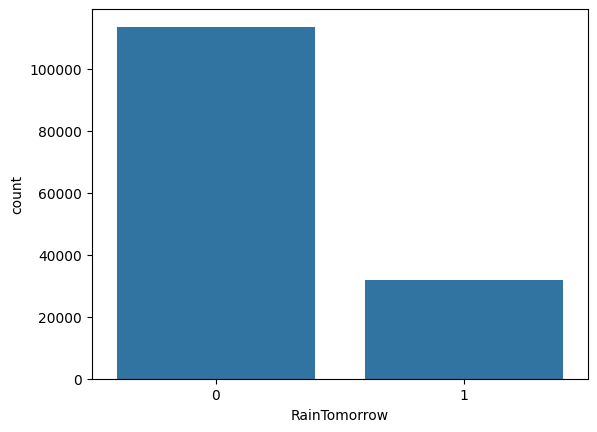

In [62]:
sns.countplot(data=df_lluvia,x="RainTomorrow")

In [63]:
df_lluvia['RainTomorrow'].value_counts()

,count
RainTomorrow,
0,113516
1,31944


In [64]:
disease_df_lluvia = df_lluvia[df_lluvia['RainTomorrow'] == 1]
disease_df_lluvia

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
8,62,0.0,4.6,8.6,337.5,80.0,135.0,315.0,42.0,9.0,...,7.0,5.0,30.2,0,1,12,17.5,0.0,0.0,1.0
10,62,0.0,4.6,8.6,0.0,30.0,157.5,112.5,48.0,22.0,...,7.0,5.0,28.8,0,1,12,11.5,0.0,0.0,1.0
11,62,2.2,4.6,8.6,22.5,31.0,45.0,67.5,89.0,91.0,...,8.0,8.0,17.0,1,1,12,14.0,0.0,0.0,1.0
12,62,15.6,4.6,8.6,270.0,61.0,337.5,337.5,76.0,93.0,...,8.0,8.0,15.8,1,1,12,28.0,0.0,0.0,1.0
16,62,0.0,4.6,8.6,67.5,22.0,202.5,90.0,69.0,82.0,...,8.0,1.0,18.1,0,1,12,10.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145324,23,0.4,4.6,8.6,292.5,65.0,90.0,67.5,38.0,24.0,...,6.5,4.0,36.6,0,1,2,17.5,0.0,0.0,1.0
145390,23,0.0,4.6,8.6,270.0,35.0,112.5,157.5,28.0,91.0,...,8.0,8.0,18.5,0,1,4,13.0,1.0,0.0,0.0
145391,23,6.8,4.6,8.6,67.5,30.0,45.0,67.5,65.0,65.0,...,3.0,8.0,21.2,1,1,4,14.0,1.0,0.0,0.0
145392,23,12.6,4.6,8.6,180.0,35.0,90.0,202.5,93.0,59.0,...,7.0,8.0,26.0,1,1,4,17.5,1.0,0.0,0.0


In [65]:
not_disease_df_lluvia = df_lluvia[df_lluvia['RainTomorrow'] == 0]
not_disease_df_lluvia

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
0,62,0.6,4.6,8.6,270.0,44.0,270.0,292.5,71.0,22.0,...,8.0,5.0,21.8,0,0,12,22.0,0.0,0.0,1.0
1,62,0.0,4.6,8.6,292.5,44.0,337.5,247.5,44.0,25.0,...,7.0,5.0,24.3,0,0,12,13.0,0.0,0.0,1.0
2,62,0.0,4.6,8.6,247.5,46.0,270.0,247.5,38.0,30.0,...,7.0,2.0,23.2,0,0,12,22.5,0.0,0.0,1.0
3,62,0.0,4.6,8.6,45.0,24.0,135.0,90.0,45.0,16.0,...,7.0,5.0,26.5,0,0,12,10.0,0.0,0.0,1.0
4,62,1.0,4.6,8.6,270.0,41.0,67.5,315.0,82.0,33.0,...,7.0,8.0,29.7,0,0,12,13.5,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,23,0.0,4.6,8.6,90.0,31.0,135.0,67.5,51.0,24.0,...,6.0,3.5,22.4,0,0,6,12.0,1.0,0.0,0.0
145456,23,0.0,4.6,8.6,337.5,22.0,135.0,0.0,56.0,21.0,...,6.0,3.5,24.5,0,0,6,11.0,1.0,0.0,0.0
145457,23,0.0,4.6,8.6,0.0,37.0,135.0,292.5,53.0,24.0,...,6.0,3.5,26.1,0,0,6,9.0,1.0,0.0,0.0
145458,23,0.0,4.6,8.6,135.0,28.0,157.5,0.0,51.0,24.0,...,3.0,2.0,26.0,0,0,6,10.0,1.0,0.0,0.0


In [66]:
sample_not_disease_df_lluvia = not_disease_df_lluvia.sample(len(disease_df_lluvia), random_state = 42)
sample_not_disease_df_lluvia

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
52718,82,0.0,4.6,8.6,247.5,50.0,247.5,225.0,57.0,47.0,...,6.0,5.0,8.5,0,0,9,20.0,0.0,1.0,0.0
88087,95,0.0,5.0,10.9,180.0,30.0,157.5,90.0,65.0,49.0,...,3.0,1.0,26.7,0,0,6,17.5,1.0,0.0,0.0
49546,57,0.0,4.6,8.6,22.5,20.0,292.5,0.0,84.0,52.0,...,6.0,5.0,18.4,0,0,5,5.5,1.0,0.0,0.0
50351,57,0.0,4.6,8.6,0.0,30.0,315.0,337.5,80.0,41.0,...,6.0,5.0,14.4,0,0,8,8.5,0.0,1.0,0.0
48157,57,0.0,5.8,8.1,67.5,33.0,112.5,270.0,66.0,37.0,...,1.0,7.0,29.2,0,0,2,11.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88942,95,0.0,5.8,12.2,22.5,33.0,135.0,0.0,58.0,67.0,...,1.0,2.0,29.7,0,0,12,14.0,0.0,0.0,1.0
39601,78,17.2,6.0,11.3,270.0,48.0,292.5,135.0,48.0,32.0,...,0.0,2.0,22.5,1,0,3,25.0,1.0,0.0,0.0
113446,98,0.2,4.6,8.6,22.5,48.0,22.5,0.0,53.0,45.0,...,6.0,5.0,25.5,0,0,4,17.0,1.0,0.0,0.0
85054,71,0.2,3.2,9.5,247.5,28.0,247.5,202.5,70.0,54.0,...,3.0,2.0,21.9,0,0,6,7.5,1.0,0.0,0.0


In [67]:
balanced_df_lluvia = pd.concat([disease_df_lluvia, sample_not_disease_df_lluvia ]).sample(frac = 1, random_state=42)
balanced_df_lluvia

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
37921,60,0.0,8.8,13.2,67.5,39.0,67.5,67.5,50.0,21.0,...,5.0,2.0,28.5,0,0,11,16.5,0.0,0.0,0.0
37871,60,0.0,5.0,11.7,292.5,54.0,67.5,315.0,49.0,15.0,...,0.0,1.0,29.1,0,0,10,21.0,0.0,0.0,0.0
52220,82,0.0,4.6,8.6,135.0,24.0,157.5,247.5,26.0,54.0,...,6.0,5.0,9.3,0,0,5,5.5,1.0,0.0,0.0
40081,78,0.0,1.8,7.8,292.5,31.0,292.5,315.0,73.0,44.0,...,1.0,3.0,15.7,0,0,6,12.5,1.0,0.0,0.0
43143,71,0.0,4.6,8.6,180.0,43.0,202.5,157.5,59.0,57.0,...,8.0,6.0,14.1,0,1,7,26.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94184,52,0.0,3.6,10.3,45.0,35.0,157.5,67.5,52.0,54.0,...,0.0,1.0,23.2,0,0,6,19.5,1.0,0.0,0.0
66098,73,0.0,2.2,5.0,0.0,61.0,0.0,0.0,83.0,69.0,...,4.0,7.0,12.8,0,0,6,36.0,1.0,0.0,0.0
4171,65,0.2,4.6,8.6,202.5,37.0,225.0,225.0,69.0,82.0,...,6.0,5.0,17.6,0,1,3,14.0,1.0,0.0,0.0
74227,48,0.4,4.6,8.6,270.0,46.0,22.5,292.5,88.0,90.0,...,6.0,5.0,11.9,0,1,6,20.5,1.0,0.0,0.0


## Correlación con variables encodeadas

In [68]:
df_lluvia

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
0,62,0.6,4.6,8.6,270.0,44.0,270.0,292.5,71.0,22.0,...,8.0,5.0,21.8,0,0,12,22.0,0.0,0.0,1.0
1,62,0.0,4.6,8.6,292.5,44.0,337.5,247.5,44.0,25.0,...,7.0,5.0,24.3,0,0,12,13.0,0.0,0.0,1.0
2,62,0.0,4.6,8.6,247.5,46.0,270.0,247.5,38.0,30.0,...,7.0,2.0,23.2,0,0,12,22.5,0.0,0.0,1.0
3,62,0.0,4.6,8.6,45.0,24.0,135.0,90.0,45.0,16.0,...,7.0,5.0,26.5,0,0,12,10.0,0.0,0.0,1.0
4,62,1.0,4.6,8.6,270.0,41.0,67.5,315.0,82.0,33.0,...,7.0,8.0,29.7,0,0,12,13.5,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,23,0.0,4.6,8.6,90.0,31.0,135.0,67.5,51.0,24.0,...,6.0,3.5,22.4,0,0,6,12.0,1.0,0.0,0.0
145456,23,0.0,4.6,8.6,337.5,22.0,135.0,0.0,56.0,21.0,...,6.0,3.5,24.5,0,0,6,11.0,1.0,0.0,0.0
145457,23,0.0,4.6,8.6,0.0,37.0,135.0,292.5,53.0,24.0,...,6.0,3.5,26.1,0,0,6,9.0,1.0,0.0,0.0
145458,23,0.0,4.6,8.6,135.0,28.0,157.5,0.0,51.0,24.0,...,3.0,2.0,26.0,0,0,6,10.0,1.0,0.0,0.0


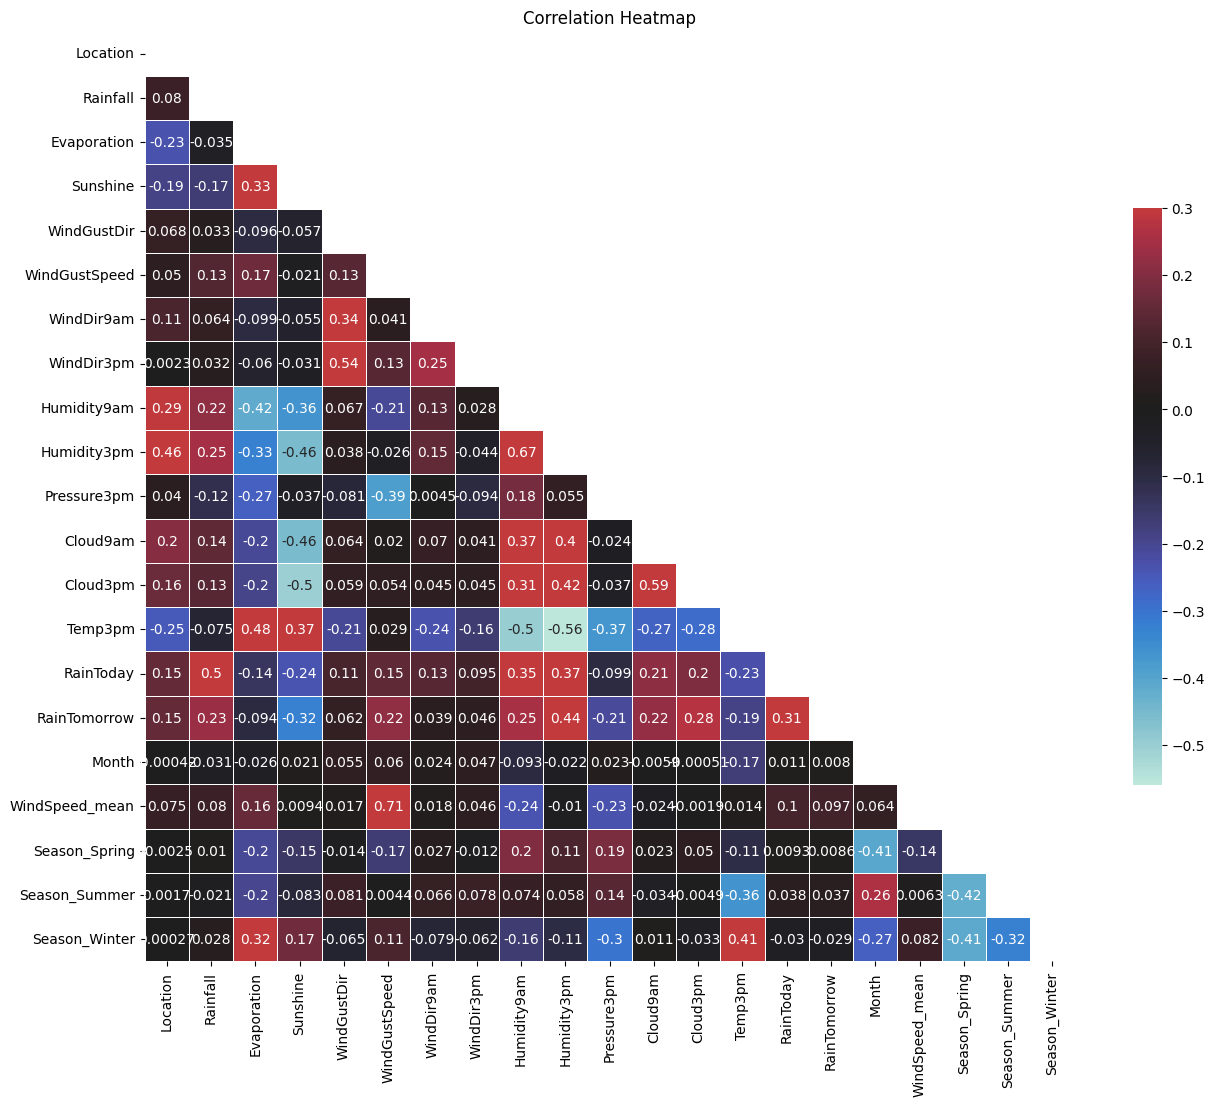

In [69]:
corr = df_lluvia.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(15, 15))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot = True, mask=mask, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap')
plt.show()

# Baseline

Como primera iteración se entrenarán dos modelos: un Árbol de Decisión clásico y un Random Forest, ambos sin optimizar hiperparámetros ni aplicar validación cruzada. Se generarán tres (3) conjuntos de datos: uno para entrenamiento (train), otro para validación (val) y otro para testeo (test) del mejor modelo. El conjunto de test se reservará y no será utilizado hasta haber seleccionado el modelo más adecuado mediante el conjunto de validación.

## Dependencias

In [70]:
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

## Test - Train - Validation split

In [71]:
train_df_lluvia, test_df_lluvia = train_test_split(balanced_df_lluvia, test_size=0.2, random_state=42)
train_df_lluvia, val_df_lluvia = train_test_split(train_df_lluvia, test_size=0.1, random_state=42)
display(train_df_lluvia)
display(val_df_lluvia.shape)
display(test_df_lluvia)

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
87029,71,0.4,5.4,5.4,67.5,30.0,112.5,90.0,63.0,69.0,...,7.0,7.0,27.2,0,1,1,13.0,0.0,0.0,1.0
23717,102,0.2,1.6,7.2,292.5,39.0,315.0,292.5,85.0,84.0,...,4.0,5.0,22.6,0,1,5,17.0,1.0,0.0,0.0
16922,73,0.0,4.6,8.6,270.0,39.0,135.0,45.0,75.0,65.0,...,1.0,6.0,26.0,0,1,3,2.0,1.0,0.0,0.0
56802,78,0.4,4.6,8.6,270.0,46.0,292.5,270.0,95.0,91.0,...,8.0,8.0,10.2,0,1,10,24.5,0.0,0.0,0.0
15098,73,0.0,4.6,8.6,270.0,39.0,315.0,135.0,62.0,42.0,...,6.0,8.0,29.0,0,1,12,2.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89000,95,0.0,7.6,4.0,180.0,46.0,67.5,180.0,64.0,96.0,...,7.0,7.0,24.7,0,1,2,14.5,0.0,0.0,1.0
12235,44,0.0,3.0,9.2,90.0,37.0,112.5,135.0,64.0,35.0,...,1.0,2.0,20.2,0,0,6,12.5,1.0,0.0,0.0
11397,97,0.1,2.8,10.0,90.0,28.0,0.0,67.5,57.0,52.0,...,1.0,2.0,20.8,0,0,8,13.0,0.0,1.0,0.0
133218,70,0.4,1.0,8.6,157.5,46.0,90.0,157.5,98.0,72.0,...,8.0,7.5,14.6,0,1,6,17.5,1.0,0.0,0.0


(5111, 21)

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
64539,73,0.0,6.0,12.9,157.5,30.0,202.5,45.0,72.0,21.0,...,2.0,0.0,28.8,0,0,12,6.0,0.0,0.0,1.0
41524,78,0.0,5.0,9.4,157.5,31.0,270.0,135.0,92.0,64.0,...,8.0,8.0,17.2,0,1,9,15.5,0.0,1.0,0.0
61274,71,0.0,4.4,2.4,270.0,76.0,292.5,202.5,68.0,86.0,...,7.0,7.0,18.7,0,1,4,14.0,1.0,0.0,0.0
9210,97,11.2,2.6,2.5,225.0,28.0,225.0,180.0,92.0,76.0,...,6.0,7.0,18.2,1,1,6,12.0,1.0,0.0,0.0
84440,71,0.0,6.2,3.4,270.0,39.0,0.0,22.5,64.0,66.0,...,3.0,6.0,23.9,0,1,9,14.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130503,76,0.4,1.4,8.0,270.0,52.0,270.0,225.0,51.0,53.0,...,2.0,3.0,13.1,0,0,4,15.5,1.0,0.0,0.0
125331,52,0.0,4.6,8.6,337.5,46.0,315.0,315.0,55.0,31.0,...,6.0,5.0,22.1,0,0,5,17.5,1.0,0.0,0.0
85384,71,0.0,4.0,10.2,90.0,17.0,225.0,180.0,65.0,35.0,...,2.0,1.0,26.0,0,0,5,5.0,1.0,0.0,0.0
39115,60,0.0,4.8,9.3,0.0,48.0,45.0,247.5,41.0,78.0,...,3.0,8.0,19.5,0,1,4,17.5,1.0,0.0,0.0


## Selección de features

In [72]:
target = 'RainTomorrow'
features = [col for col in balanced_df_lluvia.columns if(col != target)]
features

['Location',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp3pm',
 'RainToday',
 'Month',
 'WindSpeed_mean',
 'Season_Spring',
 'Season_Summer',
 'Season_Winter']

## Armado de los distintos sets de variables independientes y dependientes

In [73]:
X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]

In [74]:
X_val = val_df_lluvia[features]
y_val = val_df_lluvia[target]

In [75]:
X_test = test_df_lluvia[features]
y_test = test_df_lluvia[target]

## Modelos

### Random Forest

In [76]:
model_1 = RandomForestClassifier(n_estimators=10, class_weight='balanced', random_state = 42)
model_1.fit(X_train, y_train)

y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred_1)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred_1)

print('% de aciertos sobre el set de entrenamiento:', train_accuracy, '\n')
print('% de aciertos sobre el set de validación:',val_accuracy, '\n')

print(classification_report(y_val ,y_val_pred_1), '\n')

% de aciertos sobre el set de entrenamiento: 0.9886954064218787 

% de aciertos sobre el set de validación: 0.7755820778712581 

              precision    recall  f1-score   support

           0       0.76      0.82      0.79      2614
           1       0.79      0.73      0.76      2497

    accuracy                           0.78      5111
   macro avg       0.78      0.77      0.77      5111
weighted avg       0.78      0.78      0.78      5111
 



### Árbol de decisión

In [77]:
model_2 = DecisionTreeClassifier(random_state=42, max_depth=12)
model_2.fit(X_train, y_train)

y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred_2)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred_2)

print('% de aciertos sobre el set de entrenamiento:', train_accuracy, '\n')
print('% de aciertos sobre el set de validación:',val_accuracy, '\n')

print(classification_report(y_val,y_val_pred_2), '\n')

% de aciertos sobre el set de entrenamiento: 0.8495402073958129 

% de aciertos sobre el set de validación: 0.7497554294658579 

              precision    recall  f1-score   support

           0       0.75      0.77      0.76      2614
           1       0.75      0.72      0.74      2497

    accuracy                           0.75      5111
   macro avg       0.75      0.75      0.75      5111
weighted avg       0.75      0.75      0.75      5111
 



Ambos modelos performan de forma similar sobre el set de validación y fueron entrenados obteniendo métricas muy similares, con lo cuál probaremos el resultado de ambos modelos sobre el set de test.

% de aciertos sobre el set de test: 0.7834559398966975 

              precision    recall  f1-score   support

           0       0.76      0.82      0.79      6332
           1       0.81      0.74      0.78      6446

    accuracy                           0.78     12778
   macro avg       0.79      0.78      0.78     12778
weighted avg       0.79      0.78      0.78     12778
 



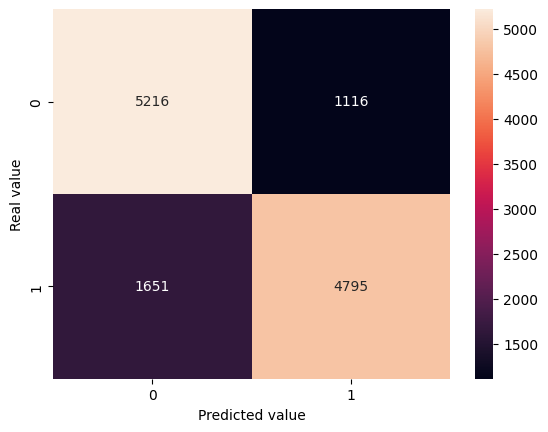

In [78]:
y_test_pred_1 = model_1.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, y_test_pred_1)
print('% de aciertos sobre el set de test:',test_accuracy, '\n')
print(classification_report(y_test, y_test_pred_1), '\n')
cm = confusion_matrix(y_test,y_test_pred_1)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

El modelo logra una tasa de aciertos aceptable en el conjunto de prueba, investigare en las siguientes iteraciones para mejorar la performace. Tiene las clases equilibradas. También hay una oportunidad de mejora en los falsos negativos.


% de aciertos sobre el set de test: 0.7530912505869463 

              precision    recall  f1-score   support

           0       0.74      0.77      0.76      6332
           1       0.77      0.73      0.75      6446

    accuracy                           0.75     12778
   macro avg       0.75      0.75      0.75     12778
weighted avg       0.75      0.75      0.75     12778
 



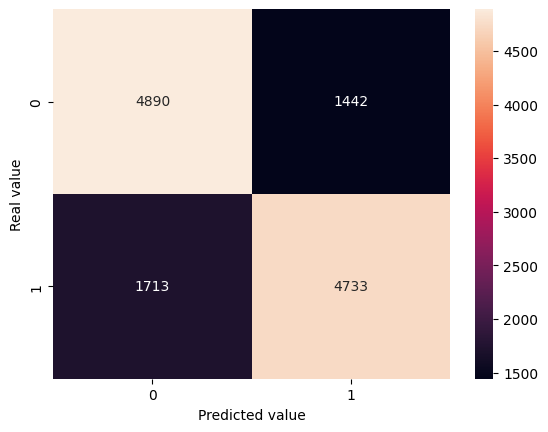

In [79]:
y_test_pred_2 = model_2.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, y_test_pred_2)
print('% de aciertos sobre el set de test:',test_accuracy, '\n')
print(classification_report(y_test, y_test_pred_2), '\n')
cm = confusion_matrix(y_test,y_test_pred_2)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

La diferencia con el modelo anterior es que tiene un Accuracy un poco menor, por lo tanto es menos preciso en general.

# Segunda iteración.

Se trabajará sobre el mismo dataframe balanceado.

- ## Dependencias ampliadas.

In [80]:
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, log_loss, roc_curve, auc
from sklearn.model_selection import train_test_split

Se volverán a copiar las instancias de entrenamiento para separar ambas partes y poder visualizarlas por separado.

- ## Train - Test - Val split.

In [81]:
train_df_lluvia, test_df_lluvia = train_test_split(balanced_df_lluvia, test_size=0.2, random_state=42)
train_df_lluvia, val_df_lluvia = train_test_split(train_df_lluvia, test_size=0.1, random_state=42)
display(train_df_lluvia.shape)
display(val_df_lluvia.shape)
display(test_df_lluvia.shape)

(45999, 21)

(5111, 21)

(12778, 21)

- ## Selección de features

In [82]:
target = 'RainTomorrow'
features = [col for col in balanced_df_lluvia.columns if(col != target)]
features

['Location',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp3pm',
 'RainToday',
 'Month',
 'WindSpeed_mean',
 'Season_Spring',
 'Season_Summer',
 'Season_Winter']

- ### Armado de los distintos sets de variables independientes y dependientes.

In [83]:
X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]

In [84]:
X_val = val_df_lluvia[features]
y_val = val_df_lluvia[target]

In [85]:
X_test = test_df_lluvia[features]
y_test = test_df_lluvia[target]

- ## Modelos utilizados.

- ### Árbol de decisión

Accuracy sobre el set de entrenamiento: 0.7671471118937369 

Accuracy sobre el set de validación: 0.7644296615143807 

              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2614
           1       0.77      0.75      0.76      2497

    accuracy                           0.76      5111
   macro avg       0.76      0.76      0.76      5111
weighted avg       0.76      0.76      0.76      5111
 



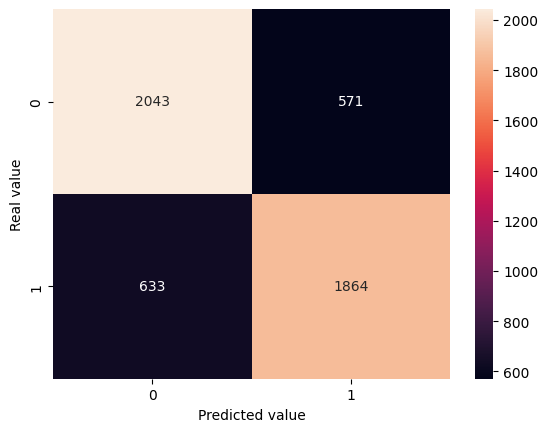

Log loss sobre el set de entrenamiento: 0.4798395888781426 

Log loss sobre el set de validación: 0.49925732551561885 

AUC sobre el set de validación: 0.8443593674306642



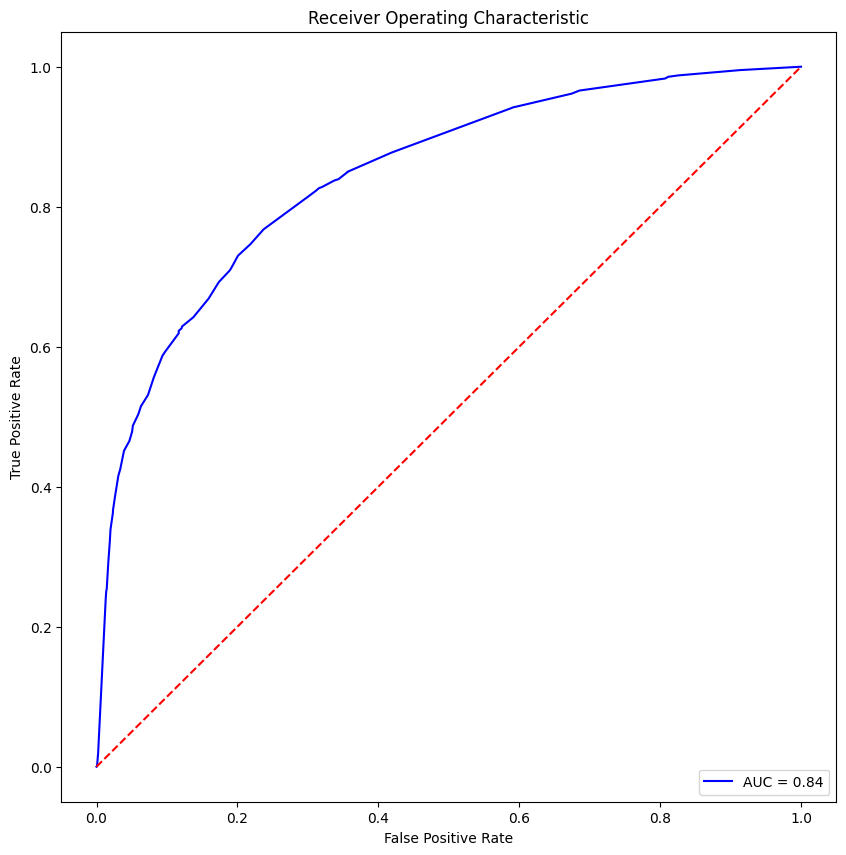

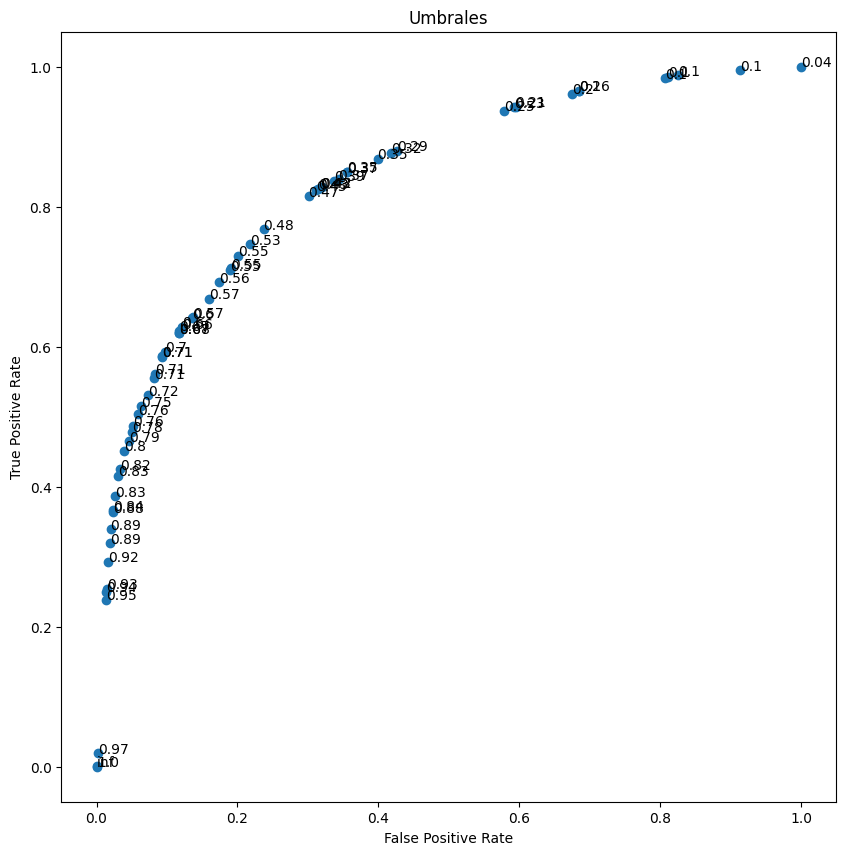

In [86]:
#---------------------------------------------------
# Entrenamiento y validación.

model_1 = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=6)
model_1.fit(X_train, y_train)

y_train_pred = model_1.predict(X_train)
y_val_pred = model_1.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_1.predict_proba(X_train)
y_val_pred_proba = model_1.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')
#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# ROC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
#-----------------------------------------------------
# Análisis de umbrales.

fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))
#-----------------------------------------------------

- ### Random Forest.

- #### Buscando la mejor cantidad de árboles sin que el modelo overfiteé.

>1, train: 0.890, val: 0.695
>2, train: 0.891, val: 0.702
>3, train: 0.952, val: 0.738
>4, train: 0.952, val: 0.744
>5, train: 0.973, val: 0.760
>6, train: 0.973, val: 0.762
>7, train: 0.984, val: 0.771
>8, train: 0.984, val: 0.771
>9, train: 0.989, val: 0.775
>10, train: 0.989, val: 0.776
>11, train: 0.992, val: 0.781
>12, train: 0.992, val: 0.779
>13, train: 0.994, val: 0.784
>14, train: 0.994, val: 0.787
>15, train: 0.996, val: 0.787
>16, train: 0.996, val: 0.785
>17, train: 0.997, val: 0.788
>18, train: 0.997, val: 0.788
>19, train: 0.997, val: 0.791
>20, train: 0.997, val: 0.792
>21, train: 0.998, val: 0.792
>22, train: 0.998, val: 0.792
>23, train: 0.998, val: 0.791
>24, train: 0.998, val: 0.794
>25, train: 0.998, val: 0.795
>26, train: 0.998, val: 0.792
>27, train: 0.999, val: 0.795
>28, train: 0.999, val: 0.797
>29, train: 0.999, val: 0.796
>30, train: 0.999, val: 0.796
>31, train: 0.999, val: 0.796
>32, train: 0.999, val: 0.795
>33, train: 0.999, val: 0.797
>34, train: 0.999, 

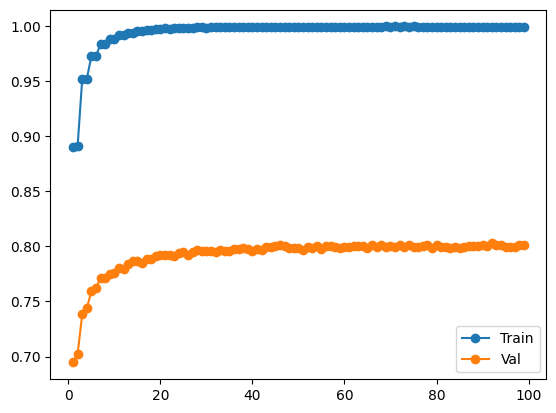

In [87]:
train_scores = []
val_scores = []

estimadores = [i for i in range(1, 100)]

for i in estimadores:

    model_2 = RandomForestClassifier(n_estimators=i, class_weight='balanced', random_state = 42)
    model_2.fit(X_train, y_train)
    train_yhat = model_2.predict(X_train)
    train_acc = metrics.accuracy_score(y_train, train_yhat)
    train_scores.append(train_acc)

    val_yhat = model_2.predict(X_val)
    val_acc = metrics.accuracy_score(y_val, val_yhat)
    val_scores.append(val_acc)

    print('>%d, train: %.3f, val: %.3f' % (i, train_acc, val_acc))

plt.plot(estimadores, train_scores, '-o', label='Train')
plt.plot(estimadores, val_scores, '-o', label='Val')
plt.legend()
plt.show()

Se observa que el mayor valor de Acurracy de val se estanca en n=45, que es donde aproximadamente el valor de accuracy de train comienza a descender, siendo un claro indicio de overfitting. Se tomará este punto de inflexión como cantidad de estimadores.

Accuracy sobre el set de entrenamiento: 0.999434770321094 

Accuracy sobre el set de validación: 0.8006261005674037 

              precision    recall  f1-score   support

           0       0.81      0.80      0.80      2614
           1       0.79      0.80      0.80      2497

    accuracy                           0.80      5111
   macro avg       0.80      0.80      0.80      5111
weighted avg       0.80      0.80      0.80      5111
 



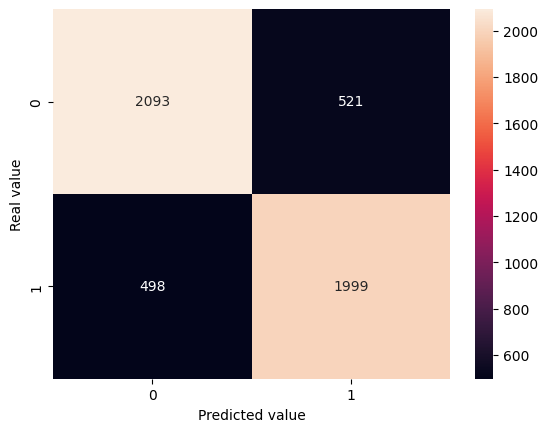

Log loss sobre el set de entrenamiento: 0.12195596466741311 

Log loss sobre el set de validación: 0.44260588341430507 

AUC sobre el set de validación: 0.8798578952738697



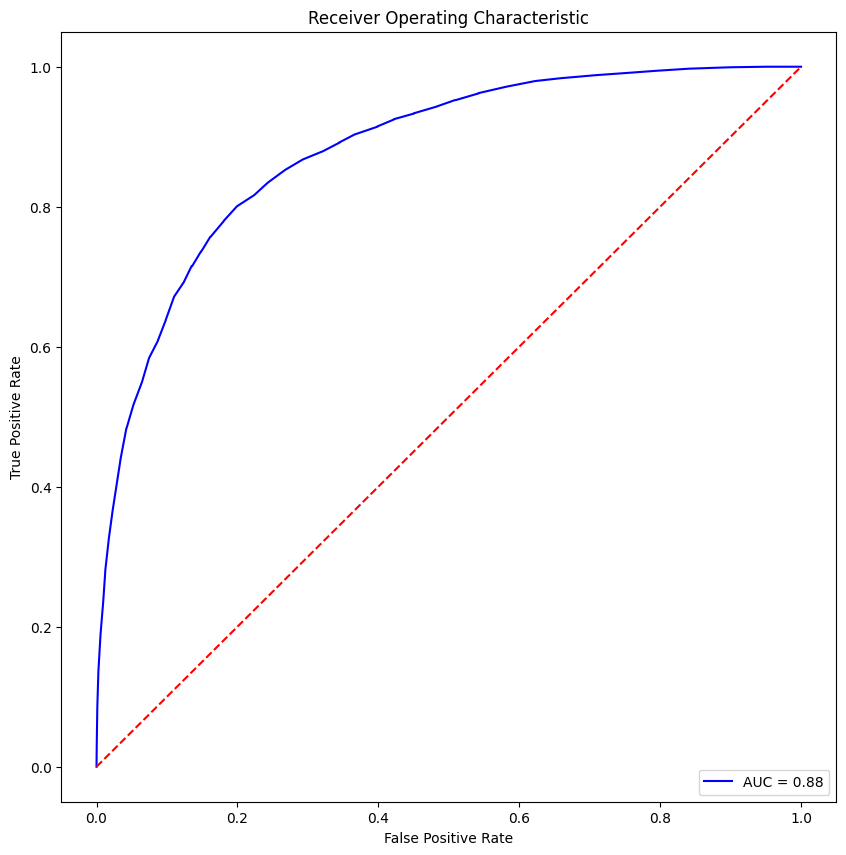

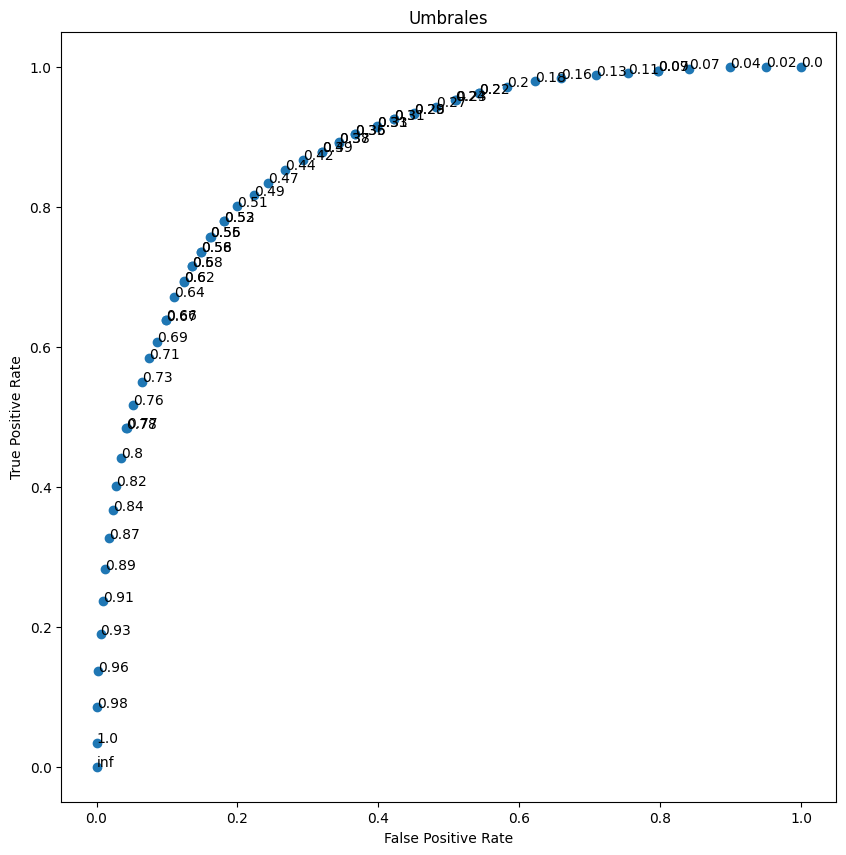

In [88]:
#---------------------------------------------------
# Entrenamiento y validación.

model_2 = RandomForestClassifier(n_estimators=45, class_weight='balanced', random_state = 42)
model_2.fit(X_train, y_train)

y_train_pred = model_2.predict(X_train)
y_val_pred = model_2.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_2.predict_proba(X_train)
y_val_pred_proba = model_2.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')

#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

Corrección de umbral sobre validación (optimal cutoff).

In [89]:
oc_df = pd.DataFrame({'tpr':tpr, 'fpr':fpr, 'thr':threshold})
oc_df

,tpr,fpr,thr
0,0.000000,0.000000,inf
1,0.034441,0.000383,1.000000
2,0.084902,0.001148,0.977778
3,0.136163,0.002678,0.955556
4,0.189427,0.005738,0.933333
...,...,...,...
58,0.994393,0.797628,0.072222
59,0.997197,0.840857,0.066667
60,0.999199,0.899005,0.044444
61,1.000000,0.950650,0.022222


- #### Maximizando la función beneficio - costo.

In [90]:
oc_df['tpr-fpr'] = oc_df['tpr'] - oc_df['fpr']
oc_df

,tpr,fpr,thr,tpr-fpr
0,0.000000,0.000000,inf,0.000000
1,0.034441,0.000383,1.000000,0.034059
2,0.084902,0.001148,0.977778,0.083754
3,0.136163,0.002678,0.955556,0.133486
4,0.189427,0.005738,0.933333,0.183689
...,...,...,...,...
58,0.994393,0.797628,0.072222,0.196765
59,0.997197,0.840857,0.066667,0.156340
60,0.999199,0.899005,0.044444,0.100194
61,1.000000,0.950650,0.022222,0.049350


In [91]:
oc_df.sort_values('tpr-fpr', ascending = False).head()

,tpr,fpr,thr,tpr-fpr
30,0.800561,0.199311,0.511111,0.601249
29,0.779736,0.180566,0.515555,0.599170
28,0.779335,0.180566,0.533333,0.598769
26,0.756908,0.161438,0.555556,0.595470
27,0.756908,0.161821,0.549628,0.595087


Puede observarse que el valor óptimo es 0.511, lo cuál condice con el gráfico.

In [92]:
y_val_pred

array([0, 1, 0, ..., 0, 1, 0])

In [93]:
y_val_pred_corrected = [0 if i <= 0.511 else 1 for i in y_val_pred]
print(y_val_pred_corrected)

[0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 

- #### Nuevo umbral sobre Validación.

Accuracy sobre el set de validación: 0.8006261005674037 

              precision    recall  f1-score   support

           0       0.81      0.80      0.80      2614
           1       0.79      0.80      0.80      2497

    accuracy                           0.80      5111
   macro avg       0.80      0.80      0.80      5111
weighted avg       0.80      0.80      0.80      5111
 



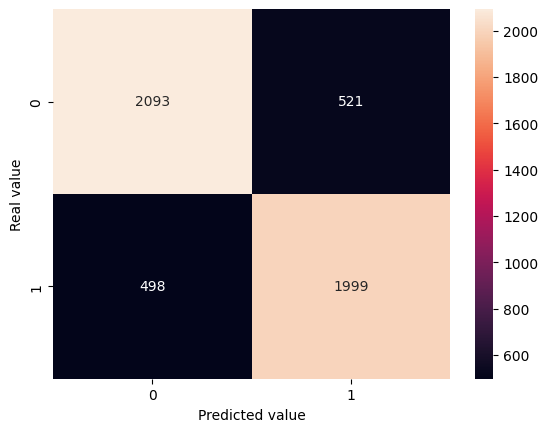

In [94]:
val_accuracy = metrics.accuracy_score(y_val, y_val_pred_corrected)
print('Accuracy sobre el set de validación:',val_accuracy, '\n')

print(classification_report(y_val,y_val_pred_corrected), '\n')

cm = confusion_matrix(y_val,y_val_pred_corrected)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

Se obtienen métricas idénticas a las anteriores, tanto en el set de validación como en el set de test, indicando que es lo mismo para este set de valores, estimar la cota inferior en 0.5 que en 0.525.



```
# Tiene formato de código
```

- ### KNN.

Accuracy sobre el set de entrenamiento: 0.7952998978238658 

Accuracy sobre el set de validación: 0.7554294658579535 

              precision    recall  f1-score   support

           0       0.75      0.79      0.77      2614
           1       0.76      0.72      0.74      2497

    accuracy                           0.76      5111
   macro avg       0.76      0.75      0.75      5111
weighted avg       0.76      0.76      0.76      5111
 



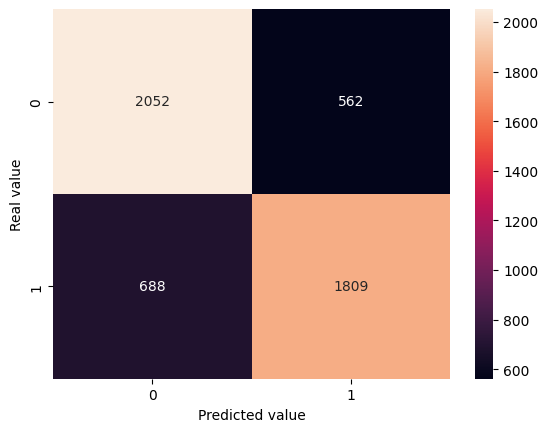

Log loss sobre el set de entrenamiento: 0.4304013147098053 

Log loss sobre el set de validación: 0.7318471242934343 

AUC sobre el set de validación: 0.8317352667117911



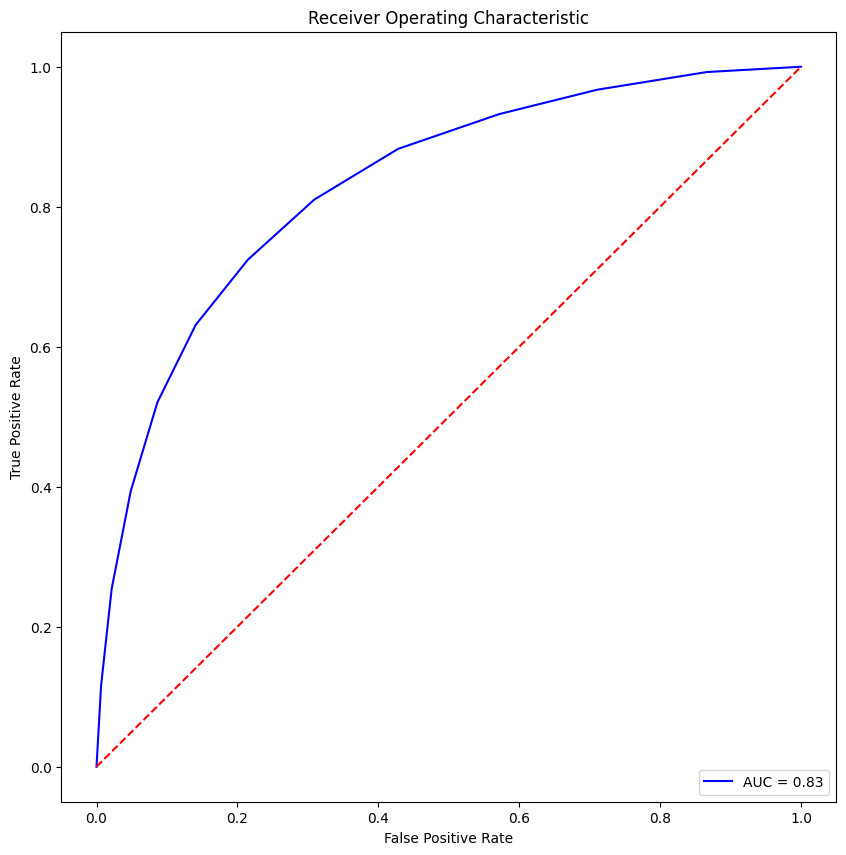

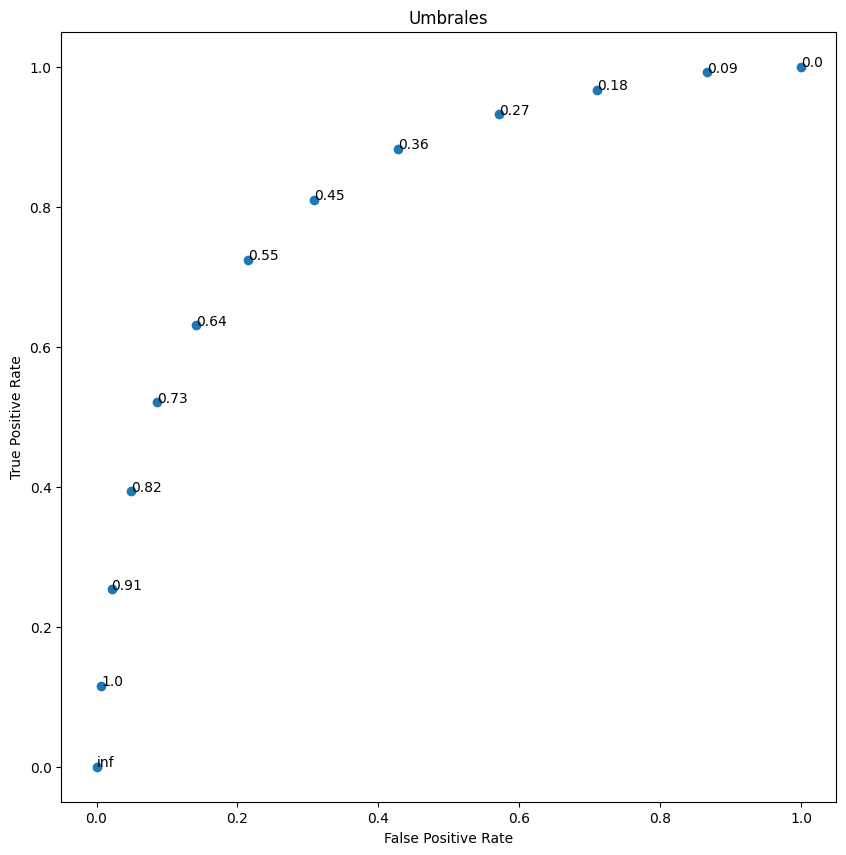

In [95]:
#---------------------------------------------------
# Entrenamiento y validación.

model_3 = KNeighborsClassifier(n_neighbors=11)
model_3.fit(X_train, y_train)

y_train_pred = model_3.predict(X_train)
y_val_pred = model_3.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_3.predict_proba(X_train)
y_val_pred_proba = model_3.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')

#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

- ### Regresión logística.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy sobre el set de entrenamiento: 0.7693862910063263 

Accuracy sobre el set de validación: 0.7773429857170808 

              precision    recall  f1-score   support

           0       0.78      0.79      0.78      2614
           1       0.78      0.76      0.77      2497

    accuracy                           0.78      5111
   macro avg       0.78      0.78      0.78      5111
weighted avg       0.78      0.78      0.78      5111
 



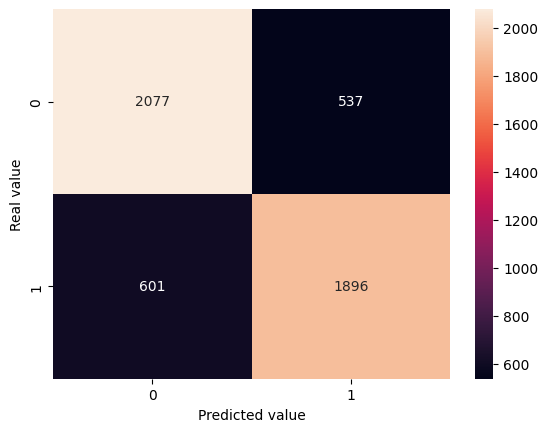

Log loss sobre el set de entrenamiento: 0.4806486831703841 

Log loss sobre el set de validación: 0.47392387733938035 

AUC sobre el set de validación: 0.8545582932112262



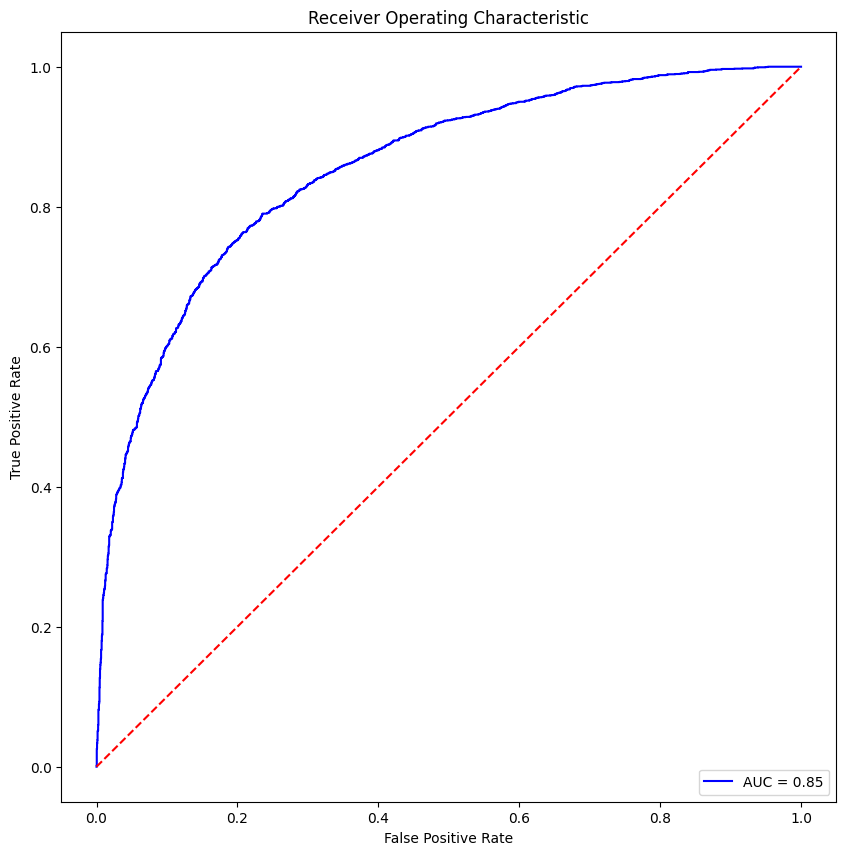

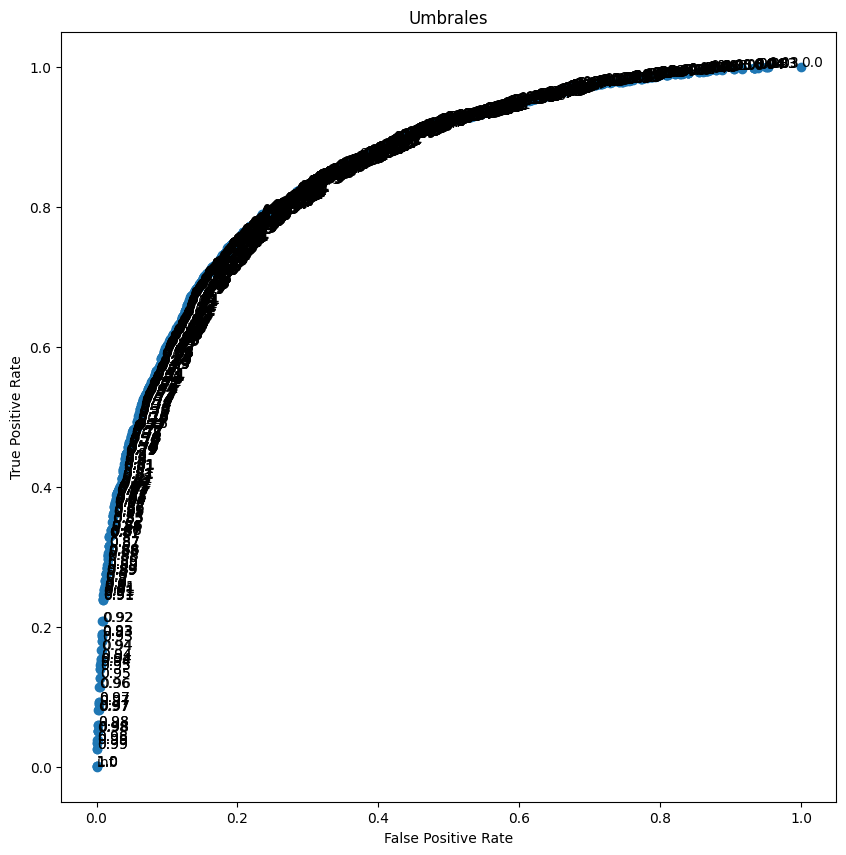

In [96]:
#---------------------------------------------------
# Entrenamiento y validación.

model_4 = LogisticRegression()
model_4.fit(X_train, y_train)

y_train_pred = model_4.predict(X_train)
y_val_pred = model_4.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_4.predict_proba(X_train)
y_val_pred_proba = model_4.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')

#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

Luego de haber tuneado a mano algunos hiperparámetros de los modelos para que performen lo mejor posible sobre el set de validación, se probaran los mismos en el set de test.

- ### Test sobre Árbol de decisión.

Accuracy sobre el set de testeo: 0.7634997652214744 

              precision    recall  f1-score   support

           0       0.75      0.78      0.77      6332
           1       0.77      0.75      0.76      6446

    accuracy                           0.76     12778
   macro avg       0.76      0.76      0.76     12778
weighted avg       0.76      0.76      0.76     12778
 



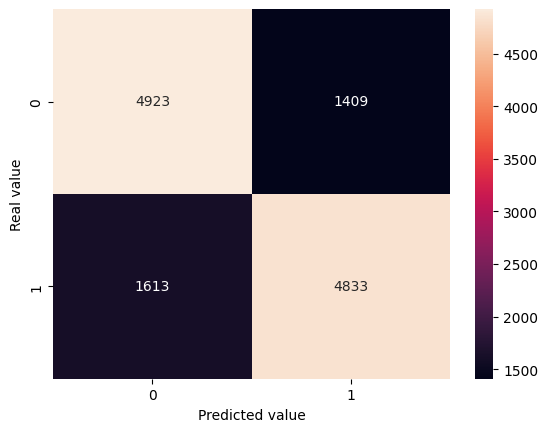

AUC sobre el set de test: 0.8413374883305772



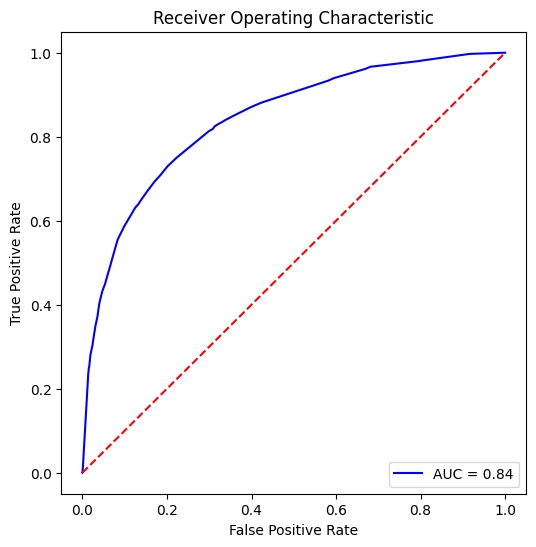

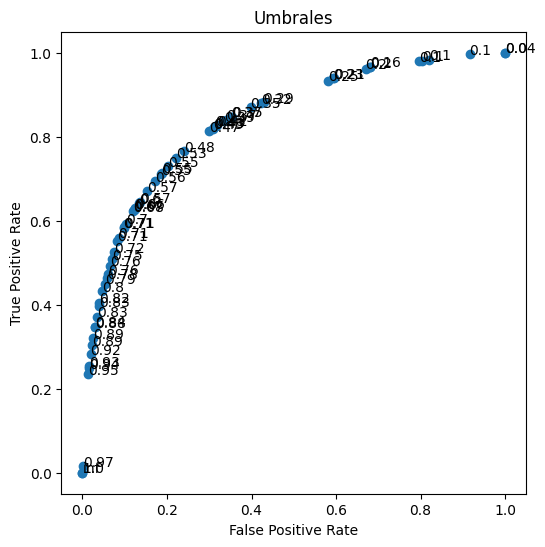

In [97]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_1.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_1.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
#plt.xlim([0, 1])
#plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

- ### Test sobre Random Forest.

Accuracy sobre el set de testeo: 0.8023164814524965 

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      6332
           1       0.81      0.80      0.80      6446

    accuracy                           0.80     12778
   macro avg       0.80      0.80      0.80     12778
weighted avg       0.80      0.80      0.80     12778
 



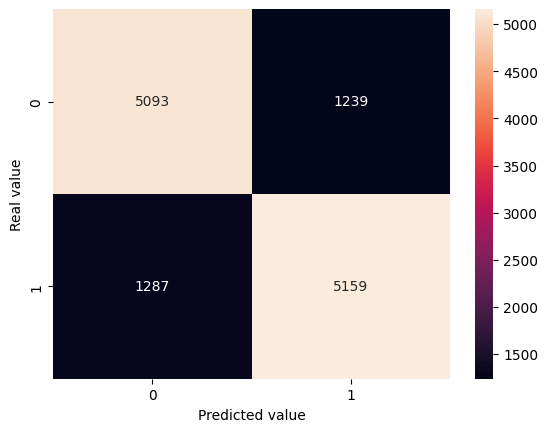

AUC sobre el set de test: 0.8817996989029223



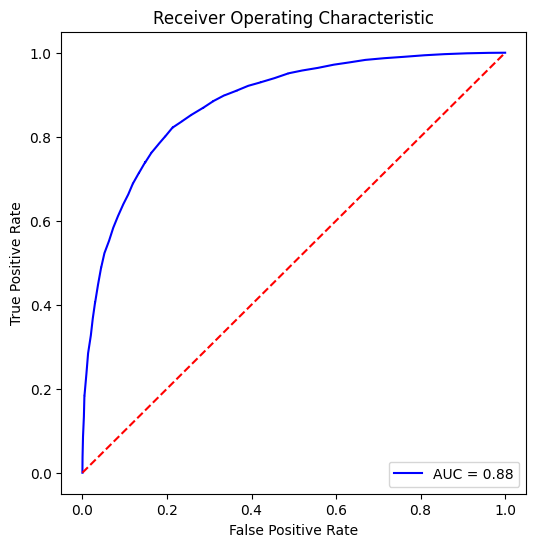

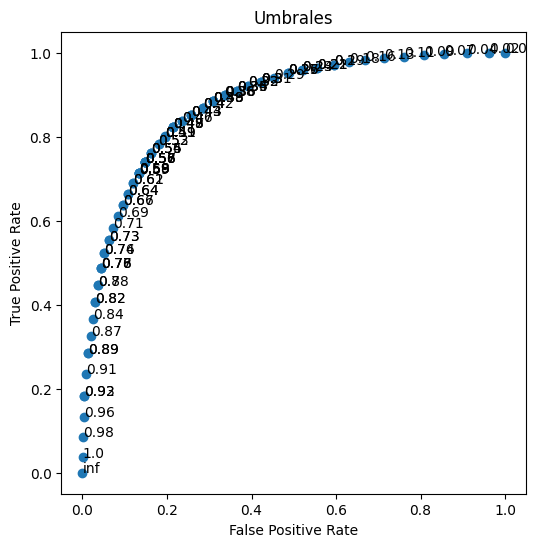

In [98]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_2.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_2.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

- ### Test sobre KNN.

Accuracy sobre el set de testeo: 0.753560807638128 

              precision    recall  f1-score   support

           0       0.74      0.79      0.76      6332
           1       0.77      0.72      0.75      6446

    accuracy                           0.75     12778
   macro avg       0.75      0.75      0.75     12778
weighted avg       0.75      0.75      0.75     12778
 



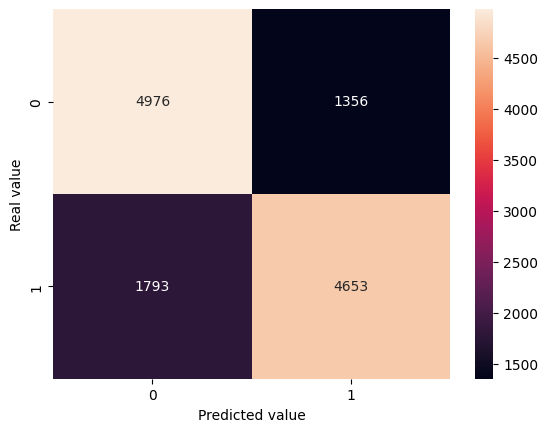

AUC sobre el set de test: 0.8299330592125571



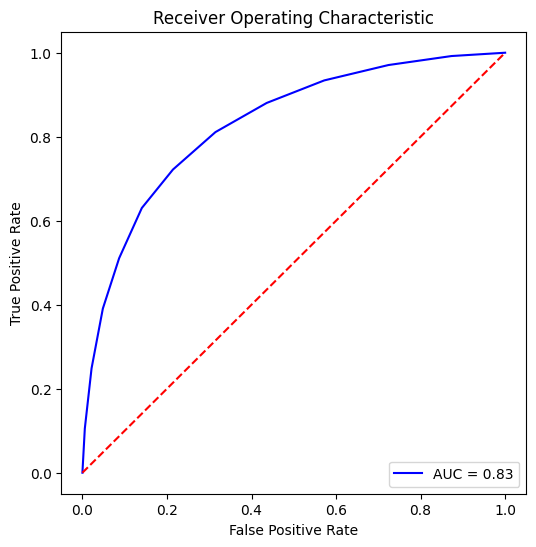

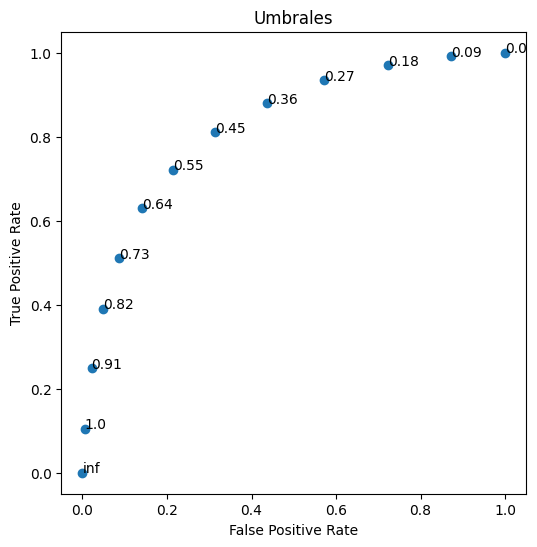

In [99]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_3.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_3.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

- ### Test sobre Regresión Logística.

Accuracy sobre el set de testeo: 0.7696040068868367 

              precision    recall  f1-score   support

           0       0.76      0.78      0.77      6332
           1       0.78      0.75      0.77      6446

    accuracy                           0.77     12778
   macro avg       0.77      0.77      0.77     12778
weighted avg       0.77      0.77      0.77     12778
 



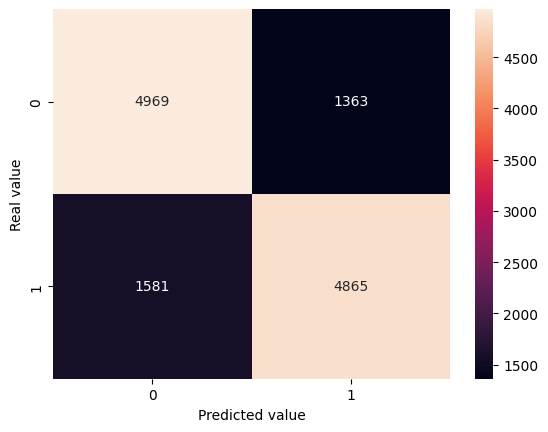

AUC sobre el set de validación: 0.8515572493110067



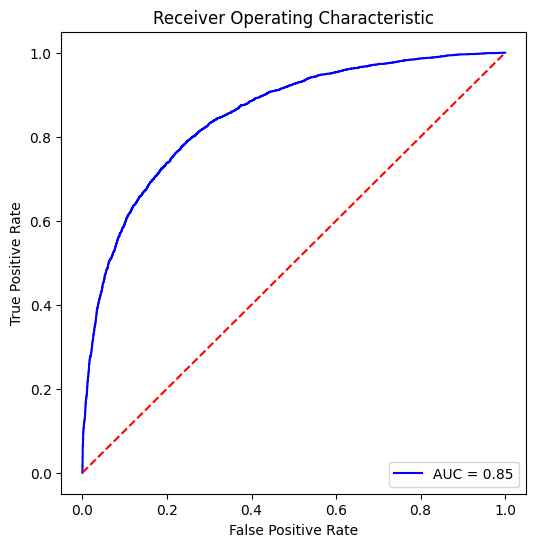

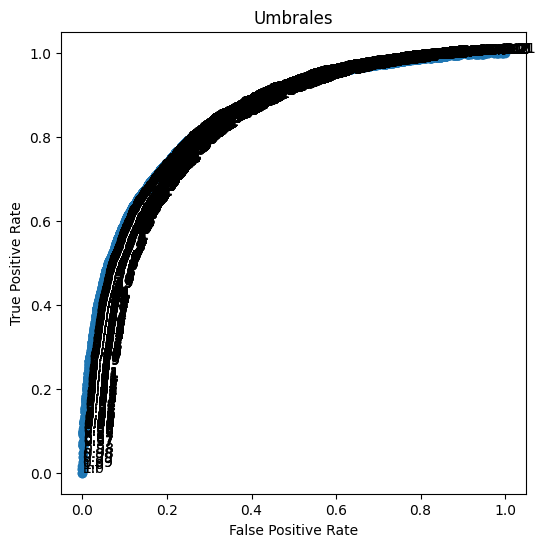

In [100]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_4.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_4.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

Se observa que el mejor resultado obtenido -hasta el momento- es con el modelo Random Forest con 45 estimadores, obteniendo para el set de test un Accuracy de 0.80 y un Recall para la clase 1 de 0.80. Los valores más altos obtenidos hasta ahora.

## Análisis PCA

De 20 (veinte) variables independientes, se intentará describir el problema con las variables independientes que describan un 95% la varianza total presente.

### Dependencias adicionales.

In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [102]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(.95)

pca.fit(X_train)

print(f"El 95% de la varianza total presente puede ser descripta por: {pca.n_components_} de un total de 20 variables.\n")

X_train = pca.transform(X_train)
X_test = pca.transform(X_test)

El 95% de la varianza total presente puede ser descripta por: 16 de un total de 20 variables.



### Random Forest.

Accuracy sobre el set de testeo: 0.783064642354046 

              precision    recall  f1-score   support

           0       0.78      0.78      0.78      6332
           1       0.78      0.79      0.79      6446

    accuracy                           0.78     12778
   macro avg       0.78      0.78      0.78     12778
weighted avg       0.78      0.78      0.78     12778
 



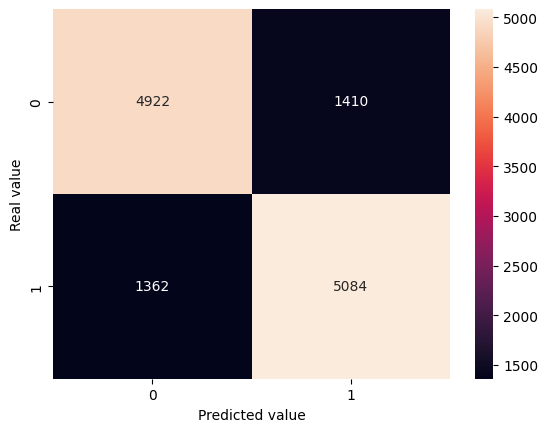

AUC sobre el set de test: 0.8589111784201087



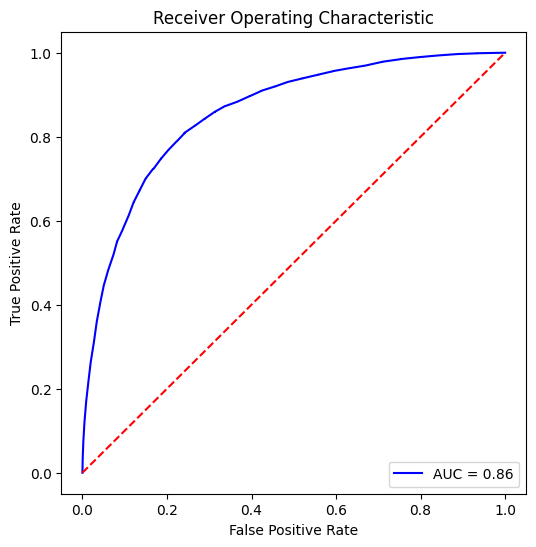

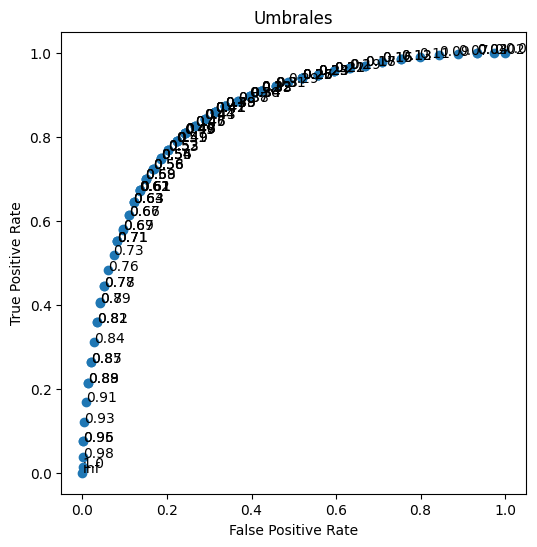

In [103]:
#---------------------------------------------------
# Fitteo y predicción.

model_2.fit(X_train, y_train)

y_test_pred = model_2.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_2.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

### Regresión Logistica.

Accuracy sobre el set de testeo: 0.7687431522930036 

              precision    recall  f1-score   support

           0       0.76      0.78      0.77      6332
           1       0.78      0.75      0.77      6446

    accuracy                           0.77     12778
   macro avg       0.77      0.77      0.77     12778
weighted avg       0.77      0.77      0.77     12778
 



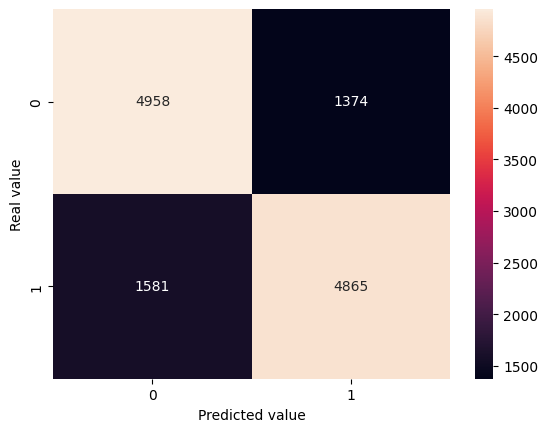

AUC sobre el set de test: 0.8492864526503189



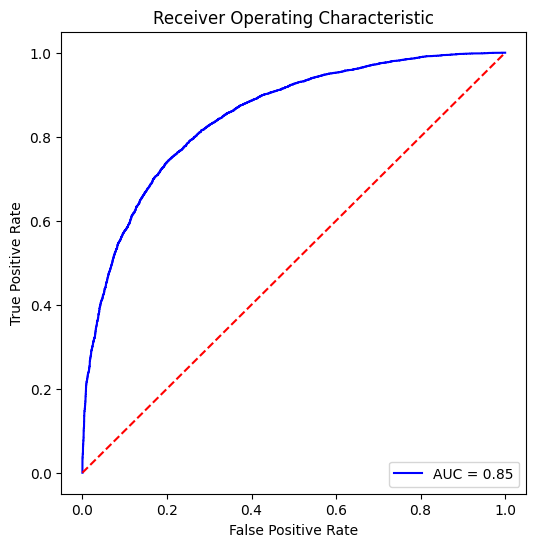

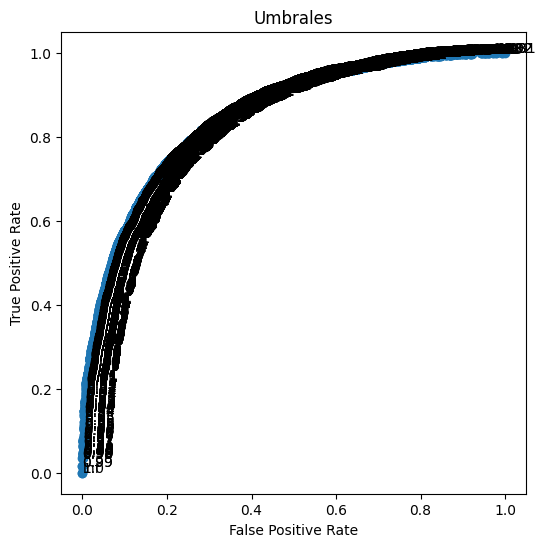

In [104]:
#---------------------------------------------------
# Fitteo y predicción.

model_4.fit(X_train, y_train)

y_test_pred = model_4.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_4.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
      ax.annotate(round(text, 2), (fpr[i], tpr[i]))

Puede visualizarse que la performance de ambos modelos bajo esta premisa es menor, por lo cuál se seguirá trabajando bajo la hipótesis principal, buscando mejorar las métricas existentes

# Tercera iteración.

## Dependencias adicionales.

In [105]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV

## División de dataframes.


In [145]:
X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]

X_val = val_df_lluvia[features]
y_val = val_df_lluvia[target]

X_test = test_df_lluvia[features]
y_test = test_df_lluvia[target]



## Validación y entrenamiento se unen para formar un único dataset.

In [144]:
display(train_df_lluvia)
display(val_df_lluvia)

train_df = pd.concat([train_df_lluvia, val_df_lluvia])
display(train_df_lluvia)

X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]



,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
87029,71,0.4,5.4,5.4,67.5,30.0,112.5,90.0,63.0,69.0,...,7.0,7.0,27.2,0,1,1,13.0,0.0,0.0,1.0
23717,102,0.2,1.6,7.2,292.5,39.0,315.0,292.5,85.0,84.0,...,4.0,5.0,22.6,0,1,5,17.0,1.0,0.0,0.0
16922,73,0.0,4.6,8.6,270.0,39.0,135.0,45.0,75.0,65.0,...,1.0,6.0,26.0,0,1,3,2.0,1.0,0.0,0.0
56802,78,0.4,4.6,8.6,270.0,46.0,292.5,270.0,95.0,91.0,...,8.0,8.0,10.2,0,1,10,24.5,0.0,0.0,0.0
15098,73,0.0,4.6,8.6,270.0,39.0,315.0,135.0,62.0,42.0,...,6.0,8.0,29.0,0,1,12,2.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89000,95,0.0,7.6,4.0,180.0,46.0,67.5,180.0,64.0,96.0,...,7.0,7.0,24.7,0,1,2,14.5,0.0,0.0,1.0
12235,44,0.0,3.0,9.2,90.0,37.0,112.5,135.0,64.0,35.0,...,1.0,2.0,20.2,0,0,6,12.5,1.0,0.0,0.0
11397,97,0.1,2.8,10.0,90.0,28.0,0.0,67.5,57.0,52.0,...,1.0,2.0,20.8,0,0,8,13.0,0.0,1.0,0.0
133218,70,0.4,1.0,8.6,157.5,46.0,90.0,157.5,98.0,72.0,...,8.0,7.5,14.6,0,1,6,17.5,1.0,0.0,0.0


,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
110675,90,0.0,5.8,10.9,270.0,39.0,67.5,225.0,51.0,55.0,...,5.0,1.0,21.1,0,0,12,15.0,0.0,0.0,1.0
88017,95,83.8,2.0,0.0,180.0,30.0,180.0,157.5,88.0,98.0,...,8.0,8.0,24.2,1,1,2,14.0,0.0,0.0,1.0
45018,71,0.0,4.6,8.6,67.5,37.0,337.5,45.0,60.0,69.0,...,8.0,8.0,22.0,0,0,12,24.5,0.0,0.0,1.0
116794,56,9.0,4.6,1.4,90.0,50.0,90.0,202.5,54.0,95.0,...,2.0,8.0,24.1,1,1,3,28.5,1.0,0.0,0.0
119804,63,4.6,3.4,9.8,270.0,48.0,292.5,292.5,75.0,53.0,...,6.0,4.0,25.6,1,1,3,25.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106342,22,0.0,7.4,9.6,180.0,61.0,157.5,180.0,65.0,33.0,...,1.0,2.0,27.6,0,0,2,25.0,0.0,0.0,1.0
54763,82,6.4,4.6,8.6,315.0,107.0,315.0,292.5,98.0,98.0,...,6.0,5.0,8.5,1,1,7,39.0,0.0,1.0,0.0
127264,111,0.0,4.6,8.6,67.5,44.0,67.5,112.5,65.0,52.0,...,6.0,5.0,23.3,0,0,3,22.0,1.0,0.0,0.0
66576,73,2.4,8.4,5.9,0.0,46.0,180.0,157.5,73.0,63.0,...,7.0,7.0,20.0,1,1,10,13.0,0.0,0.0,0.0


,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
87029,71,0.4,5.4,5.4,67.5,30.0,112.5,90.0,63.0,69.0,...,7.0,7.0,27.2,0,1,1,13.0,0.0,0.0,1.0
23717,102,0.2,1.6,7.2,292.5,39.0,315.0,292.5,85.0,84.0,...,4.0,5.0,22.6,0,1,5,17.0,1.0,0.0,0.0
16922,73,0.0,4.6,8.6,270.0,39.0,135.0,45.0,75.0,65.0,...,1.0,6.0,26.0,0,1,3,2.0,1.0,0.0,0.0
56802,78,0.4,4.6,8.6,270.0,46.0,292.5,270.0,95.0,91.0,...,8.0,8.0,10.2,0,1,10,24.5,0.0,0.0,0.0
15098,73,0.0,4.6,8.6,270.0,39.0,315.0,135.0,62.0,42.0,...,6.0,8.0,29.0,0,1,12,2.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89000,95,0.0,7.6,4.0,180.0,46.0,67.5,180.0,64.0,96.0,...,7.0,7.0,24.7,0,1,2,14.5,0.0,0.0,1.0
12235,44,0.0,3.0,9.2,90.0,37.0,112.5,135.0,64.0,35.0,...,1.0,2.0,20.2,0,0,6,12.5,1.0,0.0,0.0
11397,97,0.1,2.8,10.0,90.0,28.0,0.0,67.5,57.0,52.0,...,1.0,2.0,20.8,0,0,8,13.0,0.0,1.0,0.0
133218,70,0.4,1.0,8.6,157.5,46.0,90.0,157.5,98.0,72.0,...,8.0,7.5,14.6,0,1,6,17.5,1.0,0.0,0.0


## GridSearchCV usando StratifiedKFold.

### Árbol de decisión.

In [108]:
model_1 = DecisionTreeClassifier(random_state = 42)

# Hiperparámetros a optimizar.
criterion = ['gini']
max_depth = np.array([5, 10, None])
min_samples_split = np.array([2, 20])
min_samples_leaf = np.array([1, 5, 10])
ccp_alpha = np.array([0, 0.001, 0.01])

param_grid_1 = {'max_depth':max_depth,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf,
              'criterion':criterion,
              'ccp_alpha':ccp_alpha}

# Cross validation.
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# GridSearchCV.
gs_model_1 = GridSearchCV(estimator=model_1, param_grid=param_grid_1, cv=cv, n_jobs=-1, verbose=1)
gs_model_1.fit(X_train, y_train)
print(gs_model_1.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
{'ccp_alpha': np.float64(0.0), 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': np.int64(10), 'min_samples_split': np.int64(2)}


In [109]:
parameters_df = pd.DataFrame(gs_model_1.cv_results_)
display(parameters_df[parameters_df['params'] == gs_model_1.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
10,1.224741,0.203011,0.01157,0.00486,0.0,gini,10,10,2,"{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_d...",0.7675,0.76,0.7675,0.762826,0.757256,0.763016,0.004063,1


In [110]:
desvio_std = parameters_df['std_test_score'][gs_model_1.best_index_]

In [111]:
print(f"Accuracy sobre el set de entrenamiento completo: {gs_model_1.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {gs_model_1.best_score_} +/- {desvio_std}(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, gs_model_1.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.80473488554099

Accuracy promedio: 0.7630164620918152 +/- 0.004062508072532592

Accuracy sobre el set de test: 0.7686648927844734

Recall sobre el set de test: 0.7474402730375427


### Random Forest.

In [112]:
model_2 = RandomForestClassifier(random_state = 42, class_weight = 'balanced')

# Hiperparámetros a optimizar.
n_estimators = np.array([50, 100])
max_features = ['sqrt']
max_depth = np.array([None, 5])
min_samples_split = [2, 10]
min_samples_leaf = [1, 4]
bootstrap = [True]



param_grid_2 = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}


# GridSearchCV.
gs_model_2 = GridSearchCV(estimator=model_2, param_grid=param_grid_2, cv=cv, n_jobs=-1, verbose=1)
gs_model_2.fit(X_train, y_train)
print(gs_model_2.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': np.int64(100)}


In [113]:
parameters_df = pd.DataFrame(gs_model_2.cv_results_)
display(parameters_df[parameters_df['params'] == gs_model_2.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bootstrap,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,20.848507,1.098682,0.386419,0.094463,True,None,sqrt,1,10,100,"{'bootstrap': True, 'max_depth': None, 'max_fe...",0.800543,0.788587,0.798152,0.797609,0.792804,0.795539,0.004289,1


In [114]:
desvio_std = parameters_df['std_test_score'][gs_model_2.best_index_]

In [115]:
print(f"Accuracy sobre el set de entrenamiento completo: {gs_model_2.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {gs_model_2.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {gs_model_2.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, gs_model_2.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.9579990869366726

Accuracy promedio: 0.7955389739905566 +/- 0.004288837383389253

Accuracy sobre el set de test: 0.8026295194866176

Recall sobre el set de test: 0.8031337263419175


### KNN.

In [116]:
model_3 = KNeighborsClassifier()

# Hiperparámetros a optimizar.
n_neighbors = [3, 7, 15]
weights = ['distance']
metric = ['euclidean', 'manhattan']

param_grid_3 = {'n_neighbors': n_neighbors,
               'weights': weights,
               'metric': metric}

# GridSearchCV.
gs_model_3 = GridSearchCV(estimator=model_3, param_grid=param_grid_3, cv=cv, n_jobs=-1, verbose=1)
gs_model_3.fit(X_train, y_train)
print(gs_model_3.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}


In [117]:
parameters_df = pd.DataFrame(gs_model_3.cv_results_)
display(parameters_df[parameters_df['params'] == gs_model_3.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.027204,0.012972,25.992201,4.951444,manhattan,15,distance,"{'metric': 'manhattan', 'n_neighbors': 15, 'we...",0.781413,0.7775,0.782174,0.784457,0.781933,0.781495,0.002253,1


In [118]:
desvio_std = parameters_df['std_test_score'][gs_model_3.best_index_]

In [119]:
print(f"Accuracy sobre el set de entrenamiento completo: {gs_model_3.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {gs_model_3.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {gs_model_3.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, gs_model_3.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.9996956455575121

Accuracy promedio: 0.781495259409104 +/- 0.0022534400704314296

Accuracy sobre el set de test: 0.7850993895758335

Recall sobre el set de test: 0.7641948495190816


### Regresión Logística.

In [120]:
model_4 = LogisticRegression(random_state = 42)

# Hiperparámetros a optimizar.
C = np.logspace(-4, 4, 15)
penalty = ['l1', 'l2']
solver = ['liblinear']

param_grid_4 = {'C': C,
               'penalty': penalty,
               'solver': solver}

# GridSearchCV.
gs_model_4 = GridSearchCV(estimator=model_4, param_grid=param_grid_4, cv=cv, n_jobs=-1, verbose=1)
gs_model_4.fit(X_train, y_train)
print(gs_model_4.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'C': np.float64(0.019306977288832496), 'penalty': 'l2', 'solver': 'liblinear'}


In [121]:
parameters_df = pd.DataFrame(gs_model_4.cv_results_)
display(parameters_df[parameters_df['params'] == gs_model_4.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,0.355929,0.044716,0.003602,0.001761,0.019307,l2,liblinear,"{'C': 0.019306977288832496, 'penalty': 'l2', '...",0.784565,0.776522,0.778152,0.780543,0.770519,0.77806,0.004642,1


In [122]:
desvio_std = parameters_df['std_test_score'][gs_model_4.best_index_]

In [123]:
print(f"Accuracy sobre el set de entrenamiento completo: {gs_model_4.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {gs_model_4.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {gs_model_4.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, gs_model_4.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.7786908411052414

Accuracy promedio: 0.7780602286637961 +/- 0.004641852213923208

Accuracy sobre el set de test: 0.7795429644701831

Recall sobre el set de test: 0.7668321439652498


## RandomizedSearchCV usando StratifiedKFold.

### Árbol de decisión.

In [124]:
# RandomizedSearchCV.
rs_model_1 = RandomizedSearchCV(estimator=model_1, param_distributions=param_grid_1, cv=cv, n_jobs=-1, verbose=1)
rs_model_1.fit(X_train, y_train)
print(rs_model_1.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'min_samples_split': np.int64(20), 'min_samples_leaf': np.int64(10), 'max_depth': 10, 'criterion': 'gini', 'ccp_alpha': np.float64(0.0)}


In [125]:
parameters_df = pd.DataFrame(rs_model_1.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_1.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_min_samples_split,param_min_samples_leaf,param_max_depth,param_criterion,param_ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.654389,0.130081,0.008425,0.002551,20,10,10,gini,0.0,"{'min_samples_split': 20, 'min_samples_leaf': ...",0.7675,0.76,0.7675,0.762826,0.757256,0.763016,0.004063,1


In [126]:
desvio_std = parameters_df['std_test_score'][rs_model_1.best_index_]

In [127]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_1.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_1.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_1.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_1.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.80473488554099

Accuracy promedio: 0.7630164620918152 +/- 0.004062508072532592

Accuracy sobre el set de test: 0.7686648927844734

Recall sobre el set de test: 0.7474402730375427


### Random Forest.

In [128]:
# RandomizedSearchCV.
rs_model_2 = RandomizedSearchCV(estimator=model_2, param_distributions=param_grid_2, cv=cv, n_jobs=-1, verbose=1)
rs_model_2.fit(X_train, y_train)
print(rs_model_2.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'n_estimators': np.int64(100), 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [129]:
parameters_df = pd.DataFrame(rs_model_2.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_2.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_bootstrap,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,25.304848,3.223099,0.537438,0.148491,100,2,4,sqrt,None,True,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.800326,0.788478,0.79837,0.797609,0.788781,0.794713,0.005046,1


In [130]:
desvio_std = parameters_df['std_test_score'][rs_model_2.best_index_]

In [131]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_2.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_2.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_2.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_2.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.9331724602708754

Accuracy promedio: 0.7947127995954192 +/- 0.0050461519045860714

Accuracy sobre el set de test: 0.8018469244013148

Recall sobre el set de test: 0.7984796773192677


### KNN.

In [132]:
# RandomizedSearchCV.
rs_model_3 = RandomizedSearchCV(estimator=model_3, param_distributions=param_grid_3, cv=cv, n_jobs=-1, verbose=1)
rs_model_3.fit(X_train, y_train)
print(rs_model_3.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'weights': 'distance', 'n_neighbors': 15, 'metric': 'manhattan'}


In [133]:
parameters_df = pd.DataFrame(rs_model_3.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_3.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_weights,param_n_neighbors,param_metric,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.015811,0.007635,13.41261,2.409011,distance,15,manhattan,"{'weights': 'distance', 'n_neighbors': 15, 'me...",0.781413,0.7775,0.782174,0.784457,0.781933,0.781495,0.002253,1


In [134]:
desvio_std = parameters_df['std_test_score'][rs_model_3.best_index_]

In [135]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_3.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_3.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_3.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_3.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.9996956455575121

Accuracy promedio: 0.781495259409104 +/- 0.0022534400704314296

Accuracy sobre el set de test: 0.7850993895758335

Recall sobre el set de test: 0.7641948495190816


### Regresión Logística.

In [136]:
# RandomizedSearchCV.
rs_model_4 = RandomizedSearchCV(estimator=model_4, param_distributions=param_grid_4, cv=cv, n_jobs=-1, verbose=1)
rs_model_4.fit(X_train, y_train)
print(rs_model_4.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(0.019306977288832496)}


In [137]:
parameters_df = pd.DataFrame(rs_model_4.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_4.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_penalty,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.198343,0.013126,0.003078,0.000932,liblinear,l1,0.019307,"{'solver': 'liblinear', 'penalty': 'l1', 'C': ...",0.783913,0.775435,0.778152,0.780435,0.771932,0.777973,0.004106,1


In [138]:
desvio_std = parameters_df['std_test_score'][rs_model_4.best_index_]

In [139]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_4.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_4.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_4.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_4.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.7782125698384748

Accuracy promedio: 0.7779733028637328 +/- 0.0041064842151468115

Accuracy sobre el set de test: 0.7818124902175614

Recall sobre el set de test: 0.7679180887372014


In [140]:
train_df_lluvia[target].value_counts()

,count
RainTomorrow,
1,23001
0,22998


In [141]:
test_df_lluvia[target].value_counts()

,count
RainTomorrow,
1,6446
0,6332


## Modelos boosting.

### Dependencias adicionales.

In [142]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

### Train - Test - Val split.

In [148]:
train_df_lluvia, test_df_lluvia = train_test_split(balanced_df_lluvia, test_size=0.2, random_state=42)
train_df_lluvia, val_df_lluvia = train_test_split(train_df_lluvia, test_size=0.1, random_state=42)

X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]

X_val = val_df_lluvia[features]
y_val = val_df_lluvia[target]

X_test = test_df_lluvia[features]
y_test = test_df_lluvia[target]

### AdaBoost.

Accuracy sobre el set de entrenamiento: 0.7727341898736929 

Accuracy sobre el set de validación: 0.7751907650166308 

              precision    recall  f1-score   support

           0       0.78      0.78      0.78      2614
           1       0.77      0.77      0.77      2497

    accuracy                           0.78      5111
   macro avg       0.78      0.78      0.78      5111
weighted avg       0.78      0.78      0.78      5111
 



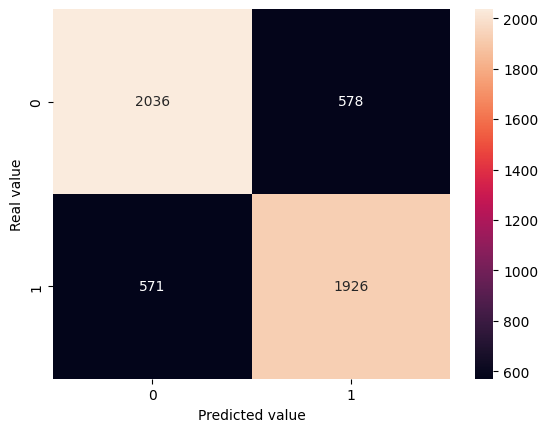

Log loss sobre el set de entrenamiento: 0.5691660644298024 

Log loss sobre el set de validación: 0.5680039836988912 

AUC sobre el set de validación: 0.8581142818972667



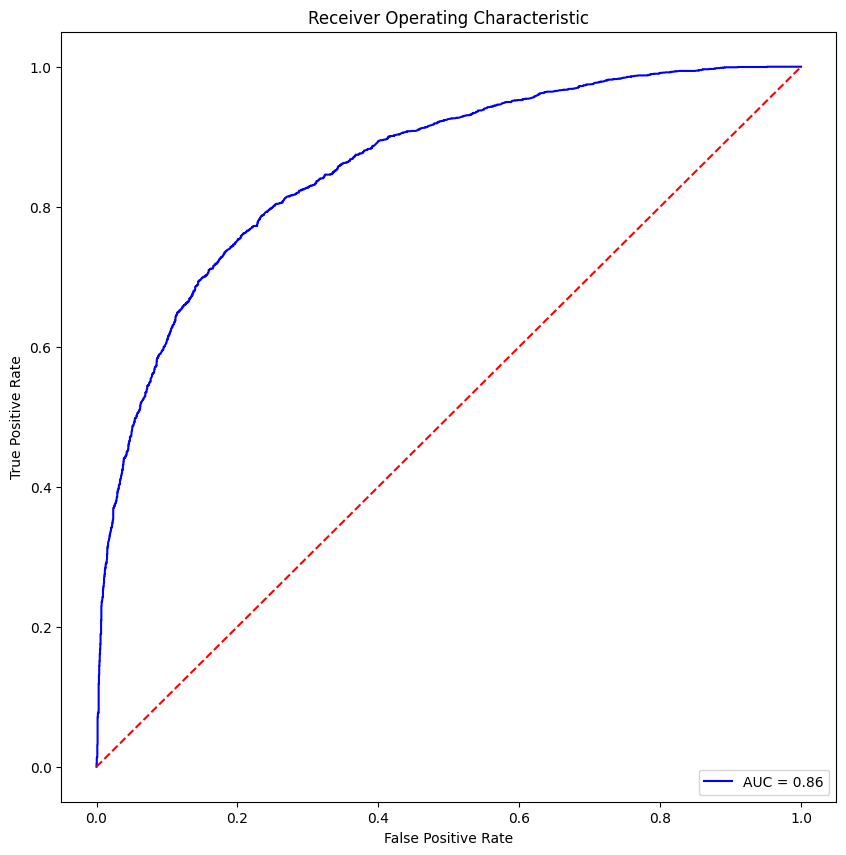

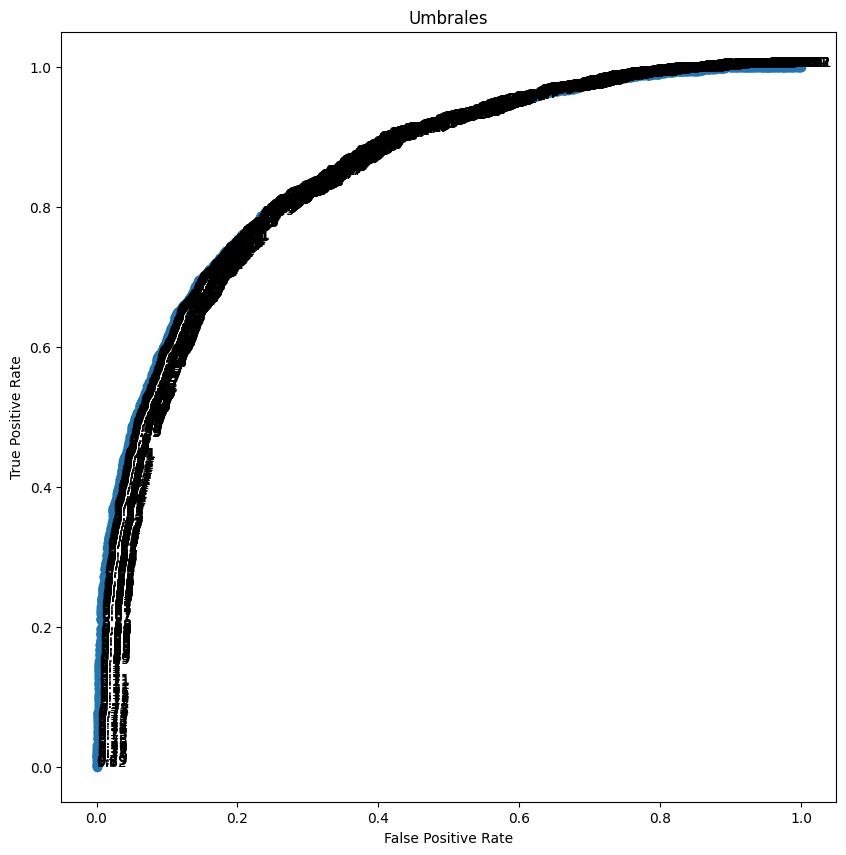

In [149]:
#---------------------------------------------------
# Entrenamiento y validación.

model_5 = AdaBoostClassifier(random_state=42)
model_5.fit(X_train, y_train)

y_train_pred = model_5.predict(X_train)
y_val_pred = model_5.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_5.predict_proba(X_train)
y_val_pred_proba = model_5.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')
#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# ROC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
#-----------------------------------------------------
# Análisis de umbrales.

fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))
#-----------------------------------------------------

### AdaBoost sobre Test.

Accuracy sobre el set de testeo: 0.7755517295351385 

              precision    recall  f1-score   support

           0       0.77      0.78      0.77      6332
           1       0.78      0.78      0.78      6446

    accuracy                           0.78     12778
   macro avg       0.78      0.78      0.78     12778
weighted avg       0.78      0.78      0.78     12778
 



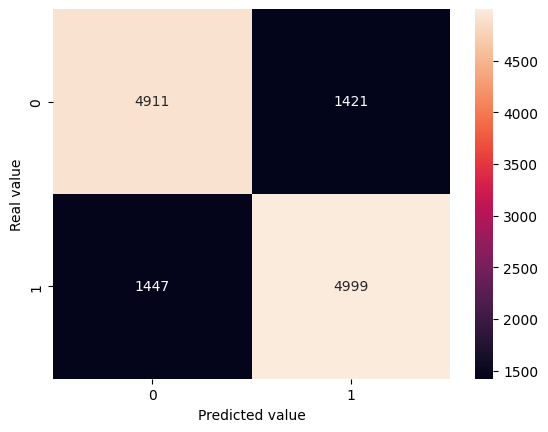

AUC sobre el set de test: 0.8572118723232359



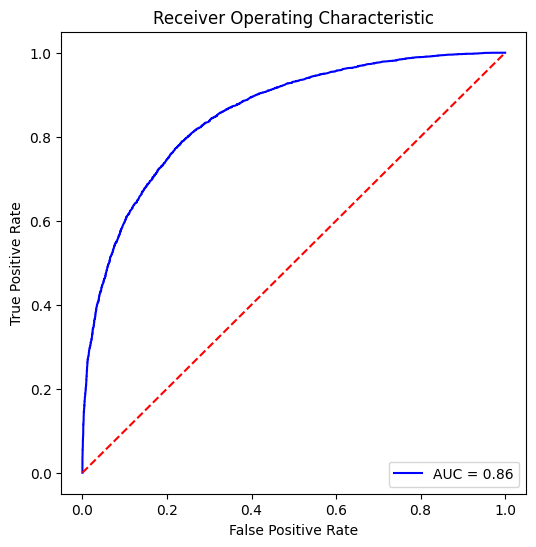

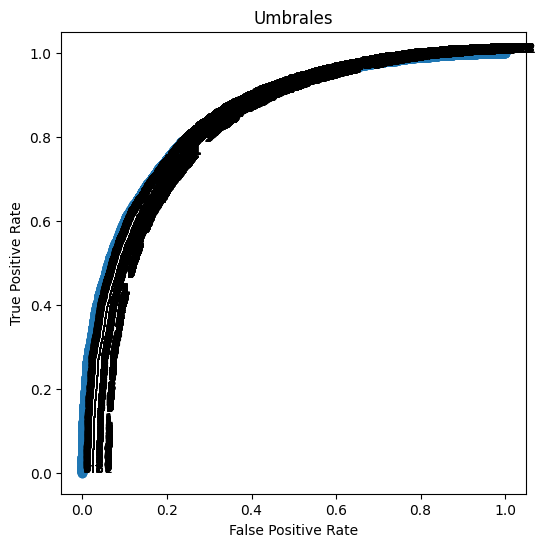

In [150]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_5.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_5.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

### Gradient Boosting.

Accuracy sobre el set de entrenamiento: 0.7917128633231157 

Accuracy sobre el set de validación: 0.7910389356290354 

              precision    recall  f1-score   support

           0       0.79      0.80      0.80      2614
           1       0.79      0.78      0.78      2497

    accuracy                           0.79      5111
   macro avg       0.79      0.79      0.79      5111
weighted avg       0.79      0.79      0.79      5111
 



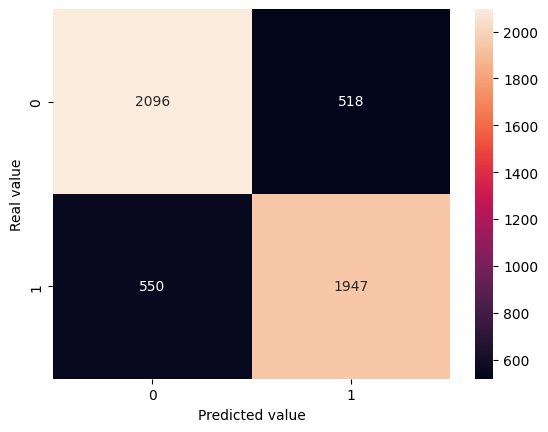

Log loss sobre el set de entrenamiento: 0.43975752551304137 

Log loss sobre el set de validación: 0.4446973587487162 

AUC sobre el set de validación: 0.8741050086423526



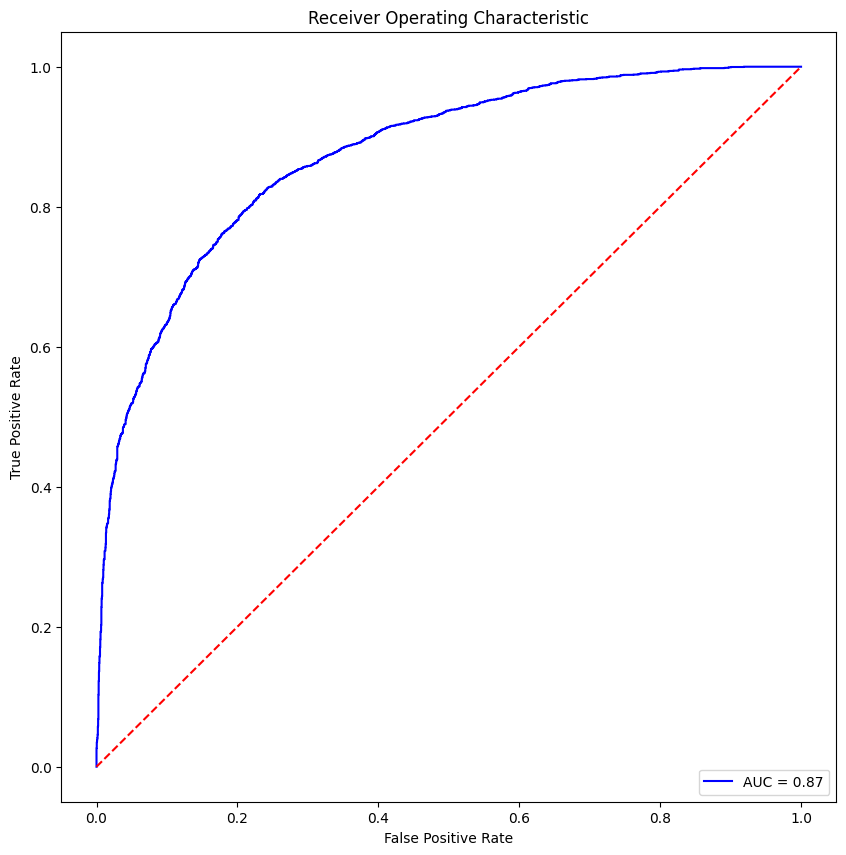

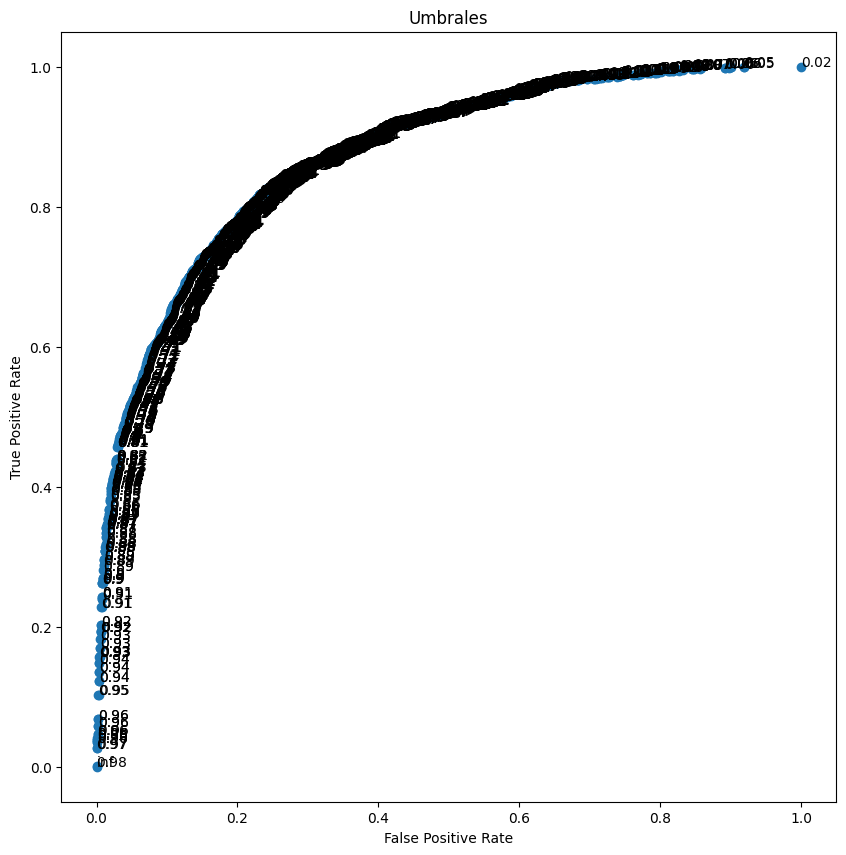

In [151]:
#---------------------------------------------------
# Entrenamiento y validación.

model_6 = GradientBoostingClassifier(random_state=42)
model_6.fit(X_train, y_train)

y_train_pred = model_6.predict(X_train)
y_val_pred = model_6.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_6.predict_proba(X_train)
y_val_pred_proba = model_6.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')
#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# ROC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
#-----------------------------------------------------
# Análisis de umbrales.

fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))
#-----------------------------------------------------

### Gradient Boosting sobre Test.

Accuracy sobre el set de testeo: 0.7893254030364689 

              precision    recall  f1-score   support

           0       0.78      0.80      0.79      6332
           1       0.80      0.78      0.79      6446

    accuracy                           0.79     12778
   macro avg       0.79      0.79      0.79     12778
weighted avg       0.79      0.79      0.79     12778
 



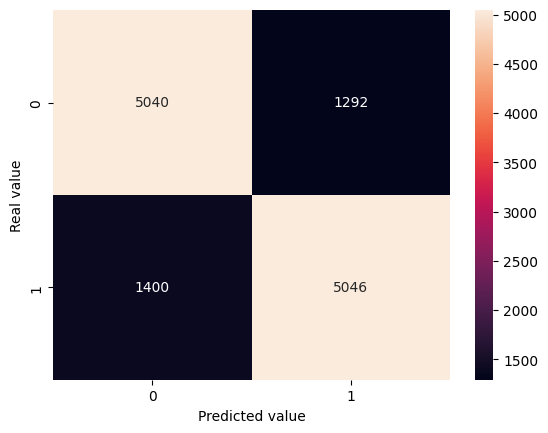

AUC sobre el set de test: 0.8744463087971817



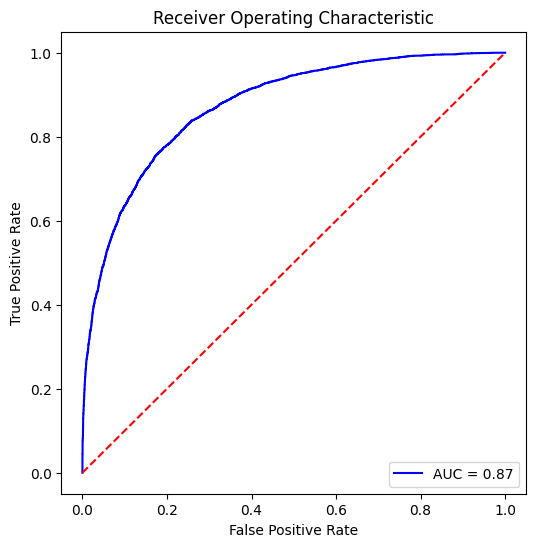

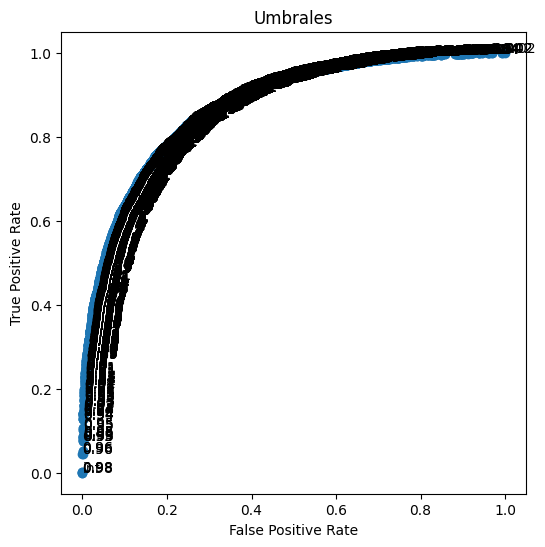

In [152]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_6.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_6.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

### XGBoost.

Accuracy sobre el set de entrenamiento: 0.8658666492749842 

Accuracy sobre el set de validación: 0.7951477206026218 

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      2614
           1       0.79      0.79      0.79      2497

    accuracy                           0.80      5111
   macro avg       0.80      0.80      0.80      5111
weighted avg       0.80      0.80      0.80      5111
 



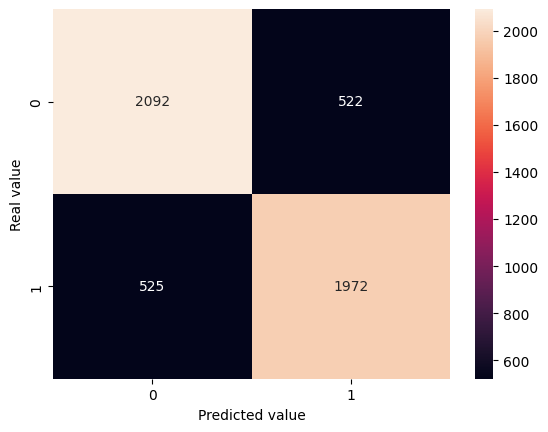

Log loss sobre el set de entrenamiento: 0.3128049184312812 

Log loss sobre el set de validación: 0.43102467315120163 

AUC sobre el set de validación: 0.8822849086846066



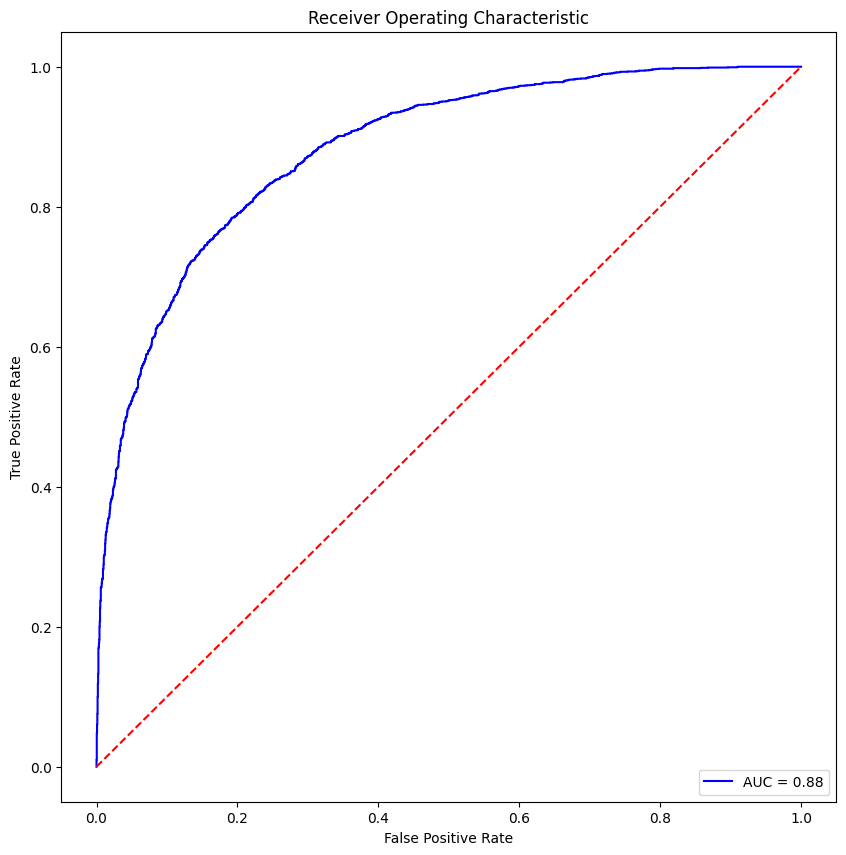

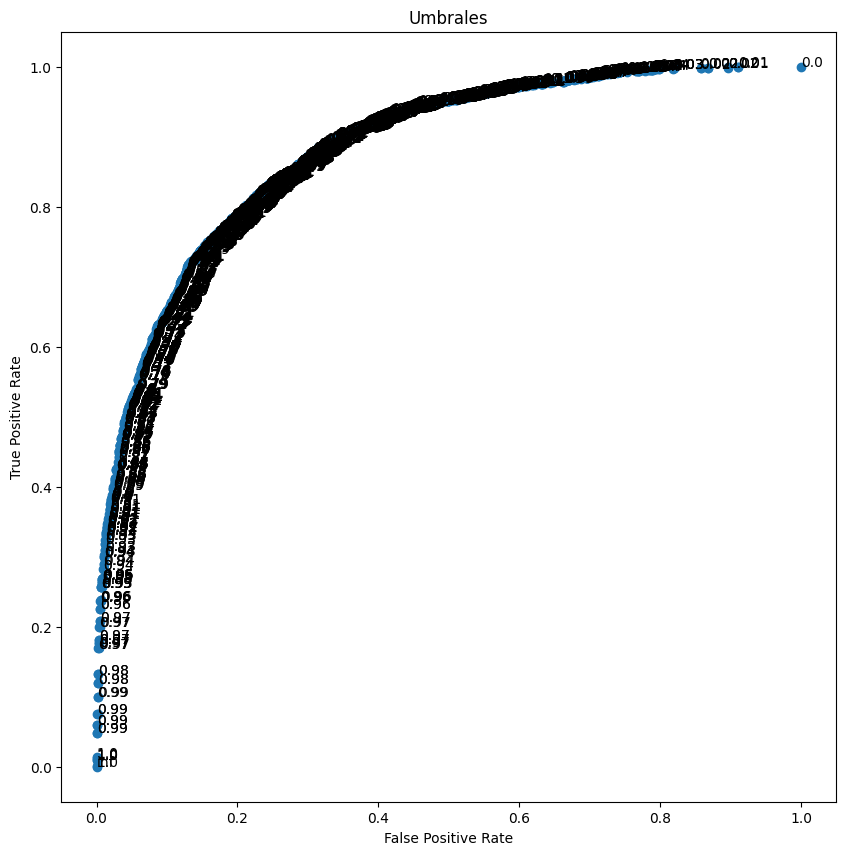

In [153]:
#---------------------------------------------------
# Entrenamiento y validación.

model_7 = xgb.XGBClassifier(objective = 'binary:logistic', seed=42)
model_7.fit(X_train, y_train)

y_train_pred = model_7.predict(X_train)
y_val_pred = model_7.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_7.predict_proba(X_train)
y_val_pred_proba = model_7.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')
#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# ROC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
#-----------------------------------------------------
# Análisis de umbrales.

fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))
#-----------------------------------------------------

### XGBoost sobre Test.

Accuracy sobre el set de testeo: 0.8041947096572234 

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      6332
           1       0.81      0.80      0.80      6446

    accuracy                           0.80     12778
   macro avg       0.80      0.80      0.80     12778
weighted avg       0.80      0.80      0.80     12778
 



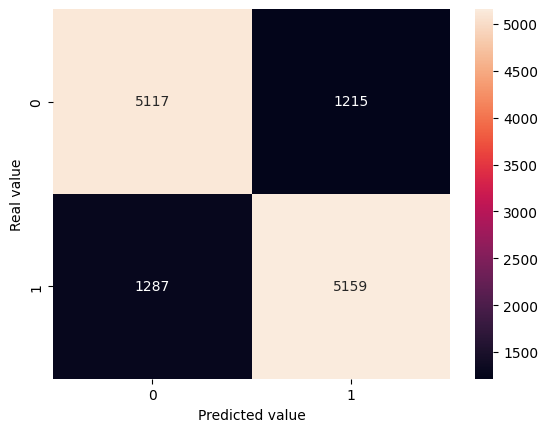

AUC sobre el set de test: 0.8853636013774181



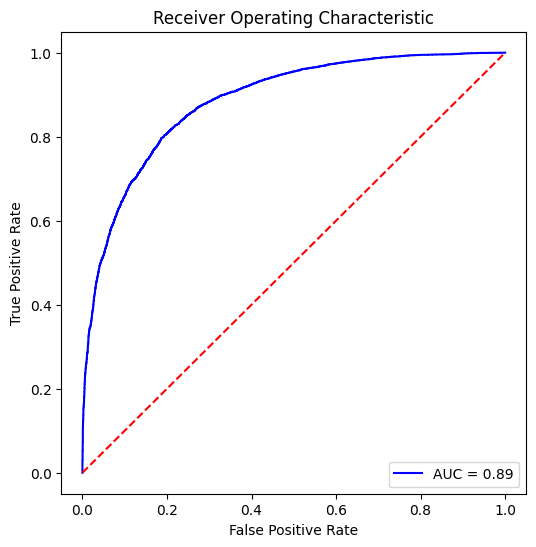

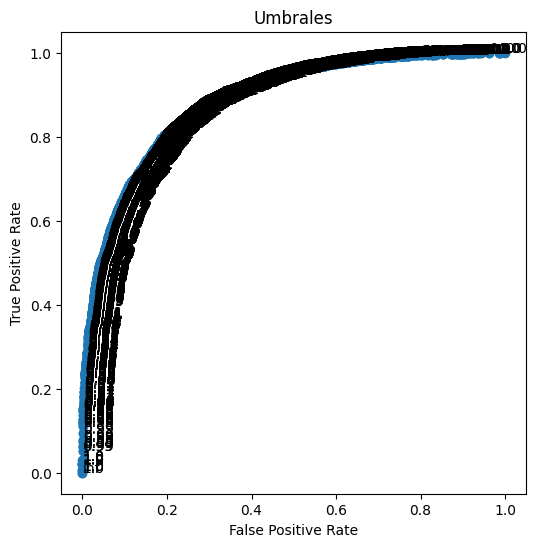

In [154]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_7.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_7.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

### LightGBM.

[LightGBM] [Info] Number of positive: 23001, number of negative: 22998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1674
[LightGBM] [Info] Number of data points in the train set: 45999, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Accuracy sobre el set de entrenamiento: 0.818387356246875 

Accuracy sobre el set de validación: 0.8019956955585991 

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      2614
           1       0.80      0.80      0.80      2497

    accuracy                           0.80      5111
   macro avg       0.80      0.80      0.80      5111
weighted avg       0.80      0.80      0.80      5111


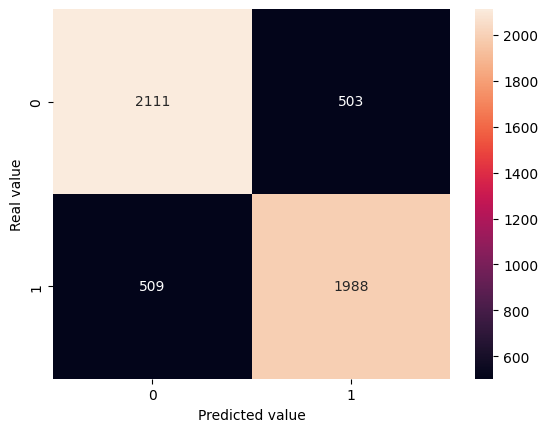

Log loss sobre el set de entrenamiento: 0.3128049184312812 

Log loss sobre el set de validación: 0.43102467315120163 

AUC sobre el set de validación: 0.8822849086846066



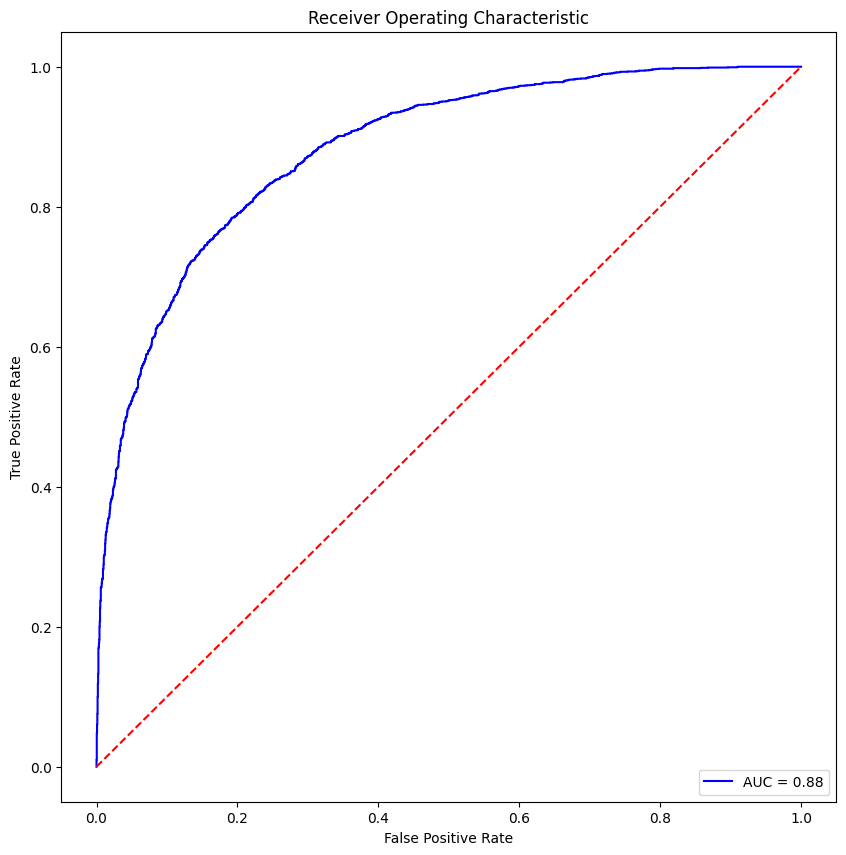

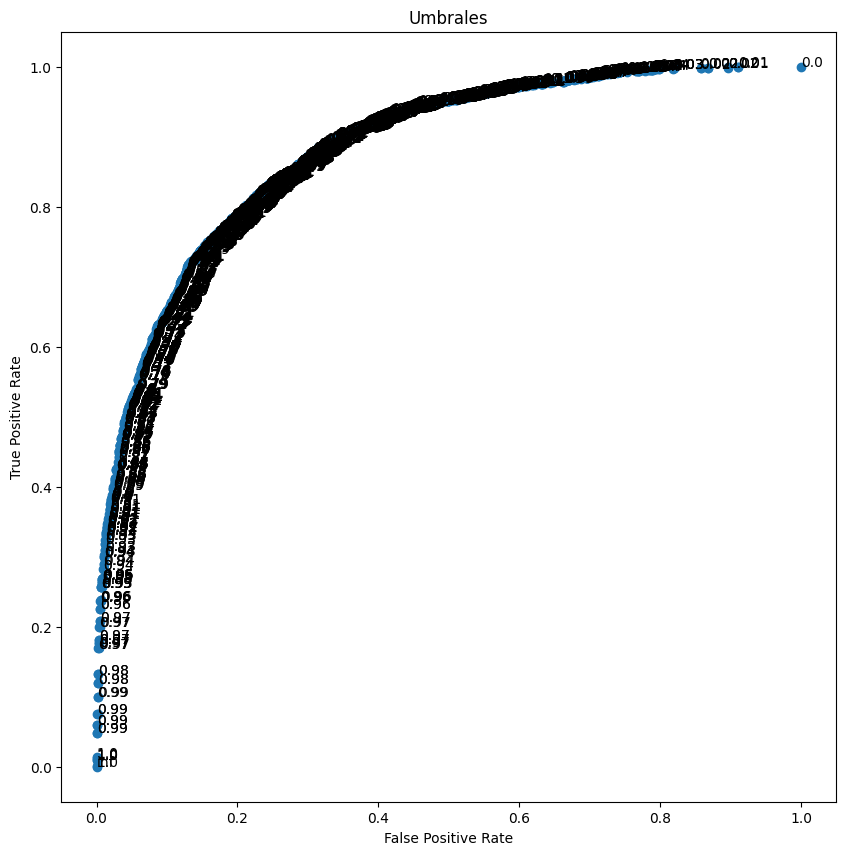

In [155]:
#---------------------------------------------------
# Entrenamiento y validación.

model_8 = lgb.LGBMClassifier(class_weight = 'balanced', random_state = 42)
model_8.fit(X_train, y_train)

y_train_pred = model_8.predict(X_train)
y_val_pred = model_8.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_7.predict_proba(X_train)
y_val_pred_proba = model_7.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')
#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# ROC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
#-----------------------------------------------------
# Análisis de umbrales.

fig, ax = plt.subplots(figsize=(10,10))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

### LightGBM sobre Test.

Accuracy sobre el set de testeo: 0.800281734230709 

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      6332
           1       0.80      0.80      0.80      6446

    accuracy                           0.80     12778
   macro avg       0.80      0.80      0.80     12778
weighted avg       0.80      0.80      0.80     12778
 



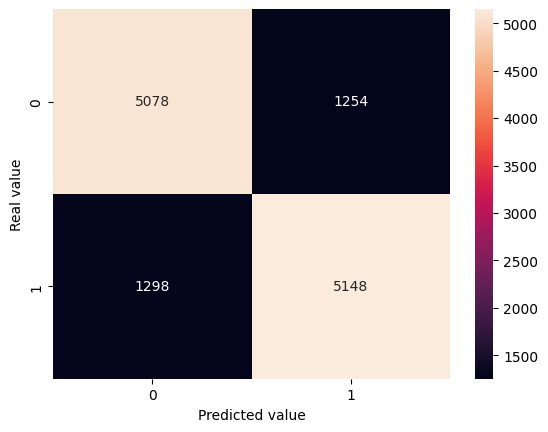

AUC sobre el set de test: 0.8844424936333903



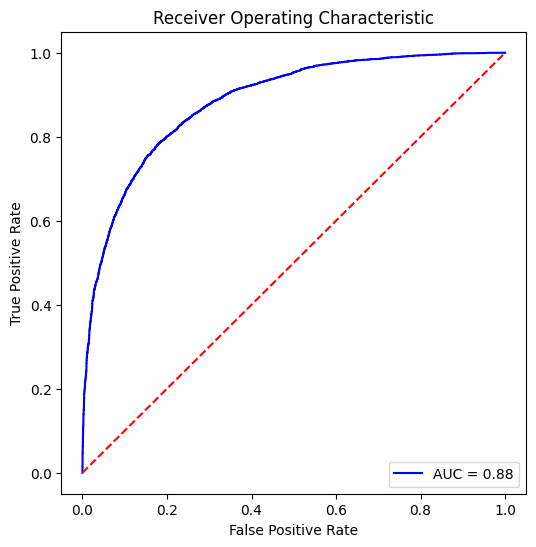

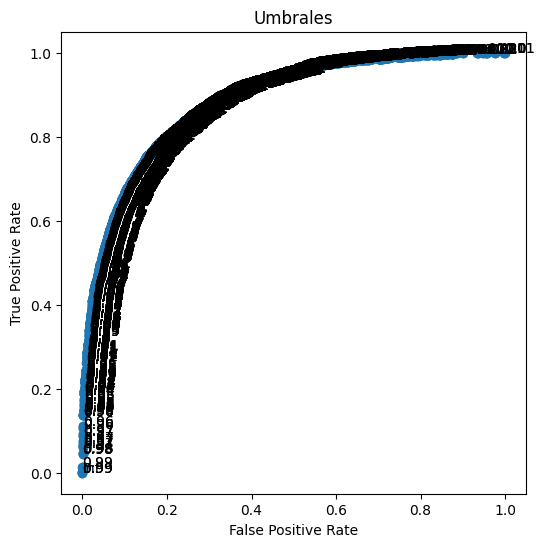

In [156]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_8.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_8.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

## RandomizedSearchCV usando StratifiedKFold.

## Validación y entrenamiento se unen para formar un único dataset.

In [157]:
display(train_df_lluvia)
display(val_df_lluvia)

train_df_lluvia = pd.concat([train_df, val_df_lluvia])
display(train_df_lluvia)

X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
87029,71,0.4,5.4,5.4,67.5,30.0,112.5,90.0,63.0,69.0,...,7.0,7.0,27.2,0,1,1,13.0,0.0,0.0,1.0
23717,102,0.2,1.6,7.2,292.5,39.0,315.0,292.5,85.0,84.0,...,4.0,5.0,22.6,0,1,5,17.0,1.0,0.0,0.0
16922,73,0.0,4.6,8.6,270.0,39.0,135.0,45.0,75.0,65.0,...,1.0,6.0,26.0,0,1,3,2.0,1.0,0.0,0.0
56802,78,0.4,4.6,8.6,270.0,46.0,292.5,270.0,95.0,91.0,...,8.0,8.0,10.2,0,1,10,24.5,0.0,0.0,0.0
15098,73,0.0,4.6,8.6,270.0,39.0,315.0,135.0,62.0,42.0,...,6.0,8.0,29.0,0,1,12,2.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89000,95,0.0,7.6,4.0,180.0,46.0,67.5,180.0,64.0,96.0,...,7.0,7.0,24.7,0,1,2,14.5,0.0,0.0,1.0
12235,44,0.0,3.0,9.2,90.0,37.0,112.5,135.0,64.0,35.0,...,1.0,2.0,20.2,0,0,6,12.5,1.0,0.0,0.0
11397,97,0.1,2.8,10.0,90.0,28.0,0.0,67.5,57.0,52.0,...,1.0,2.0,20.8,0,0,8,13.0,0.0,1.0,0.0
133218,70,0.4,1.0,8.6,157.5,46.0,90.0,157.5,98.0,72.0,...,8.0,7.5,14.6,0,1,6,17.5,1.0,0.0,0.0


,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
110675,90,0.0,5.8,10.9,270.0,39.0,67.5,225.0,51.0,55.0,...,5.0,1.0,21.1,0,0,12,15.0,0.0,0.0,1.0
88017,95,83.8,2.0,0.0,180.0,30.0,180.0,157.5,88.0,98.0,...,8.0,8.0,24.2,1,1,2,14.0,0.0,0.0,1.0
45018,71,0.0,4.6,8.6,67.5,37.0,337.5,45.0,60.0,69.0,...,8.0,8.0,22.0,0,0,12,24.5,0.0,0.0,1.0
116794,56,9.0,4.6,1.4,90.0,50.0,90.0,202.5,54.0,95.0,...,2.0,8.0,24.1,1,1,3,28.5,1.0,0.0,0.0
119804,63,4.6,3.4,9.8,270.0,48.0,292.5,292.5,75.0,53.0,...,6.0,4.0,25.6,1,1,3,25.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106342,22,0.0,7.4,9.6,180.0,61.0,157.5,180.0,65.0,33.0,...,1.0,2.0,27.6,0,0,2,25.0,0.0,0.0,1.0
54763,82,6.4,4.6,8.6,315.0,107.0,315.0,292.5,98.0,98.0,...,6.0,5.0,8.5,1,1,7,39.0,0.0,1.0,0.0
127264,111,0.0,4.6,8.6,67.5,44.0,67.5,112.5,65.0,52.0,...,6.0,5.0,23.3,0,0,3,22.0,1.0,0.0,0.0
66576,73,2.4,8.4,5.9,0.0,46.0,180.0,157.5,73.0,63.0,...,7.0,7.0,20.0,1,1,10,13.0,0.0,0.0,0.0


,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
87029,71,0.4,5.4,5.4,67.5,30.0,112.5,90.0,63.0,69.0,...,7.0,7.0,27.2,0,1,1,13.0,0.0,0.0,1.0
23717,102,0.2,1.6,7.2,292.5,39.0,315.0,292.5,85.0,84.0,...,4.0,5.0,22.6,0,1,5,17.0,1.0,0.0,0.0
16922,73,0.0,4.6,8.6,270.0,39.0,135.0,45.0,75.0,65.0,...,1.0,6.0,26.0,0,1,3,2.0,1.0,0.0,0.0
56802,78,0.4,4.6,8.6,270.0,46.0,292.5,270.0,95.0,91.0,...,8.0,8.0,10.2,0,1,10,24.5,0.0,0.0,0.0
15098,73,0.0,4.6,8.6,270.0,39.0,315.0,135.0,62.0,42.0,...,6.0,8.0,29.0,0,1,12,2.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106342,22,0.0,7.4,9.6,180.0,61.0,157.5,180.0,65.0,33.0,...,1.0,2.0,27.6,0,0,2,25.0,0.0,0.0,1.0
54763,82,6.4,4.6,8.6,315.0,107.0,315.0,292.5,98.0,98.0,...,6.0,5.0,8.5,1,1,7,39.0,0.0,1.0,0.0
127264,111,0.0,4.6,8.6,67.5,44.0,67.5,112.5,65.0,52.0,...,6.0,5.0,23.3,0,0,3,22.0,1.0,0.0,0.0
66576,73,2.4,8.4,5.9,0.0,46.0,180.0,157.5,73.0,63.0,...,7.0,7.0,20.0,1,1,10,13.0,0.0,0.0,0.0


### AdaBoost.

In [158]:
model_9 = AdaBoostClassifier(random_state=42)

# Hiperparámetros a optimizar.
n_estimators = [10, 50, 100, 500]
learning_rate = [0.0001, 0.001, 0.01, 0.1, 1.0]

param_grid_9 = {'n_estimators':n_estimators,
                'learning_rate':learning_rate}

# Cross validation.
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# RandomizedSearchCV.
rs_model_9 = RandomizedSearchCV(estimator=model_9, param_distributions=param_grid_9, cv=cv, n_jobs=-1, verbose=1)
rs_model_9.fit(X_train, y_train)
print(rs_model_9.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'n_estimators': 500, 'learning_rate': 1.0}


In [159]:
parameters_df = pd.DataFrame(rs_model_9.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_9.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,40.726375,5.585269,0.846944,0.275903,500,1.0,"{'n_estimators': 500, 'learning_rate': 1.0}",0.776879,0.779082,0.775525,0.783974,0.781483,0.779389,0.003057,1


In [161]:
desvio_std = parameters_df[parameters_df['params'] == rs_model_9.best_params_]['std_test_score'].iloc[0]

In [162]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_9.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_9.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_9.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_9.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.78365735223493

Accuracy promedio: 0.779388529373662 +/- 0.0030572800753241054

Accuracy sobre el set de test: 0.780873376115198

Recall sobre el set de test: 0.7601613403661185


### Gradient Boosting.

In [163]:
model_10 = GradientBoostingClassifier(random_state=42)

# Hiperparámetros a optimizar.
loss = ["deviance","exponential"]
criterion = ["friedman_mse",  "mae"]
max_features = ["log2", "sqrt"]
max_features = [0.01, 0.05, 0.1, 1, 0.5]
max_depth = [3,4,5]
min_samples_leaf = [4,5,6]
subsample = [0.6,0.7,0.8]
n_estimators = np.arange(5, 1000)

param_grid_10 = {"criterion": criterion,
                 'loss': loss,
                 'max_features':max_features,
                 'learning_rate': max_features,
                 'max_depth': max_depth,
                 'min_samples_leaf': min_samples_leaf,
                 'subsample': subsample,
                 'n_estimators': n_estimators}

# Cross validation.
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# RandomizedSearchCV.
rs_model_10 = RandomizedSearchCV(estimator=model_10, param_distributions=param_grid_10, cv=cv, n_jobs=-1, verbose=1)
rs_model_10.fit(X_train, y_train)
print(rs_model_10.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

{'subsample': 0.8, 'n_estimators': np.int64(171), 'min_samples_leaf': 6, 'max_features': 0.5, 'max_depth': 5, 'loss': 'exponential', 'learning_rate': 0.05, 'criterion': 'friedman_mse'}


In [164]:
parameters_df = pd.DataFrame(rs_model_10.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_10.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_samples_leaf,param_max_features,param_max_depth,param_loss,...,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,25.627508,6.844571,0.083421,0.015029,0.8,171,6,0.5,5,exponential,...,friedman_mse,"{'subsample': 0.8, 'n_estimators': 171, 'min_s...",0.792441,0.800605,0.791,0.798381,0.793312,0.795148,0.003692,1


In [166]:
desvio_std = parameters_df[parameters_df['params'] == rs_model_10.best_params_]['std_test_score'].iloc[0]

In [167]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_10.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_10.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_10.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_10.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.8061400544280607

Accuracy promedio: 0.795147768746266 +/- 0.003691560595922651

Accuracy sobre el set de test: 0.796994834872437

Recall sobre el set de test: 0.7887061743717034


### XGBoost.

In [168]:
model_11 = xgb.XGBClassifier(seed=42)

# Hiperparámetros a optimizar.
#n_estimators = [50,65,80,100,115,130,150]
param_grid_11 = {
 'learning_rate' : [0.05,0.10,0.15,0.20,0.25,0.30],
 'max_depth' : [ 3, 4, 5, 6, 8, 10, 12, 15],
 'min_child_weight' : [ 1, 3, 5, 7 ],
 'gamma': [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 'colsample_bytree' : [ 0.3, 0.4, 0.5 , 0.7 ]
}
#param_grid_11 = {'n_estimators': n_estimators}

# Cross validation.
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# RandomizedSearchCV.
rs_model_11 = RandomizedSearchCV(estimator=model_11, param_distributions=param_grid_11, cv=cv, n_jobs=-1, verbose=3)
rs_model_11.fit(X_train, y_train)
print(rs_model_11.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'min_child_weight': 5, 'max_depth': 12, 'learning_rate': 0.15, 'gamma': 0.3, 'colsample_bytree': 0.5}


In [169]:
parameters_df = pd.DataFrame(rs_model_11.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_11.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_min_child_weight,param_max_depth,param_learning_rate,param_gamma,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,4.237235,0.625198,0.314909,0.123965,5,12,0.15,0.3,0.5,"{'min_child_weight': 5, 'max_depth': 12, 'lear...",0.820987,0.826663,0.820527,0.824351,0.824262,0.823358,0.002296,1


In [171]:
desvio_std = parameters_df[parameters_df['params'] == rs_model_11.best_params_]['std_test_score'].iloc[0]

In [172]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_11.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_11.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_11.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_11.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.9617580619341527

Accuracy promedio: 0.8233578622001889 +/- 0.002296290543887127

Accuracy sobre el set de test: 0.8051338237595868

Recall sobre el set de test: 0.8062364256903506


Accuracy sobre el set de testeo: 0.8051338237595868 

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      6332
           1       0.81      0.81      0.81      6446

    accuracy                           0.81     12778
   macro avg       0.81      0.81      0.81     12778
weighted avg       0.81      0.81      0.81     12778
 



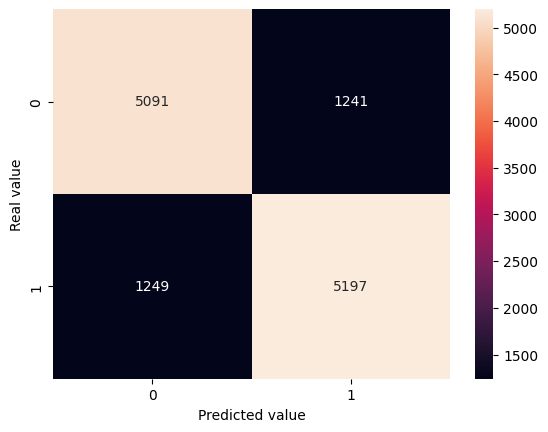

AUC sobre el set de test: 0.8890359537782078



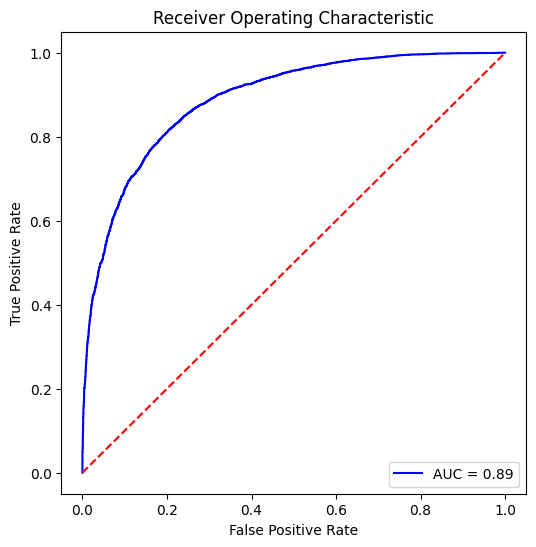

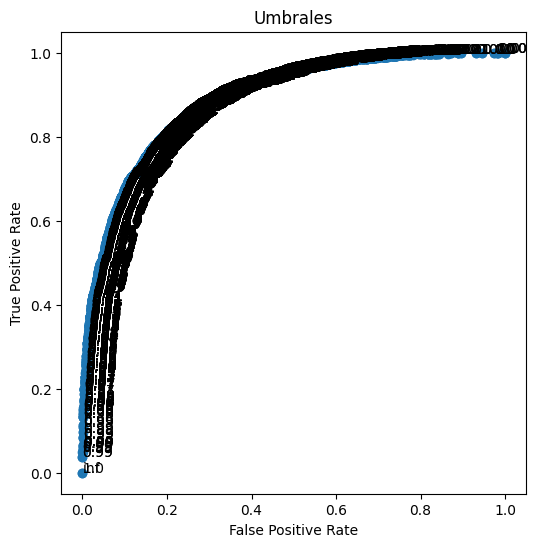

In [173]:
#---------------------------------------------------
# Predicción.

y_test_pred = rs_model_11.best_estimator_.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = rs_model_11.best_estimator_.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

### LightGBM.

In [174]:
model_12 = lgb.LGBMClassifier(class_weight = 'balanced', objective = 'binary', random_state = 42)

# Hiperparámetros a optimizar.
learning_rate = [0.005, 0.01]
max_depth = [5,6,7,8,9,10]
n_estimators = [8,16,24,200]
num_leaves = [6,8,12,16]
boosting_type = ['gbdt', 'dart']
max_bin = [255, 510]
colsample_bytree = [0.64, 0.65, 0.66]
subsample = [0.7,0.75]
reg_alpha = [1,1.2]
reg_lambda = [1,1.2,1.4]

param_grid_12 = {
                'learning_rate': [0.005, 0.01],
                'n_estimators': [8,16,24],
                'num_leaves': [6,8,12,16],
                'boosting_type' : ['gbdt', 'dart'],
                'max_bin':[255, 510],
                'colsample_bytree' : [0.64, 0.65, 0.66],
                'subsample' : [0.7,0.75],
                'reg_alpha' : [1,1.2],
                'reg_lambda' : [1,1.2,1.4]}

# Cross validation.
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# RandomizedSearchCV.
rs_model_12 = RandomizedSearchCV(estimator=model_12, param_distributions=param_grid_12, cv=cv, n_jobs=-1, verbose=1)
rs_model_12.fit(X_train, y_train)
print(rs_model_12.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 27995, number of negative: 28226
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1679
[LightGBM] [Info] Number of data points in the train set: 56221, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
{'subsample': 0.75, 'reg_lambda': 1.4, 'reg_alpha': 1.2, 'num_leaves': 16, 'n_estimators': 24, 'max_bin': 255, 'learning_rate': 0.01, 'colsample_bytree': 0.64, 'boosting_type': 'gbdt'}


In [175]:
parameters_df = pd.DataFrame(rs_model_12.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_12.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_reg_lambda,param_reg_alpha,param_num_leaves,param_n_estimators,param_max_bin,...,param_boosting_type,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.489811,0.01933,0.027163,0.001456,0.75,1.4,1.2,16,24,255,...,gbdt,"{'subsample': 0.75, 'reg_lambda': 1.4, 'reg_al...",0.768075,0.774635,0.769032,0.77428,0.770811,0.771367,0.002674,1


In [177]:
desvio_std = parameters_df.loc[rs_model_12.best_index_, 'std_test_score']

In [178]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_12.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_12.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_12.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_12.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.7735543658063713

Accuracy promedio: 0.7713666297634318 +/- 0.00267448178594829

Accuracy sobre el set de test: 0.7753952105180779

Recall sobre el set de test: 0.764505119453925


## Bagging (Bootstrap aggregating).

### Dependencias adicionales.

In [179]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import BaggingClassifier

### Train - Test - Val split

In [180]:
train_df_lluvia, test_df_lluvia = train_test_split(balanced_df_lluvia, test_size=0.2, random_state=42)
train_df_lluvia, val_df_lluvia = train_test_split(train_df_lluvia, test_size=0.1, random_state=42)

X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]

X_val = val_df_lluvia[features]
y_val = val_df_lluvia[target]

X_test = test_df_lluvia[features]
y_test = test_df_lluvia[target]

### BaggingClassifier.

Accuracy sobre el set de entrenamiento: 0.9930215874258136 

Accuracy sobre el set de validación: 0.7759733907258853 

              precision    recall  f1-score   support

           0       0.77      0.80      0.79      2614
           1       0.78      0.75      0.77      2497

    accuracy                           0.78      5111
   macro avg       0.78      0.78      0.78      5111
weighted avg       0.78      0.78      0.78      5111
 



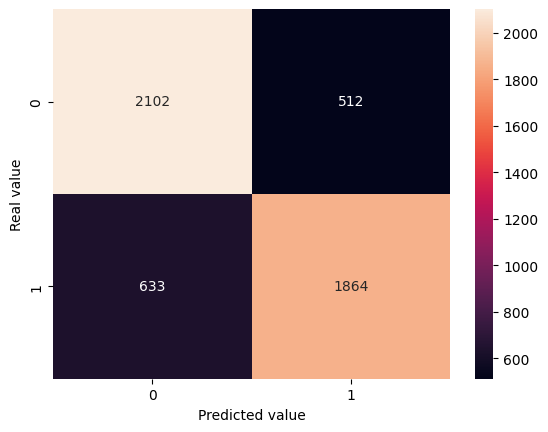

Log loss sobre el set de entrenamiento: 0.12329162573216114 

Log loss sobre el set de validación: 0.7922803816901394 

AUC sobre el set de validación: 0.8603204488078885



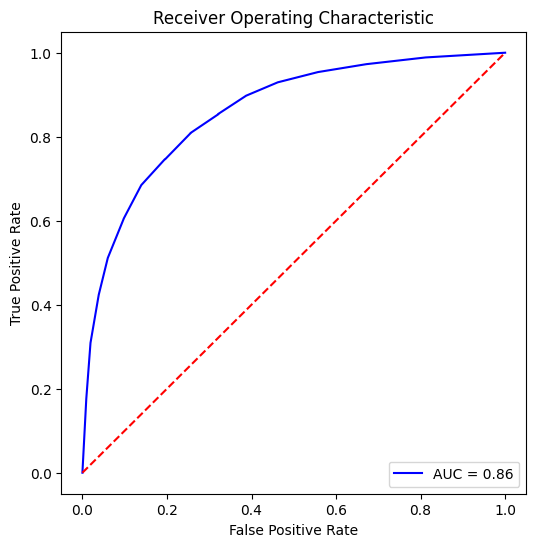

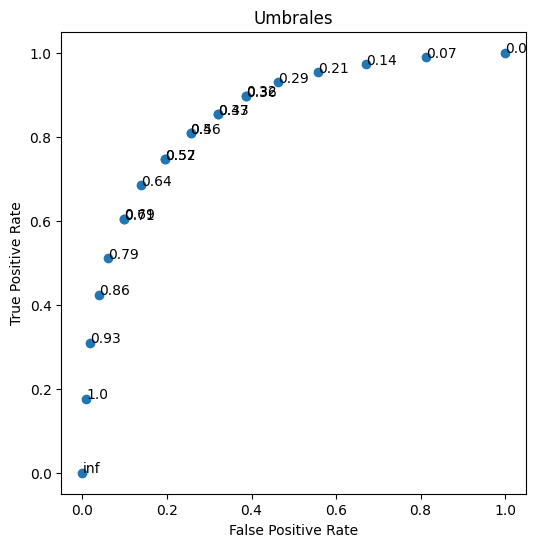

In [181]:
#---------------------------------------------------
# Entrenamiento y validación.

model_13 = BaggingClassifier(n_estimators = 14, random_state = 42, n_jobs = -1)
model_13.fit(X_train, y_train)

y_train_pred = model_13.predict(X_train)
y_val_pred = model_13.predict(X_val)

train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
val_accuracy = metrics.accuracy_score(y_val, y_val_pred)

print('Accuracy sobre el set de entrenamiento:', train_accuracy, '\n')
print('Accuracy sobre el set de validación:',val_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_val,y_val_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_val,y_val_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()
#---------------------------------------------------
# Función de pérdida: log loss.

y_train_pred_proba = model_13.predict_proba(X_train)
y_val_pred_proba = model_13.predict_proba(X_val)

train_loss = log_loss(y_train, y_train_pred_proba)
val_loss = log_loss(y_val, y_val_pred_proba)

print('Log loss sobre el set de entrenamiento:', train_loss, '\n')
print('Log loss sobre el set de validación:',val_loss, '\n')
#---------------------------------------------------
# Curva ROC/AUC sobre val data.

fpr, tpr, threshold = roc_curve(y_val, y_val_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# ROC
print(f"AUC sobre el set de validación: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
#-----------------------------------------------------
# Análisis de umbrales.

fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))
#-----------------------------------------------------

### BaggingClassifier sobre Test.

Accuracy sobre el set de testeo: 0.783064642354046 

              precision    recall  f1-score   support

           0       0.77      0.81      0.79      6332
           1       0.80      0.76      0.78      6446

    accuracy                           0.78     12778
   macro avg       0.78      0.78      0.78     12778
weighted avg       0.78      0.78      0.78     12778
 



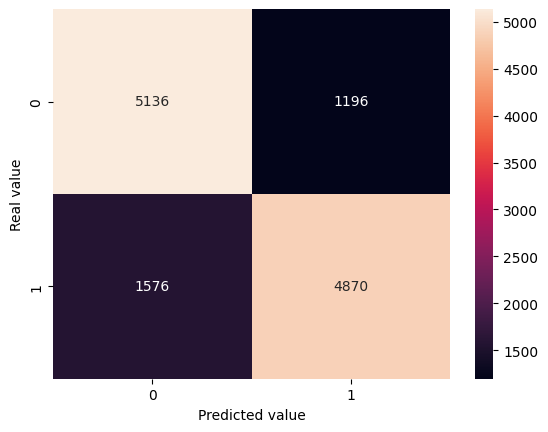

AUC sobre el set de test: 0.8614789291826025



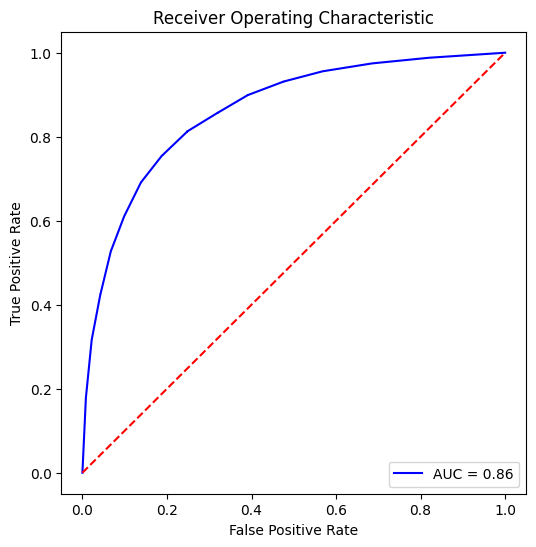

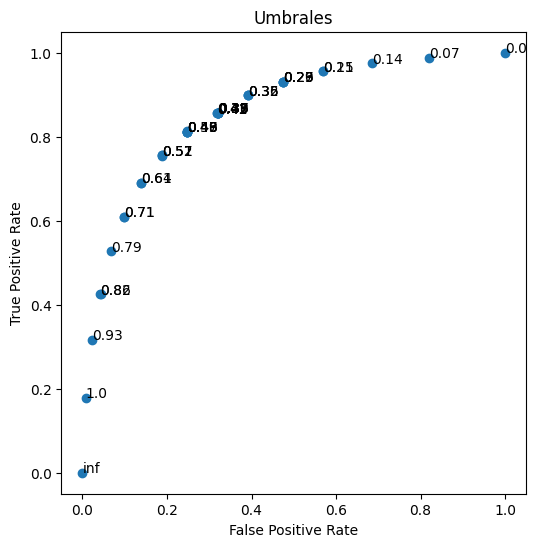

In [182]:
#---------------------------------------------------
# Predicción.

y_test_pred = model_13.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = model_13.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

## RandomizedSearchCV usando StratifiedKFold.

## Validación y entrenamiento se unen para formar un único dataset.

In [194]:
display(train_df_lluvia)
display(val_df_lluvia)

train_df_lluvia = pd.concat([train_df_lluvia, val_df_lluvia])
display(train_df_lluvia)

X_train = train_df_lluvia[features]
y_train = train_df_lluvia[target]

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
87029,71,0.4,5.4,5.4,67.5,30.0,112.5,90.0,63.0,69.0,...,7.0,7.0,27.2,0,1,1,13.0,0.0,0.0,1.0
23717,102,0.2,1.6,7.2,292.5,39.0,315.0,292.5,85.0,84.0,...,4.0,5.0,22.6,0,1,5,17.0,1.0,0.0,0.0
16922,73,0.0,4.6,8.6,270.0,39.0,135.0,45.0,75.0,65.0,...,1.0,6.0,26.0,0,1,3,2.0,1.0,0.0,0.0
56802,78,0.4,4.6,8.6,270.0,46.0,292.5,270.0,95.0,91.0,...,8.0,8.0,10.2,0,1,10,24.5,0.0,0.0,0.0
15098,73,0.0,4.6,8.6,270.0,39.0,315.0,135.0,62.0,42.0,...,6.0,8.0,29.0,0,1,12,2.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89000,95,0.0,7.6,4.0,180.0,46.0,67.5,180.0,64.0,96.0,...,7.0,7.0,24.7,0,1,2,14.5,0.0,0.0,1.0
12235,44,0.0,3.0,9.2,90.0,37.0,112.5,135.0,64.0,35.0,...,1.0,2.0,20.2,0,0,6,12.5,1.0,0.0,0.0
11397,97,0.1,2.8,10.0,90.0,28.0,0.0,67.5,57.0,52.0,...,1.0,2.0,20.8,0,0,8,13.0,0.0,1.0,0.0
133218,70,0.4,1.0,8.6,157.5,46.0,90.0,157.5,98.0,72.0,...,8.0,7.5,14.6,0,1,6,17.5,1.0,0.0,0.0


,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
110675,90,0.0,5.8,10.9,270.0,39.0,67.5,225.0,51.0,55.0,...,5.0,1.0,21.1,0,0,12,15.0,0.0,0.0,1.0
88017,95,83.8,2.0,0.0,180.0,30.0,180.0,157.5,88.0,98.0,...,8.0,8.0,24.2,1,1,2,14.0,0.0,0.0,1.0
45018,71,0.0,4.6,8.6,67.5,37.0,337.5,45.0,60.0,69.0,...,8.0,8.0,22.0,0,0,12,24.5,0.0,0.0,1.0
116794,56,9.0,4.6,1.4,90.0,50.0,90.0,202.5,54.0,95.0,...,2.0,8.0,24.1,1,1,3,28.5,1.0,0.0,0.0
119804,63,4.6,3.4,9.8,270.0,48.0,292.5,292.5,75.0,53.0,...,6.0,4.0,25.6,1,1,3,25.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106342,22,0.0,7.4,9.6,180.0,61.0,157.5,180.0,65.0,33.0,...,1.0,2.0,27.6,0,0,2,25.0,0.0,0.0,1.0
54763,82,6.4,4.6,8.6,315.0,107.0,315.0,292.5,98.0,98.0,...,6.0,5.0,8.5,1,1,7,39.0,0.0,1.0,0.0
127264,111,0.0,4.6,8.6,67.5,44.0,67.5,112.5,65.0,52.0,...,6.0,5.0,23.3,0,0,3,22.0,1.0,0.0,0.0
66576,73,2.4,8.4,5.9,0.0,46.0,180.0,157.5,73.0,63.0,...,7.0,7.0,20.0,1,1,10,13.0,0.0,0.0,0.0


,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,Humidity9am,Humidity3pm,...,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,WindSpeed_mean,Season_Spring,Season_Summer,Season_Winter
87029,71,0.4,5.4,5.4,67.5,30.0,112.5,90.0,63.0,69.0,...,7.0,7.0,27.2,0,1,1,13.0,0.0,0.0,1.0
23717,102,0.2,1.6,7.2,292.5,39.0,315.0,292.5,85.0,84.0,...,4.0,5.0,22.6,0,1,5,17.0,1.0,0.0,0.0
16922,73,0.0,4.6,8.6,270.0,39.0,135.0,45.0,75.0,65.0,...,1.0,6.0,26.0,0,1,3,2.0,1.0,0.0,0.0
56802,78,0.4,4.6,8.6,270.0,46.0,292.5,270.0,95.0,91.0,...,8.0,8.0,10.2,0,1,10,24.5,0.0,0.0,0.0
15098,73,0.0,4.6,8.6,270.0,39.0,315.0,135.0,62.0,42.0,...,6.0,8.0,29.0,0,1,12,2.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106342,22,0.0,7.4,9.6,180.0,61.0,157.5,180.0,65.0,33.0,...,1.0,2.0,27.6,0,0,2,25.0,0.0,0.0,1.0
54763,82,6.4,4.6,8.6,315.0,107.0,315.0,292.5,98.0,98.0,...,6.0,5.0,8.5,1,1,7,39.0,0.0,1.0,0.0
127264,111,0.0,4.6,8.6,67.5,44.0,67.5,112.5,65.0,52.0,...,6.0,5.0,23.3,0,0,3,22.0,1.0,0.0,0.0
66576,73,2.4,8.4,5.9,0.0,46.0,180.0,157.5,73.0,63.0,...,7.0,7.0,20.0,1,1,10,13.0,0.0,0.0,0.0


## Bagging optimizado.

In [188]:
model_14 = BaggingClassifier(DecisionTreeClassifier(random_state = 42), random_state = 42, n_jobs = -1)

# Hiperparámetros a optimizar.
param_grid_14 = {"estimator__max_depth": [3,5,10,20],
          "estimator__max_features": [None, "sqrt", "log2"],
          "estimator__min_samples_leaf": [1, 3, 5, 7, 10],
          "estimator__min_samples_split": [2, 5, 7],
          'bootstrap_features': [False, True],
          'max_features': [0.5, 0.7, 1.0],
          'max_samples': [0.5, 0.7, 1.0],
          'n_estimators': [2, 5, 10, 20, 40, 60, 100]}

# Cross validation.
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# RandomizedSearchCV.
rs_model_14 = RandomizedSearchCV(estimator=model_14, param_distributions=param_grid_14, cv=cv, n_jobs=-1, verbose=1)
rs_model_14.fit(X_train, y_train)
print(rs_model_14.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'n_estimators': 100, 'max_samples': 0.7, 'max_features': 1.0, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 3, 'estimator__max_features': None, 'estimator__max_depth': 10, 'bootstrap_features': True}


In [189]:
parameters_df = pd.DataFrame(rs_model_14.cv_results_)
display(parameters_df[parameters_df['params'] == rs_model_14.best_params_])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_samples,param_max_features,param_estimator__min_samples_split,param_estimator__min_samples_leaf,param_estimator__max_features,...,param_bootstrap_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,26.632731,6.2687,0.346222,0.133576,100,0.7,1.0,5,3,None,...,True,"{'n_estimators': 100, 'max_samples': 0.7, 'max...",0.796087,0.779565,0.79163,0.789457,0.782802,0.787908,0.00598,1


In [191]:
desvio_std = parameters_df[parameters_df['params'] == rs_model_14.best_params_]['std_test_score'].iloc[0]

In [192]:
print(f"Accuracy sobre el set de entrenamiento completo: {rs_model_14.score(X_train, y_train)}\n")
print(f"Accuracy promedio: {rs_model_14.best_score_} +/- {desvio_std}\n")
print(f"Accuracy sobre el set de test: {rs_model_14.score(X_test, y_test)}\n")
print(f"Recall sobre el set de test: {metrics.recall_score(y_test, rs_model_14.best_estimator_.predict(X_test))}")

Accuracy sobre el set de entrenamiento completo: 0.8314093784647493

Accuracy promedio: 0.7879083217930115 +/- 0.005980269905077137

Accuracy sobre el set de test: 0.7940992330568164

Recall sobre el set de test: 0.7860688799255352


Accuracy sobre el set de testeo: 0.7940992330568164 

              precision    recall  f1-score   support

           0       0.79      0.80      0.79      6332
           1       0.80      0.79      0.79      6446

    accuracy                           0.79     12778
   macro avg       0.79      0.79      0.79     12778
weighted avg       0.79      0.79      0.79     12778
 



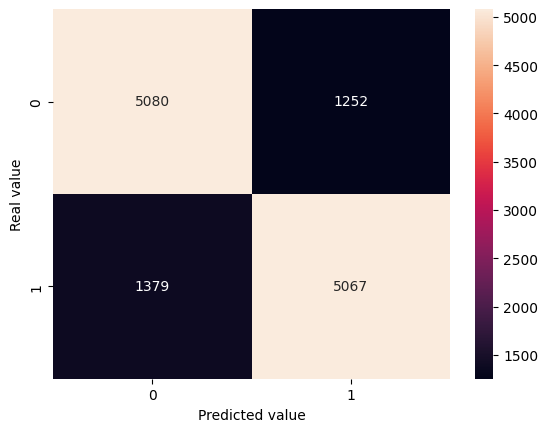

AUC sobre el set de test: 0.8769184599635164



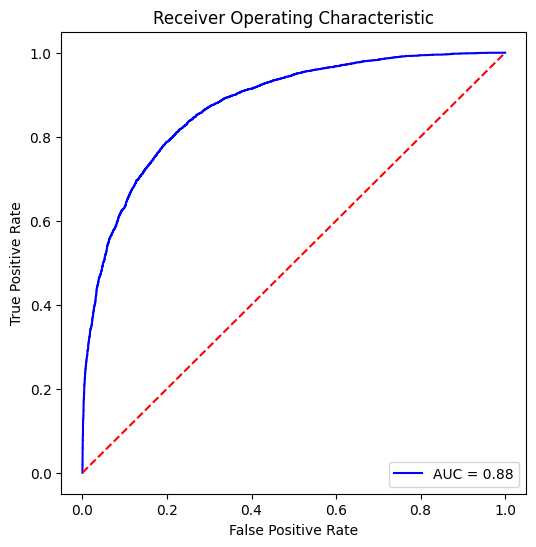

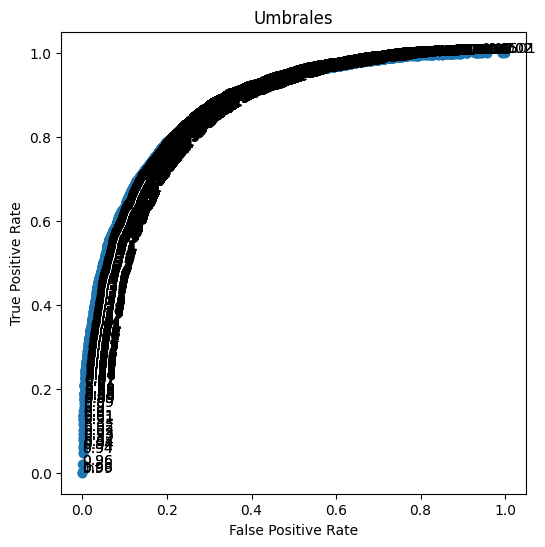

In [193]:
#---------------------------------------------------
# Predicción.

y_test_pred = rs_model_14.best_estimator_.predict(X_test)

test_accuracy = metrics.accuracy_score(y_test, y_test_pred)

print('Accuracy sobre el set de testeo:',test_accuracy, '\n')
#---------------------------------------------------
# Classification report.

print(classification_report(y_test,y_test_pred), '\n')
#---------------------------------------------------
# Matriz de confusión.

cm = confusion_matrix(y_test,y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted value')
plt.ylabel('Real value')
plt.show()

#---------------------------------------------------
# Curva ROC/AUC sobre test data.
y_test_pred_proba = rs_model_14.best_estimator_.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_test_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

# AUC
print(f"AUC sobre el set de test: {roc_auc}\n")
plt.figure(figsize=(6,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr,  'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

#-----------------------------------------------------
# Análisis de umbrales.
fig, ax = plt.subplots(figsize=(6,6))
plt.title('Umbrales')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
ax.scatter(fpr, tpr)

for i, text in enumerate(threshold):
    ax.annotate(round(text, 2), (fpr[i], tpr[i]))

In [197]:
from sklearn.metrics import classification_report

# Reemplaza 'y_val' y 'y_pred' por tus variables
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.79      2614
           1       0.78      0.75      0.77      2497

    accuracy                           0.78      5111
   macro avg       0.78      0.78      0.78      5111
weighted avg       0.78      0.78      0.78      5111

